# Taal Vista Hotel Exploratory Data Analysis

## Purpose

This notebook explores the cleaned Taal Vista Hotel datasets to identify patterns, relationships, unusual observations, and business opportunities.

The analysis focuses on the following areas:

1. Room rates and rate plan differences
2. Weekday and weekend pricing
3. Room category and room size relationships
4. Meeting package pricing
5. Wedding and Christmas package pricing
6. Spa and Pasalubong price distributions
7. Event venue capacity and space utilization
8. Promotions and official guest reviews

## Analytical Approach

The exploratory analysis includes:

1. Data structure and quality verification
2. Univariate distributions
3. Outlier detection
4. Bivariate and multivariate relationships
5. Segmentation and conditional comparisons
6. Probability analysis
7. Correlation analysis
8. Normality testing
9. Hypothesis testing
10. Effect size measurement
11. Statistical interpretation
12. Business implications

Missing values that represent unavailable, unpublished, open ended, or non applicable information will remain excluded only from calculations requiring those values.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.float_format",
    "{:,.2f}".format
)

sns.set_theme(
    style="whitegrid"
)

In [2]:
project_root = Path.cwd().parent

clean_data_folder = (
    project_root
    / "data"
    / "clean"
)

clean_files = sorted(
    clean_data_folder.glob(
        "*_clean.csv"
    )
)

eda_dataframes = {}

for clean_file in clean_files:
    dataset_name = (
        clean_file.stem
        .replace(
            "taal_vista_",
            ""
        )
        .replace(
            "_clean",
            ""
        )
    )

    eda_dataframes[
        dataset_name
    ] = pd.read_csv(
        clean_file
    )

print(
    "Clean datasets loaded:",
    len(eda_dataframes)
)

for dataset_name, current_df in (
    eda_dataframes.items()
):
    print(
        dataset_name,
        current_df.shape
    )

Clean datasets loaded: 14
christmas_packages (4, 25)
dining (5, 12)
event_venues (24, 18)
facilities (5, 6)
hotel_contact (5, 8)
hotel_facts (12, 8)
meeting_rates (18, 21)
official_reviews (6, 10)
pasalubong_prices (34, 17)
promotions (25, 13)
room_rates (93, 38)
rooms (11, 5)
spa_prices (26, 16)
wedding_rates (9, 20)


In [3]:
date_columns = [
    "check_in_date",
    "check_out_date",
    "date_collected",
    "menu_as_of_date",
    "early_bird_deadline",
    "valid_until",
    "fx_rate_date"
]

date_conversion_records = []

for dataset_name, current_df in (
    eda_dataframes.items()
):
    for column_name in date_columns:
        if column_name in current_df.columns:
            current_df[column_name] = pd.to_datetime(
                current_df[column_name],
                errors="coerce"
            )

            date_conversion_records.append({
                "dataset_name": dataset_name,
                "column_name": column_name,
                "data_type": str(
                    current_df[column_name].dtype
                ),
                "missing_values": (
                    current_df[column_name]
                    .isna()
                    .sum()
                )
            })

date_conversion_df = pd.DataFrame(
    date_conversion_records
)

display(date_conversion_df)

print(
    "Date columns converted:",
    len(date_conversion_df)
)

print(
    "Invalid or missing dates:",
    date_conversion_df[
        "missing_values"
    ].sum()
)

,dataset_name,column_name,data_type,missing_values
0,christmas_packages,date_collected,datetime64[us],0
1,christmas_packages,early_bird_deadline,datetime64[us],0
2,christmas_packages,valid_until,datetime64[us],0
3,christmas_packages,fx_rate_date,datetime64[us],0
4,dining,date_collected,datetime64[us],0
5,event_venues,date_collected,datetime64[us],0
6,facilities,date_collected,datetime64[us],0
7,hotel_contact,date_collected,datetime64[us],0
8,hotel_facts,date_collected,datetime64[us],0
9,meeting_rates,date_collected,datetime64[us],0


Date columns converted: 25
Invalid or missing dates: 0


In [4]:
eda_quality_records = []

for dataset_name, current_df in (
    eda_dataframes.items()
):
    numeric_columns = current_df.select_dtypes(
        include="number"
    ).columns

    negative_values = 0

    for column_name in numeric_columns:
        if not column_name.endswith(
            "_record_id"
        ):
            negative_values += (
                current_df[column_name] < 0
            ).sum()

    eda_quality_records.append({
        "dataset_name": dataset_name,
        "rows": current_df.shape[0],
        "columns": current_df.shape[1],
        "missing_cells": (
            current_df.isna()
            .sum()
            .sum()
        ),
        "duplicate_rows": (
            current_df.duplicated()
            .sum()
        ),
        "negative_numeric_values": (
            negative_values
        )
    })

eda_quality_df = pd.DataFrame(
    eda_quality_records
)

display(eda_quality_df)

print(
    "Total datasets:",
    eda_quality_df.shape[0]
)

print(
    "Total rows:",
    eda_quality_df["rows"].sum()
)

print(
    "Total missing cells:",
    eda_quality_df[
        "missing_cells"
    ].sum()
)

print(
    "Total duplicate rows:",
    eda_quality_df[
        "duplicate_rows"
    ].sum()
)

print(
    "Total negative numeric values:",
    eda_quality_df[
        "negative_numeric_values"
    ].sum()
)

,dataset_name,rows,columns,missing_cells,duplicate_rows,negative_numeric_values
0,christmas_packages,4,25,0,0,0
1,dining,5,12,0,0,0
2,event_venues,24,18,28,0,0
3,facilities,5,6,0,0,0
4,hotel_contact,5,8,0,0,0
5,hotel_facts,12,8,0,0,0
6,meeting_rates,18,21,6,0,0
7,official_reviews,6,10,0,0,0
8,pasalubong_prices,34,17,0,0,0
9,promotions,25,13,0,0,0


Total datasets: 14
Total rows: 277
Total missing cells: 38
Total duplicate rows: 0
Total negative numeric values: 0


## EDA Data Quality Assessment

The exploratory analysis contains 14 datasets with 277 total records.

No duplicate records, invalid dates, or negative numeric values were detected. The 38 remaining missing cells are intentional structural values representing open ended ranges, non applicable wedding fields, and unpublished venue information.

### Statistical Interpretation

The cleaned data passed the baseline quality checks required for descriptive and inferential analysis. Missing observations will be excluded only from calculations that require the affected variables.

### Business Implication

The datasets are sufficiently consistent for analyzing hotel pricing, products, packages, facilities, venues, promotions, and reviews. Structural missing values will not be replaced with artificial values that could produce misleading business conclusions.

In [5]:
room_rates_df = eda_dataframes[
    "room_rates"
].copy()

room_rate_overview = pd.DataFrame({
    "metric": [
        "Room rate records",
        "Booking searches",
        "Unique room types",
        "Unique rate plans",
        "Minimum room rate PHP",
        "Average room rate PHP",
        "Median room rate PHP",
        "Maximum room rate PHP"
    ],
    "value": [
        len(room_rates_df),
        room_rates_df[
            "search_id"
        ].nunique(),
        room_rates_df[
            "room_name"
        ].nunique(),
        room_rates_df[
            "rate_plan_name"
        ].nunique(),
        room_rates_df[
            "rate_plan_price_php"
        ].min(),
        room_rates_df[
            "rate_plan_price_php"
        ].mean(),
        room_rates_df[
            "rate_plan_price_php"
        ].median(),
        room_rates_df[
            "rate_plan_price_php"
        ].max()
    ]
})

display(room_rate_overview)

print(
    "Records by search:"
)

display(
    room_rates_df.groupby(
        [
            "search_id",
            "check_in_date",
            "check_out_date",
            "day_type"
        ]
    ).size().reset_index(
        name="number_of_rates"
    )
)

,metric,value
0,Room rate records,93.00
1,Booking searches,4.00
2,Unique room types,17.00
3,Unique rate plans,6.00
4,Minimum room rate PHP,"8,000.00"
5,Average room rate PHP,"31,089.70"
6,Median room rate PHP,"17,500.00"
7,Maximum room rate PHP,"253,400.00"


Records by search:


,search_id,check_in_date,check_out_date,day_type,number_of_rates
0,1,2026-09-14,2026-09-15,Weekday,16
1,2,2026-09-19,2026-09-20,Weekend,35
2,3,2026-10-12,2026-10-13,Weekday,17
3,4,2026-10-17,2026-10-18,Weekend,25


## Room Rate Overview

The room rate dataset contains 93 available offers from four booking searches. These observations represent 17 room types and six rate plans.

Room prices range from PHP 8,000 to PHP 253,400. The average price is PHP 31,089.70, while the median is PHP 17,500.

### Statistical Interpretation

The average is substantially higher than the median. This indicates that the room rate distribution may be positively skewed because a small number of premium suites and villas have exceptionally high prices.

The number of rates returned also differs across searches. This variation may result from changes in available rooms and rate plans rather than differences in customer demand.

### Business Implication

The median price provides a more representative benchmark for a typical room offer than the average price. Premium accommodations should be analyzed separately because they can substantially inflate overall pricing statistics.

In [6]:
room_price_column = (
    room_rates_df[
        "rate_plan_price_php"
    ]
)

room_price_q1 = (
    room_price_column.quantile(
        0.25
    )
)

room_price_q3 = (
    room_price_column.quantile(
        0.75
    )
)

room_price_iqr = (
    room_price_q3
    - room_price_q1
)

room_price_lower_bound = (
    room_price_q1
    - 1.5 * room_price_iqr
)

room_price_upper_bound = (
    room_price_q3
    + 1.5 * room_price_iqr
)

room_rates_df[
    "price_outlier"
] = (
    room_price_column
    < room_price_lower_bound
) | (
    room_price_column
    > room_price_upper_bound
)

print(
    "First quartile:",
    room_price_q1
)

print(
    "Third quartile:",
    room_price_q3
)

print(
    "Interquartile range:",
    room_price_iqr
)

print(
    "Lower outlier boundary:",
    room_price_lower_bound
)

print(
    "Upper outlier boundary:",
    room_price_upper_bound
)

print(
    "Room rate outliers:",
    room_rates_df[
        "price_outlier"
    ].sum()
)

display(
    room_rates_df.loc[
        room_rates_df[
            "price_outlier"
        ],
        [
            "search_id",
            "room_name",
            "rate_plan_name",
            "rate_plan_price_php"
        ]
    ].sort_values(
        "rate_plan_price_php"
    )
)

First quartile: 12900.0
Third quartile: 33921.0
Interquartile range: 21021.0
Lower outlier boundary: -18631.5
Upper outlier boundary: 65452.5
Room rate outliers: 4


,search_id,room_name,rate_plan_name,rate_plan_price_php
15,1,Presidential Villa,Presidential Preferred,208300
67,3,Presidential Villa,Presidential Preferred,208300
50,2,Presidential Villa,Presidential Preferred,253400
92,4,Presidential Villa,Presidential Preferred,253400


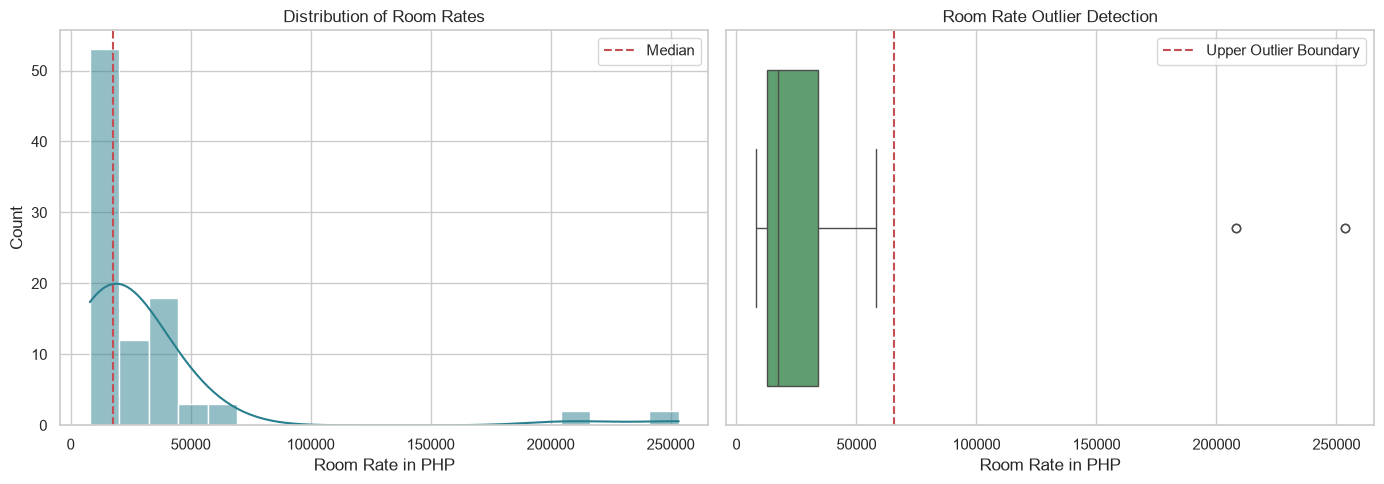

In [7]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.histplot(
    data=room_rates_df,
    x="rate_plan_price_php",
    bins=20,
    kde=True,
    ax=axes[0],
    color="#287F8E"
)

axes[0].axvline(
    room_price_column.median(),
    color="#C44E52",
    linestyle="--",
    label="Median"
)

axes[0].set_title(
    "Distribution of Room Rates"
)

axes[0].set_xlabel(
    "Room Rate in PHP"
)

axes[0].legend()

sns.boxplot(
    data=room_rates_df,
    x="rate_plan_price_php",
    ax=axes[1],
    color="#55A868"
)

axes[1].axvline(
    room_price_upper_bound,
    color="#C44E52",
    linestyle="--",
    label="Upper Outlier Boundary"
)

axes[1].set_title(
    "Room Rate Outlier Detection"
)

axes[1].set_xlabel(
    "Room Rate in PHP"
)

axes[1].legend()

plt.tight_layout()
plt.show()

### Room Rate Distribution and Outliers

The first quartile of room rates is PHP 12,900, while the third quartile is PHP 33,921. The interquartile range is PHP 21,021.

Using the interquartile range method, prices above PHP 65,452.50 are classified as statistical outliers. Four records exceeded this boundary. All four belong to the Presidential Villa, with rates ranging from PHP 208,300 to PHP 253,400.

### Statistical Interpretation

The room rate distribution is strongly positively skewed. Most room offers are concentrated in the lower price range, while the Presidential Villa creates a long upper tail.

The outliers are repeated observations of a legitimate premium accommodation rather than extraction errors. Removing them would eliminate an important hotel product and understate the complete range of prices.

### Business Implication

The Presidential Villa represents a distinct luxury segment and should be analyzed separately from standard rooms and suites. Overall averages are strongly influenced by its prices, so the median is a more representative measure of the typical room offer.

The hotel should report standard accommodation and luxury accommodation pricing separately when evaluating pricing position, promotional performance, or customer affordability.

In [8]:
standard_room_rates_df = room_rates_df[
    room_rates_df[
        "room_name"
    ].ne(
        "Presidential Villa"
    )
].copy()

room_segment_comparison_df = pd.DataFrame({
    "price_scope": [
        "All room offers",
        "Excluding Presidential Villa",
        "Presidential Villa only"
    ],
    "records": [
        len(room_rates_df),
        len(standard_room_rates_df),
        room_rates_df[
            "room_name"
        ].eq(
            "Presidential Villa"
        ).sum()
    ],
    "average_price_php": [
        room_rates_df[
            "rate_plan_price_php"
        ].mean(),
        standard_room_rates_df[
            "rate_plan_price_php"
        ].mean(),
        room_rates_df.loc[
            room_rates_df[
                "room_name"
            ].eq(
                "Presidential Villa"
            ),
            "rate_plan_price_php"
        ].mean()
    ],
    "median_price_php": [
        room_rates_df[
            "rate_plan_price_php"
        ].median(),
        standard_room_rates_df[
            "rate_plan_price_php"
        ].median(),
        room_rates_df.loc[
            room_rates_df[
                "room_name"
            ].eq(
                "Presidential Villa"
            ),
            "rate_plan_price_php"
        ].median()
    ],
    "minimum_price_php": [
        room_rates_df[
            "rate_plan_price_php"
        ].min(),
        standard_room_rates_df[
            "rate_plan_price_php"
        ].min(),
        room_rates_df.loc[
            room_rates_df[
                "room_name"
            ].eq(
                "Presidential Villa"
            ),
            "rate_plan_price_php"
        ].min()
    ],
    "maximum_price_php": [
        room_rates_df[
            "rate_plan_price_php"
        ].max(),
        standard_room_rates_df[
            "rate_plan_price_php"
        ].max(),
        room_rates_df.loc[
            room_rates_df[
                "room_name"
            ].eq(
                "Presidential Villa"
            ),
            "rate_plan_price_php"
        ].max()
    ]
})

display(
    room_segment_comparison_df.round(2)
)

average_price_reduction = (
    room_rates_df[
        "rate_plan_price_php"
    ].mean()
    - standard_room_rates_df[
        "rate_plan_price_php"
    ].mean()
)

average_price_reduction_percent = (
    average_price_reduction
    / room_rates_df[
        "rate_plan_price_php"
    ].mean()
    * 100
)

print(
    "Average price reduction:",
    round(
        average_price_reduction,
        2
    )
)

print(
    "Average price reduction percent:",
    round(
        average_price_reduction_percent,
        2
    )
)

,price_scope,records,average_price_php,median_price_php,minimum_price_php,maximum_price_php
0,All room offers,93,"31,089.70","17,500.00",8000,253400
1,Excluding Presidential Villa,89,"22,111.71","15,000.00",8000,58000
2,Presidential Villa only,4,"230,850.00","230,850.00",208300,253400


Average price reduction: 8977.99
Average price reduction percent: 28.88


### Influence of the Presidential Villa

The Presidential Villa accounts for four of the 93 room rate records. Its average rate is PHP 230,850, compared with PHP 22,111.71 for the remaining accommodations.

Excluding the villa reduces the overall average by PHP 8,977.99, equivalent to 28.88 percent. The median decreases by only PHP 2,500.

### Statistical Interpretation

A single luxury room category has a substantial influence on the arithmetic mean. The smaller change in the median confirms that the median is more resistant to extreme prices and better represents the center of the standard accommodation market.

### Business Implication

Management should avoid using the combined average room rate as the sole pricing benchmark because it overstates the typical customer price. Standard rooms and suites should be evaluated separately from the Presidential Villa when assessing affordability, competitive pricing, and promotional offers.

,day_type,records,unique_rooms,average_price_php,median_price_php,standard_deviation_php,minimum_price_php,maximum_price_php
0,Weekday,31,12,"24,332.61","20,000.00","12,504.25",11900,54700
1,Weekend,58,26,"20,924.67","14,100.00","13,253.49",8000,58000


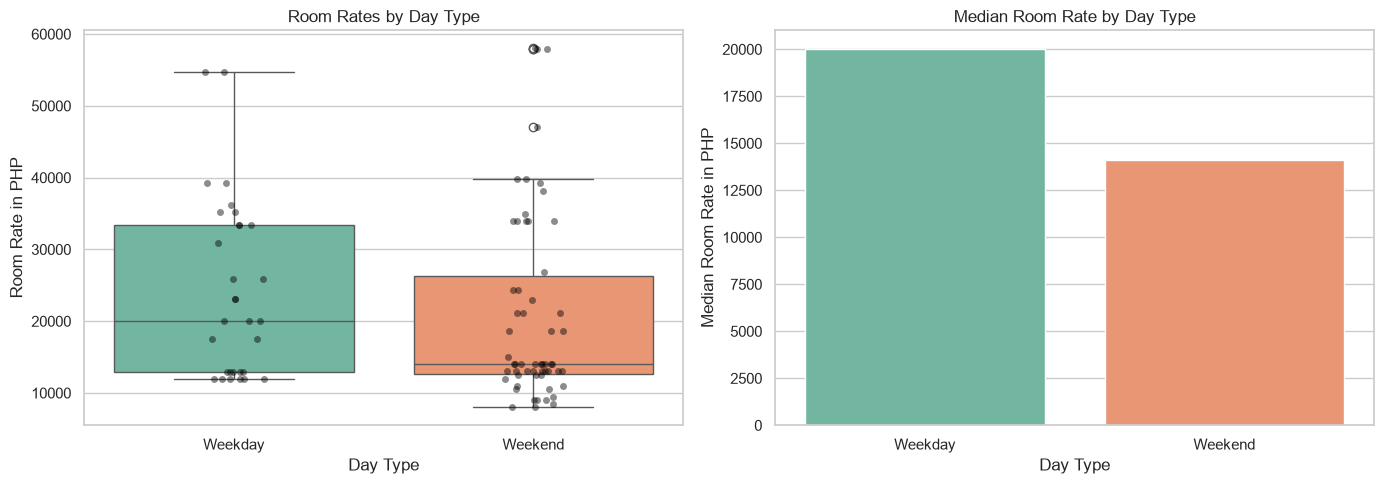

In [9]:
day_type_summary_df = (
    standard_room_rates_df.groupby(
        "day_type"
    )[
        "rate_plan_price_php"
    ]
    .agg(
        records="count",
        unique_rooms="nunique",
        average_price_php="mean",
        median_price_php="median",
        standard_deviation_php="std",
        minimum_price_php="min",
        maximum_price_php="max"
    )
    .reset_index()
)

display(
    day_type_summary_df.round(2)
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.boxplot(
    data=standard_room_rates_df,
    x="day_type",
    y="rate_plan_price_php",
    hue="day_type",
    legend=False,
    ax=axes[0],
    palette="Set2"
)

axes[0].set_title(
    "Room Rates by Day Type"
)

axes[0].set_xlabel(
    "Day Type"
)

axes[0].set_ylabel(
    "Room Rate in PHP"
)

sns.stripplot(
    data=standard_room_rates_df,
    x="day_type",
    y="rate_plan_price_php",
    ax=axes[0],
    color="black",
    alpha=0.45,
    jitter=True
)

sns.barplot(
    data=standard_room_rates_df,
    x="day_type",
    y="rate_plan_price_php",
    hue="day_type",
    legend=False,
    estimator=np.median,
    errorbar=None,
    ax=axes[1],
    palette="Set2"
)

axes[1].set_title(
    "Median Room Rate by Day Type"
)

axes[1].set_xlabel(
    "Day Type"
)

axes[1].set_ylabel(
    "Median Room Rate in PHP"
)

plt.tight_layout()
plt.show()

In [11]:
day_type_summary_df = (
    standard_room_rates_df.groupby(
        "day_type"
    )
    .agg(
        records=(
            "rate_plan_price_php",
            "count"
        ),
        unique_rooms=(
            "room_name",
            "nunique"
        ),
        unique_rate_plans=(
            "rate_plan_name",
            "nunique"
        ),
        average_price_php=(
            "rate_plan_price_php",
            "mean"
        ),
        median_price_php=(
            "rate_plan_price_php",
            "median"
        ),
        standard_deviation_php=(
            "rate_plan_price_php",
            "std"
        ),
        minimum_price_php=(
            "rate_plan_price_php",
            "min"
        ),
        maximum_price_php=(
            "rate_plan_price_php",
            "max"
        )
    )
    .reset_index()
)

display(
    day_type_summary_df.round(2)
)

weekday_median = day_type_summary_df.loc[
    day_type_summary_df[
        "day_type"
    ].eq(
        "Weekday"
    ),
    "median_price_php"
].iloc[0]

weekend_median = day_type_summary_df.loc[
    day_type_summary_df[
        "day_type"
    ].eq(
        "Weekend"
    ),
    "median_price_php"
].iloc[0]

median_difference = (
    weekend_median
    - weekday_median
)

median_difference_percent = (
    median_difference
    / weekday_median
    * 100
)

print(
    "Weekend minus weekday median:",
    round(
        median_difference,
        2
    )
)

print(
    "Median difference percent:",
    round(
        median_difference_percent,
        2
    )
)

,day_type,records,unique_rooms,unique_rate_plans,average_price_php,median_price_php,standard_deviation_php,minimum_price_php,maximum_price_php
0,Weekday,31,16,2,"24,332.61","20,000.00","12,504.25",11900,54700
1,Weekend,58,16,5,"20,924.67","14,100.00","13,253.49",8000,58000


Weekend minus weekday median: -5900.0
Median difference percent: -29.5


### Initial Weekday and Weekend Comparison

After excluding the Presidential Villa, the weekday median rate is PHP 20,000 and the weekend median is PHP 14,100. The observed weekend median is PHP 5,900 lower, equivalent to 29.50 percent.

### Statistical Interpretation

Both day types contain 16 unique room types, but the available rate plan composition differs substantially. Weekday searches contain two rate plans, while weekend searches contain five.

The observed price difference is therefore confounded by the mix of rate plans. It cannot yet be interpreted as a pure weekday or weekend pricing effect.

### Business Implication

The lower weekend median may reflect the availability of promotional or nonrefundable offers rather than a general weekend discount. Management should compare equivalent rooms under equivalent rate plans before making pricing decisions.

In [12]:
rate_plan_day_table = pd.crosstab(
    standard_room_rates_df[
        "rate_plan_name"
    ],
    standard_room_rates_df[
        "day_type"
    ]
)

display(
    rate_plan_day_table
)

matched_room_rates_df = (
    standard_room_rates_df.groupby(
        [
            "room_name",
            "rate_plan_name",
            "day_type"
        ],
        as_index=False
    )[
        "rate_plan_price_php"
    ]
    .median()
)

matched_room_rates_pivot_df = (
    matched_room_rates_df.pivot_table(
        index=[
            "room_name",
            "rate_plan_name"
        ],
        columns="day_type",
        values="rate_plan_price_php"
    )
    .dropna(
        subset=[
            "Weekday",
            "Weekend"
        ]
    )
    .reset_index()
)

matched_room_rates_pivot_df[
    "weekend_price_difference_php"
] = (
    matched_room_rates_pivot_df[
        "Weekend"
    ]
    - matched_room_rates_pivot_df[
        "Weekday"
    ]
)

matched_room_rates_pivot_df[
    "weekend_price_change_percent"
] = (
    matched_room_rates_pivot_df[
        "weekend_price_difference_php"
    ]
    / matched_room_rates_pivot_df[
        "Weekday"
    ]
    * 100
)

display(
    matched_room_rates_pivot_df.round(2)
)

print(
    "Matched room and rate plan pairs:",
    len(
        matched_room_rates_pivot_df
    )
)

print(
    "Average matched price difference:",
    round(
        matched_room_rates_pivot_df[
            "weekend_price_difference_php"
        ].mean(),
        2
    )
)

print(
    "Median matched price difference:",
    round(
        matched_room_rates_pivot_df[
            "weekend_price_difference_php"
        ].median(),
        2
    )
)

print(
    "Average matched percentage change:",
    round(
        matched_room_rates_pivot_df[
            "weekend_price_change_percent"
        ].mean(),
        2
    )
)

day_type,Weekday,Weekend
rate_plan_name,,
Best Available Rate,29,29
Elevated Escapes,2,4
"Plan Ahead, Pay Less",0,4
"Rain, Rain Getaway!",0,8
Weekend Feast Escape,0,13


day_type,room_name,rate_plan_name,Weekday,Weekend,weekend_price_difference_php,weekend_price_change_percent
0,Batangas Suite Two Bedroom,Best Available Rate,"36,200.00","39,200.00","3,000.00",8.29
1,Deluxe King,Best Available Rate,"12,900.00","14,100.00","1,200.00",9.30
2,Deluxe King,Elevated Escapes,"12,900.00","14,100.00","1,200.00",9.30
3,Deluxe Mountain,Best Available Rate,"11,900.00","13,100.00","1,200.00",10.08
4,Deluxe Queen,Best Available Rate,"12,900.00","14,100.00","1,200.00",9.30
5,Deluxe Suite Mountain (2 Bedroom),Best Available Rate,"32,128.50","33,910.50","1,782.00",5.55
6,Deluxe Suite One Bedroom,Best Available Rate,"23,100.00","24,300.00","1,200.00",5.19
7,Deluxe Suite Two Bedroom,Best Available Rate,"33,357.00","33,921.00",564.00,1.69
8,Deluxe Twin,Best Available Rate,"12,900.00","14,100.00","1,200.00",9.30
9,Premier Queen,Best Available Rate,"20,000.00","21,100.00","1,100.00",5.50


Matched room and rate plan pairs: 18
Average matched price difference: 1450.56
Median matched price difference: 1200.0
Average matched percentage change: 6.98


### Matched Weekday and Weekend Room Rates

The initial unmatched comparison suggested that weekend room rates were lower. However, weekend searches contained several additional promotional plans that were unavailable in the weekday searches.

After matching equivalent room and rate plan combinations, weekend prices were an average of PHP 1,450.56 higher. The median increase was PHP 1,200, and the average percentage increase was 6.98 percent.

### Statistical Interpretation

The unmatched and matched comparisons lead to opposite conclusions. This demonstrates that rate plan composition confounded the initial comparison.

Promotional weekend offers lowered the overall weekend median, even though equivalent room and rate plan combinations were generally more expensive during weekends.

### Business Implication

Management should compare equivalent products before evaluating weekday and weekend pricing. The results suggest that the hotel applies higher weekend prices to comparable offers while also using promotional plans to provide lower entry prices for selected rooms.

For formal hypothesis testing, only the Best Available Rate will be used so that every room contributes one comparable weekday and weekend pair.

In [13]:
best_available_matched_df = (
    matched_room_rates_pivot_df[
        matched_room_rates_pivot_df[
            "rate_plan_name"
        ].eq(
            "Best Available Rate"
        )
    ]
    .copy()
)

best_available_differences = (
    best_available_matched_df[
        "weekend_price_difference_php"
    ]
)

shapiro_statistic, shapiro_p_value = (
    stats.shapiro(
        best_available_differences
    )
)

print(
    "Best Available Rate pairs:",
    len(
        best_available_matched_df
    )
)

print(
    "Shapiro Wilk statistic:",
    round(
        shapiro_statistic,
        4
    )
)

print(
    "P value:",
    round(
        shapiro_p_value,
        4
    )
)

print(
    "Alpha level:",
    0.05
)

if shapiro_p_value < 0.05:
    print(
        "Decision: Reject the null hypothesis"
    )
    print(
        "Conclusion: The paired differences are not normally distributed"
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis"
    )
    print(
        "Conclusion: Normality was not rejected"
    )

Best Available Rate pairs: 16
Shapiro Wilk statistic: 0.7416
P value: 0.0005
Alpha level: 0.05
Decision: Reject the null hypothesis
Conclusion: The paired differences are not normally distributed


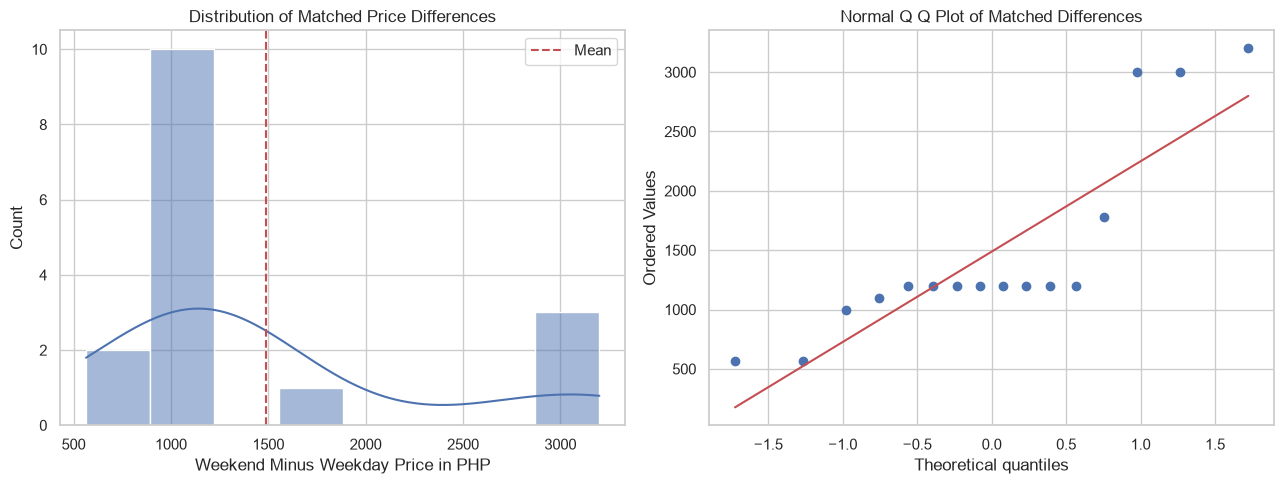

In [14]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

sns.histplot(
    best_available_differences,
    bins=8,
    kde=True,
    ax=axes[0],
    color="#4C72B0"
)

axes[0].axvline(
    best_available_differences.mean(),
    color="#C44E52",
    linestyle="--",
    label="Mean"
)

axes[0].set_title(
    "Distribution of Matched Price Differences"
)

axes[0].set_xlabel(
    "Weekend Minus Weekday Price in PHP"
)

axes[0].legend()

stats.probplot(
    best_available_differences,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title(
    "Normal Q Q Plot of Matched Differences"
)

plt.tight_layout()
plt.show()

### Normality Test for Matched Price Differences

The Shapiro Wilk test produced a statistic of 0.7416 and a p value of 0.0005.

At the 0.05 significance level, the p value is below alpha. The null hypothesis of normality is rejected.

### Statistical Interpretation

The matched weekend and weekday price differences are not normally distributed. The paired t test assumption is therefore not satisfied.

The Wilcoxon signed rank test will be used because it provides a nonparametric comparison of paired observations without requiring normally distributed differences.

### Business Implication

The pricing differences are concentrated around several repeated increases rather than forming a symmetric normal distribution. A nonparametric test provides a more reliable assessment of whether comparable weekend prices tend to be higher.

In [15]:
wilcoxon_result = stats.wilcoxon(
    best_available_matched_df[
        "Weekend"
    ],
    best_available_matched_df[
        "Weekday"
    ],
    alternative="greater",
    method="exact"
)

wilcoxon_statistic = (
    wilcoxon_result.statistic
)

wilcoxon_p_value = (
    wilcoxon_result.pvalue
)

positive_rank_sum = (
    wilcoxon_statistic
)

total_rank_sum = (
    len(
        best_available_differences
    )
    * (
        len(
            best_available_differences
        )
        + 1
    )
    / 2
)

negative_rank_sum = (
    total_rank_sum
    - positive_rank_sum
)

rank_biserial_correlation = (
    positive_rank_sum
    - negative_rank_sum
) / total_rank_sum

print(
    "Wilcoxon statistic:",
    wilcoxon_statistic
)

print(
    "P value:",
    round(
        wilcoxon_p_value,
        6
    )
)

print(
    "Alpha level:",
    0.05
)

print(
    "Median price difference:",
    best_available_differences.median()
)

print(
    "Rank biserial correlation:",
    round(
        rank_biserial_correlation,
        4
    )
)

if wilcoxon_p_value < 0.05:
    print(
        "Decision: Reject the null hypothesis"
    )
    print(
        "Conclusion: Weekend rates are significantly higher"
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis"
    )
    print(
        "Conclusion: There is insufficient evidence that weekend rates are higher"
    )

Wilcoxon statistic: 136.0
P value: 1.5e-05
Alpha level: 0.05
Median price difference: 1200.0
Rank biserial correlation: 1.0
Decision: Reject the null hypothesis
Conclusion: Weekend rates are significantly higher


In [18]:
absolute_differences = (
    best_available_differences.abs()
)

average_ranks = stats.rankdata(
    absolute_differences,
    method="average"
)

observed_positive_rank_sum = (
    average_ranks[
        best_available_differences
        > 0
    ].sum()
)

exact_positive_rank_sums = []

for signs in product(
    [0, 1],
    repeat=len(
        average_ranks
    )
):
    positive_rank_sum = sum(
        rank * sign
        for rank, sign in zip(
            average_ranks,
            signs
        )
    )

    exact_positive_rank_sums.append(
        positive_rank_sum
    )

exact_positive_rank_sums = pd.Series(
    exact_positive_rank_sums
)

possible_statistics = sorted(
    exact_positive_rank_sums.unique()
)

upper_critical_value = next(
    statistic
    for statistic in possible_statistics
    if (
        exact_positive_rank_sums
        >= statistic
    ).mean() <= 0.05
)

exact_p_value = (
    exact_positive_rank_sums
    >= observed_positive_rank_sum
).mean()

print(
    "Lower critical value:",
    "Not applicable for this upper tailed test"
)

print(
    "Upper critical value:",
    upper_critical_value
)

print(
    "Observed positive rank sum:",
    observed_positive_rank_sum
)

print(
    "Exact one sided p value:",
    round(
        exact_p_value,
        6
    )
)

print(
    "Rejection region:",
    f"W positive is at least {upper_critical_value}"
)

Lower critical value: Not applicable for this upper tailed test
Upper critical value: 99.5
Observed positive rank sum: 136.0
Exact one sided p value: 1.5e-05
Rejection region: W positive is at least 99.5


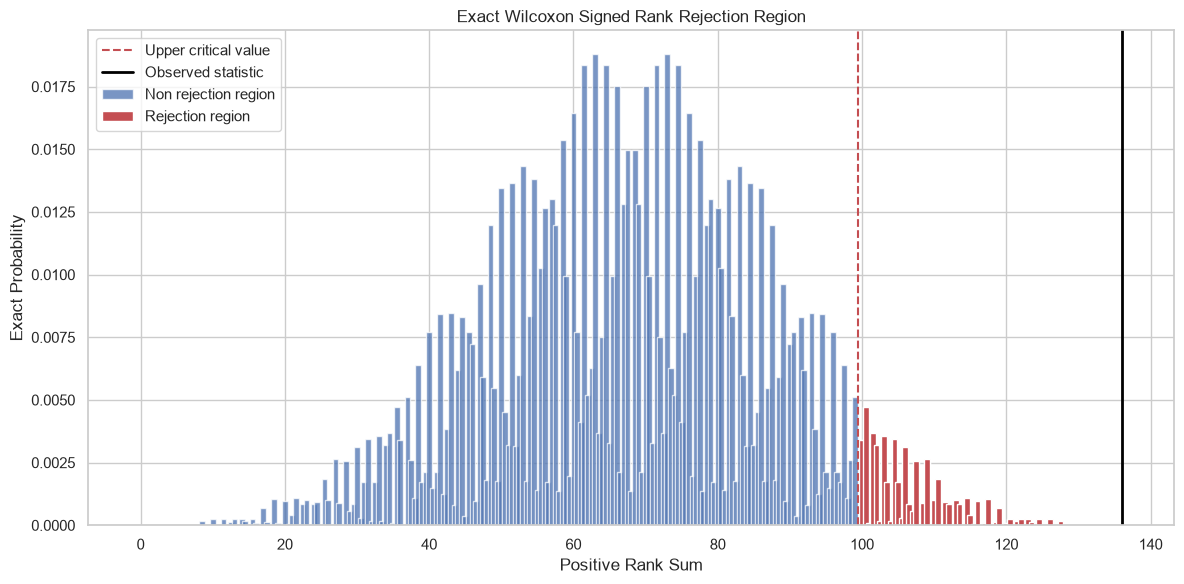

In [19]:
wilcoxon_probability_df = (
    exact_positive_rank_sums
    .value_counts(
        normalize=True
    )
    .sort_index()
    .rename_axis(
        "positive_rank_sum"
    )
    .reset_index(
        name="probability"
    )
)

rejection_region_df = (
    wilcoxon_probability_df[
        wilcoxon_probability_df[
            "positive_rank_sum"
        ]
        >= upper_critical_value
    ]
)

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    wilcoxon_probability_df[
        "positive_rank_sum"
    ],
    wilcoxon_probability_df[
        "probability"
    ],
    color="#4C72B0",
    alpha=0.75,
    label="Non rejection region"
)

plt.bar(
    rejection_region_df[
        "positive_rank_sum"
    ],
    rejection_region_df[
        "probability"
    ],
    color="#C44E52",
    label="Rejection region"
)

plt.axvline(
    upper_critical_value,
    color="#C44E52",
    linestyle="--",
    label="Upper critical value"
)

plt.axvline(
    observed_positive_rank_sum,
    color="black",
    linewidth=2,
    label="Observed statistic"
)

plt.title(
    "Exact Wilcoxon Signed Rank Rejection Region"
)

plt.xlabel(
    "Positive Rank Sum"
)

plt.ylabel(
    "Exact Probability"
)

plt.legend()
plt.tight_layout()
plt.show()

### Wilcoxon Signed Rank Test Result

The tie adjusted exact Wilcoxon signed rank test produced an observed positive rank sum of 136. The upper critical value was 99.5 at an alpha level of 0.05. The exact one sided p value was 0.000015.

The observed statistic falls inside the upper rejection region. The null hypothesis is rejected.

The median weekend increase was PHP 1,200. The rank biserial correlation was 1.00, indicating the maximum possible directional effect because every matched room had a higher weekend Best Available Rate.

### Statistical Interpretation

There is statistically significant evidence that weekend Best Available Rates are higher than weekday Best Available Rates for comparable rooms in the observed searches.

The result is supported by complete directional consistency across all 16 matched room types. However, it describes four selected booking dates and should not be generalized to every date of the year without additional observations.

### Business Implication

The hotel appears to apply a consistent weekend price premium to its Best Available Rate. This supports a revenue strategy that charges more during higher value weekend periods.

Management should continue monitoring whether the weekend premium improves room revenue without reducing conversion or occupancy. Additional dates should be collected before using the estimated PHP 1,200 median increase as a permanent annual pricing benchmark.

In [20]:
best_available_rates_df = (
    room_rates_df[
        room_rates_df[
            "rate_plan_name"
        ].eq(
            "Best Available Rate"
        )
    ][
        [
            "search_id",
            "room_name",
            "rate_plan_price_php"
        ]
    ]
    .rename(
        columns={
            "rate_plan_price_php":
            "best_available_price_php"
        }
    )
)

rate_plan_comparison_df = (
    room_rates_df.merge(
        best_available_rates_df,
        on=[
            "search_id",
            "room_name"
        ],
        how="left"
    )
)

rate_plan_comparison_df[
    "price_difference_from_best_php"
] = (
    rate_plan_comparison_df[
        "rate_plan_price_php"
    ]
    - rate_plan_comparison_df[
        "best_available_price_php"
    ]
)

rate_plan_comparison_df[
    "price_difference_from_best_percent"
] = (
    rate_plan_comparison_df[
        "price_difference_from_best_php"
    ]
    / rate_plan_comparison_df[
        "best_available_price_php"
    ]
    * 100
)

alternative_rate_plans_df = (
    rate_plan_comparison_df[
        rate_plan_comparison_df[
            "rate_plan_name"
        ].ne(
            "Best Available Rate"
        )
        & rate_plan_comparison_df[
            "best_available_price_php"
        ].notna()
    ]
    .copy()
)

rate_plan_discount_summary_df = (
    alternative_rate_plans_df.groupby(
        "rate_plan_name"
    )
    .agg(
        offers=(
            "rate_plan_price_php",
            "count"
        ),
        average_rate_php=(
            "rate_plan_price_php",
            "mean"
        ),
        average_difference_php=(
            "price_difference_from_best_php",
            "mean"
        ),
        median_difference_php=(
            "price_difference_from_best_php",
            "median"
        ),
        average_difference_percent=(
            "price_difference_from_best_percent",
            "mean"
        ),
        minimum_difference_percent=(
            "price_difference_from_best_percent",
            "min"
        ),
        maximum_difference_percent=(
            "price_difference_from_best_percent",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "average_difference_percent"
    )
)

display(
    rate_plan_discount_summary_df.round(2)
)

print(
    "Alternative offers matched:",
    len(
        alternative_rate_plans_df
    )
)

print(
    "Alternative offers without a matching Best Available Rate:",
    (
        room_rates_df[
            "rate_plan_name"
        ].ne(
            "Best Available Rate"
        ).sum()
        - len(
            alternative_rate_plans_df
        )
    )
)

,rate_plan_name,offers,average_rate_php,average_difference_php,median_difference_php,average_difference_percent,minimum_difference_percent,maximum_difference_percent
2,"Rain, Rain Getaway!",8,"9,000.00","-6,175.00","-5,100.00",-39.82,-49.20,-35.11
3,Weekend Feast Escape,13,"22,576.92","-1,363.54","-1,600.00",-10.63,-35.83,18.14
0,Elevated Escapes,6,"16,050.00",0.00,0.00,0.00,0.00,0.00
1,"Plan Ahead, Pay Less",4,"14,500.00",0.00,0.00,0.00,0.00,0.00


Alternative offers matched: 31
Alternative offers without a matching Best Available Rate: 4


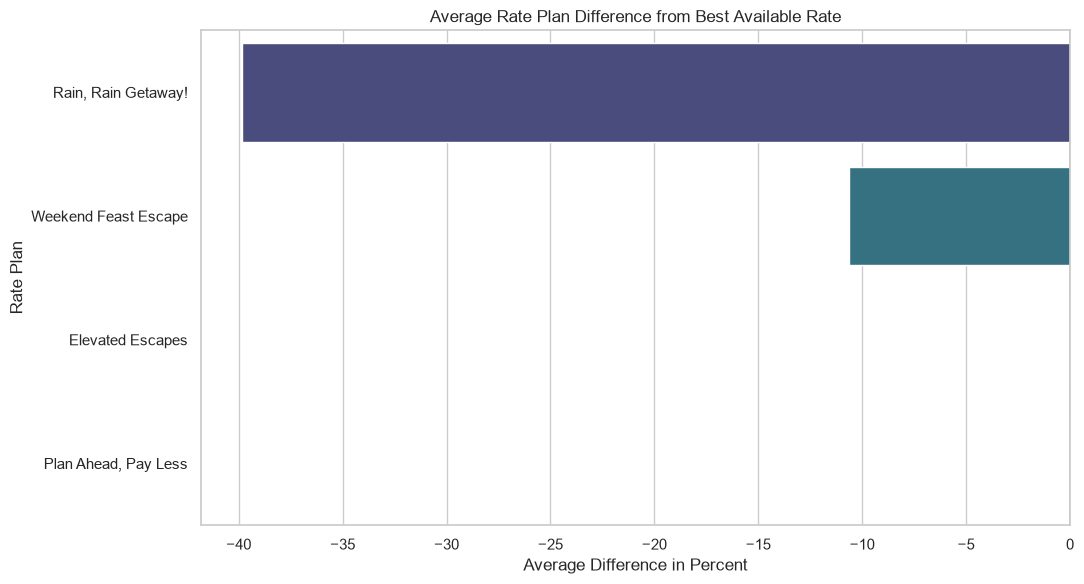

In [21]:
plt.figure(
    figsize=(11, 6)
)

sns.barplot(
    data=rate_plan_discount_summary_df,
    x="average_difference_percent",
    y="rate_plan_name",
    hue="rate_plan_name",
    legend=False,
    palette="viridis"
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.title(
    "Average Rate Plan Difference from Best Available Rate"
)

plt.xlabel(
    "Average Difference in Percent"
)

plt.ylabel(
    "Rate Plan"
)

plt.tight_layout()
plt.show()

## Rate Plan Comparison

Thirty one alternative offers were matched with the Best Available Rate for the same room and booking search. Four Presidential Preferred offers could not be matched because the Presidential Villa had no corresponding Best Available Rate.

Rain, Rain Getaway offered the largest observed reduction, averaging 39.82 percent below the Best Available Rate. Weekend Feast Escape averaged 10.63 percent below the baseline, although individual differences ranged from a 35.83 percent discount to an 18.14 percent premium.

Elevated Escapes and Plan Ahead, Pay Less displayed the same prices as the Best Available Rate in the observed searches.

### Statistical Interpretation

Promotional plan names do not consistently indicate lower prices. Rain, Rain Getaway produced a substantial and consistent discount, while Weekend Feast Escape showed considerable variation across rooms.

The zero average differences for Elevated Escapes and Plan Ahead, Pay Less indicate that their observed monetary prices were identical to the comparable Best Available Rates.

### Business Implication

Rain, Rain Getaway appears to function as the strongest price promotion and may attract price sensitive customers.

Weekend Feast Escape should not automatically be described as a discount because

In [22]:
print(
    "Cancellation policies by rate plan:"
)

display(
    pd.crosstab(
        room_rates_df[
            "rate_plan_name"
        ],
        room_rates_df[
            "cancellation_policy"
        ]
    )
)

print(
    "Payment requirements by rate plan:"
)

display(
    pd.crosstab(
        room_rates_df[
            "rate_plan_name"
        ],
        room_rates_df[
            "payment_requirement"
        ]
    )
)

print(
    "Breakfast inclusion by rate plan:"
)

display(
    pd.crosstab(
        room_rates_df[
            "rate_plan_name"
        ],
        room_rates_df[
            "breakfast_included"
        ]
    )
)

Cancellation policies by rate plan:


cancellation_policy,Free cancellation or modification until 7 days before arrival,Nonrefundable,Nonrefundable. Modification or cancellation is not allowed.
rate_plan_name,,,
Best Available Rate,58,0,0
Elevated Escapes,0,6,0
"Plan Ahead, Pay Less",0,4,0
Presidential Preferred,0,3,1
"Rain, Rain Getaway!",0,8,0
Weekend Feast Escape,0,13,0


Payment requirements by rate plan:


payment_requirement,Full prepayment required,"Reservation guarantee required through credit card, cash payment, or bank deposit"
rate_plan_name,,
Best Available Rate,0,58
Elevated Escapes,6,0
"Plan Ahead, Pay Less",4,0
Presidential Preferred,4,0
"Rain, Rain Getaway!",8,0
Weekend Feast Escape,13,0


Breakfast inclusion by rate plan:


breakfast_included,True
rate_plan_name,
Best Available Rate,58
Elevated Escapes,6
"Plan Ahead, Pay Less",4
Presidential Preferred,4
"Rain, Rain Getaway!",8
Weekend Feast Escape,13


In [23]:
weekend_feast_comparison_df = (
    alternative_rate_plans_df[
        alternative_rate_plans_df[
            "rate_plan_name"
        ].eq(
            "Weekend Feast Escape"
        )
    ][
        [
            "search_id",
            "room_name",
            "rate_plan_price_php",
            "best_available_price_php",
            "price_difference_from_best_php",
            "price_difference_from_best_percent",
            "breakfast_included",
            "cancellation_policy",
            "payment_requirement"
        ]
    ]
    .sort_values(
        "price_difference_from_best_percent"
    )
)

display(
    weekend_feast_comparison_df.round(2)
)

print(
    "Weekend Feast discounted offers:",
    (
        weekend_feast_comparison_df[
            "price_difference_from_best_php"
        ] < 0
    ).sum()
)

print(
    "Weekend Feast equal priced offers:",
    (
        weekend_feast_comparison_df[
            "price_difference_from_best_php"
        ] == 0
    ).sum()
)

print(
    "Weekend Feast premium offers:",
    (
        weekend_feast_comparison_df[
            "price_difference_from_best_php"
        ] > 0
    ).sum()
)

,search_id,room_name,rate_plan_price_php,best_available_price_php,price_difference_from_best_php,price_difference_from_best_percent,breakfast_included,cancellation_policy,payment_requirement
35,2,Ridge,12000,"18,700.00","-6,700.00",-35.83,True,Nonrefundable,Full prepayment required
38,2,Premier Queen,15000,"21,100.00","-6,100.00",-28.91,True,Nonrefundable,Full prepayment required
17,2,Superior King,10500,"13,100.00","-2,600.00",-19.85,True,Nonrefundable,Full prepayment required
20,2,Superior Twin,10500,"13,100.00","-2,600.00",-19.85,True,Nonrefundable,Full prepayment required
32,2,Deluxe Mountain,11000,"13,100.00","-2,100.00",-16.03,True,Nonrefundable,Full prepayment required
23,2,Deluxe King,12500,"14,100.00","-1,600.00",-11.35,True,Nonrefundable,Full prepayment required
26,2,Deluxe Queen,12500,"14,100.00","-1,600.00",-11.35,True,Nonrefundable,Full prepayment required
29,2,Deluxe Twin,12500,"14,100.00","-1,600.00",-11.35,True,Nonrefundable,Full prepayment required
40,2,Deluxe Suite One Bedroom,23000,"24,300.00","-1,300.00",-5.35,True,Nonrefundable,Full prepayment required
49,2,Tagaytay Suite Two Bedroom,58000,"57,900.00",100.00,0.17,True,Nonrefundable,Full prepayment required


Weekend Feast discounted offers: 9
Weekend Feast equal priced offers: 0
Weekend Feast premium offers: 4


### Rate Plan Conditions

The Best Available Rate permits free cancellation or modification until seven days before arrival and requires a reservation guarantee.

All alternative plans are nonrefundable and require full prepayment. Breakfast is included across every observed rate plan, so breakfast inclusion does not explain the differences in price.

Weekend Feast Escape was cheaper than the Best Available Rate for 9 of 13 rooms. However, it was more expensive for four rooms, with the largest premium reaching 18.14 percent.

### Statistical Interpretation

Weekend Feast Escape produced a lower price in 69.23 percent of its matched room offers. The remaining 30.77 percent were priced above the flexible Best Available Rate.

The wide range of price differences shows that the plan does not provide a consistent monetary discount across room categories.

### Business Implication

Customers should be shown both the price difference and booking restrictions clearly. A nonrefundable plan priced above a flexible alternative may reduce trust and booking conversion unless it includes additional benefits that justify the premium.

Management should review the four premium Weekend Feast offers and confirm whether their inclusions provide sufficient value.

In [24]:
weekend_feast_discount_count = (
    weekend_feast_comparison_df[
        "price_difference_from_best_php"
    ].lt(
        0
    ).sum()
)

weekend_feast_offer_count = len(
    weekend_feast_comparison_df
)

observed_discount_probability = (
    weekend_feast_discount_count
    / weekend_feast_offer_count
)

binomial_result = stats.binomtest(
    weekend_feast_discount_count,
    n=weekend_feast_offer_count,
    p=0.50,
    alternative="greater"
)

confidence_interval = (
    binomial_result.proportion_ci(
        confidence_level=0.95,
        method="wilson"
    )
)

print(
    "Discounted offers:",
    weekend_feast_discount_count
)

print(
    "Total offers:",
    weekend_feast_offer_count
)

print(
    "Observed discount probability:",
    round(
        observed_discount_probability,
        4
    )
)

print(
    "Exact binomial p value:",
    round(
        binomial_result.pvalue,
        4
    )
)

print(
    "Confidence interval lower bound:",
    round(
        confidence_interval.low,
        4
    )
)

print(
    "Confidence interval upper bound:",
    round(
        confidence_interval.high,
        4
    )
)

if binomial_result.pvalue < 0.05:
    print(
        "Decision: Reject the null hypothesis"
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis"
    )

Discounted offers: 9
Total offers: 13
Observed discount probability: 0.6923
Exact binomial p value: 0.1334
Confidence interval lower bound: 0.4648
Confidence interval upper bound: 1.0
Decision: Fail to reject the null hypothesis


In [25]:
alpha_level = 0.05

possible_discount_counts = np.arange(
    0,
    weekend_feast_offer_count + 1
)

binomial_probabilities = stats.binom.pmf(
    possible_discount_counts,
    weekend_feast_offer_count,
    0.50
)

upper_critical_value = next(
    discount_count
    for discount_count
    in possible_discount_counts
    if stats.binom.sf(
        discount_count - 1,
        weekend_feast_offer_count,
        0.50
    ) <= alpha_level
)

print(
    "Lower critical value:",
    "Not applicable for this upper tailed test"
)

print(
    "Upper critical value:",
    upper_critical_value
)

print(
    "Observed discounted offers:",
    weekend_feast_discount_count
)

print(
    "Rejection region:",
    f"Discounted offers are at least {upper_critical_value}"
)

Lower critical value: Not applicable for this upper tailed test
Upper critical value: 10
Observed discounted offers: 9
Rejection region: Discounted offers are at least 10


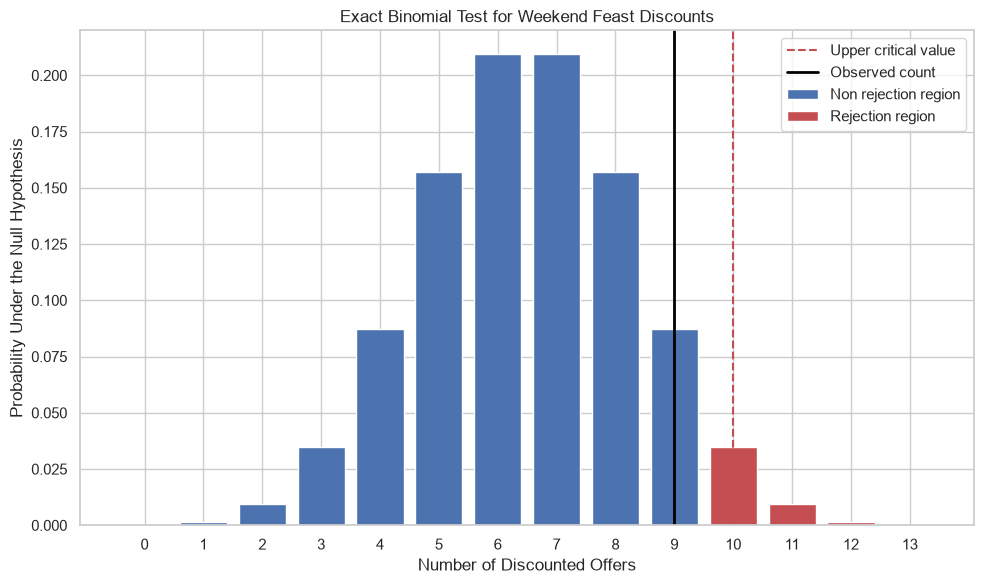

In [26]:
rejection_mask = (
    possible_discount_counts
    >= upper_critical_value
)

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    possible_discount_counts[
        ~rejection_mask
    ],
    binomial_probabilities[
        ~rejection_mask
    ],
    color="#4C72B0",
    label="Non rejection region"
)

plt.bar(
    possible_discount_counts[
        rejection_mask
    ],
    binomial_probabilities[
        rejection_mask
    ],
    color="#C44E52",
    label="Rejection region"
)

plt.axvline(
    upper_critical_value,
    color="#C44E52",
    linestyle="--",
    label="Upper critical value"
)

plt.axvline(
    weekend_feast_discount_count,
    color="black",
    linewidth=2,
    label="Observed count"
)

plt.title(
    "Exact Binomial Test for Weekend Feast Discounts"
)

plt.xlabel(
    "Number of Discounted Offers"
)

plt.ylabel(
    "Probability Under the Null Hypothesis"
)

plt.xticks(
    possible_discount_counts
)

plt.legend()
plt.tight_layout()
plt.show()

In [27]:
null_discount_probability = 0.50

cohens_h = (
    2
    * np.arcsin(
        np.sqrt(
            observed_discount_probability
        )
    )
    - 2
    * np.arcsin(
        np.sqrt(
            null_discount_probability
        )
    )
)

print(
    "Cohen h effect size:",
    round(
        cohens_h,
        4
    )
)

if abs(cohens_h) < 0.20:
    print(
        "Effect size interpretation: Negligible"
    )
elif abs(cohens_h) < 0.50:
    print(
        "Effect size interpretation: Small"
    )
elif abs(cohens_h) < 0.80:
    print(
        "Effect size interpretation: Medium"
    )
else:
    print(
        "Effect size interpretation: Large"
    )

Cohen h effect size: 0.3948
Effect size interpretation: Small


### Probability of a Weekend Feast Discount

Weekend Feast Escape was cheaper than the Best Available Rate for 9 of 13 matched rooms, producing an observed discount probability of 69.23 percent.

The exact binomial test produced a p value of 0.1334. At the 0.05 alpha level, the observed count of nine discounted offers did not reach the upper critical value of ten.

The null hypothesis was not rejected. The 95 percent one sided Wilson confidence interval ranged from 46.48 percent to 100 percent.

### Statistical Interpretation

The sample shows more discounted than premium offers, but there is insufficient statistical evidence to conclude that Weekend Feast Escape has a greater than 50 percent probability of offering a discount.

Failing to reject the null hypothesis does not prove that the discount probability equals 50 percent. It means that 13 observations provide insufficient evidence for the stronger claim.

The expected Cohen h of approximately 0.39 indicates a small practical difference from the 50 percent benchmark, but the estimate remains uncertain because of the limited sample size.

### Business Implication

Weekend Feast Escape should not be presented as a consistently discounted plan based on the current evidence. Customers still faced a premium for 4 of 13 room offers while accepting nonrefundable conditions and full prepayment.

Management should review the pricing rules and collect more booking dates before claiming that this plan usually provides a lower price. Clear comparison against the flexible Best Available Rate may improve transparency and customer trust.

In [28]:
room_size_price_df = (
    room_rates_df[
        room_rates_df[
            "rate_plan_name"
        ].eq(
            "Best Available Rate"
        )
    ]
    .groupby(
        "room_name",
        as_index=False
    )
    .agg(
        room_size_sqm=(
            "room_size_sqm",
            "median"
        ),
        median_best_available_rate_php=(
            "rate_plan_price_php",
            "median"
        ),
        minimum_best_available_rate_php=(
            "rate_plan_price_php",
            "min"
        ),
        maximum_best_available_rate_php=(
            "rate_plan_price_php",
            "max"
        ),
        number_of_observations=(
            "rate_plan_price_php",
            "count"
        )
    )
)

display(
    room_size_price_df.sort_values(
        "room_size_sqm"
    )
)

print(
    "Rooms included:",
    len(
        room_size_price_df
    )
)

print(
    "Missing room sizes:",
    room_size_price_df[
        "room_size_sqm"
    ].isna().sum()
)

print(
    "Minimum room size:",
    room_size_price_df[
        "room_size_sqm"
    ].min()
)

print(
    "Maximum room size:",
    room_size_price_df[
        "room_size_sqm"
    ].max()
)

,room_name,room_size_sqm,median_best_available_rate_php,minimum_best_available_rate_php,maximum_best_available_rate_php,number_of_observations
2,Deluxe Mountain,29.00,"12,500.00",11900,13100,4
10,Superior King,29.00,"12,500.00",11900,13100,4
11,Superior Twin,29.00,"12,500.00",11900,13100,4
1,Deluxe King,34.00,"13,500.00",12900,14100,4
3,Deluxe Queen,34.00,"14,100.00",12900,14100,3
7,Deluxe Twin,34.00,"14,100.00",12900,14100,3
9,Ridge,37.00,"18,100.00",17500,18700,4
8,Premier Queen,38.00,"20,550.00",20000,21100,4
5,Deluxe Suite One Bedroom,62.00,"23,700.00",23100,24300,4
6,Deluxe Suite Two Bedroom,62.00,"33,639.00",33357,33921,4


Rooms included: 16
Missing room sizes: 0
Minimum room size: 29.0
Maximum room size: 196.0


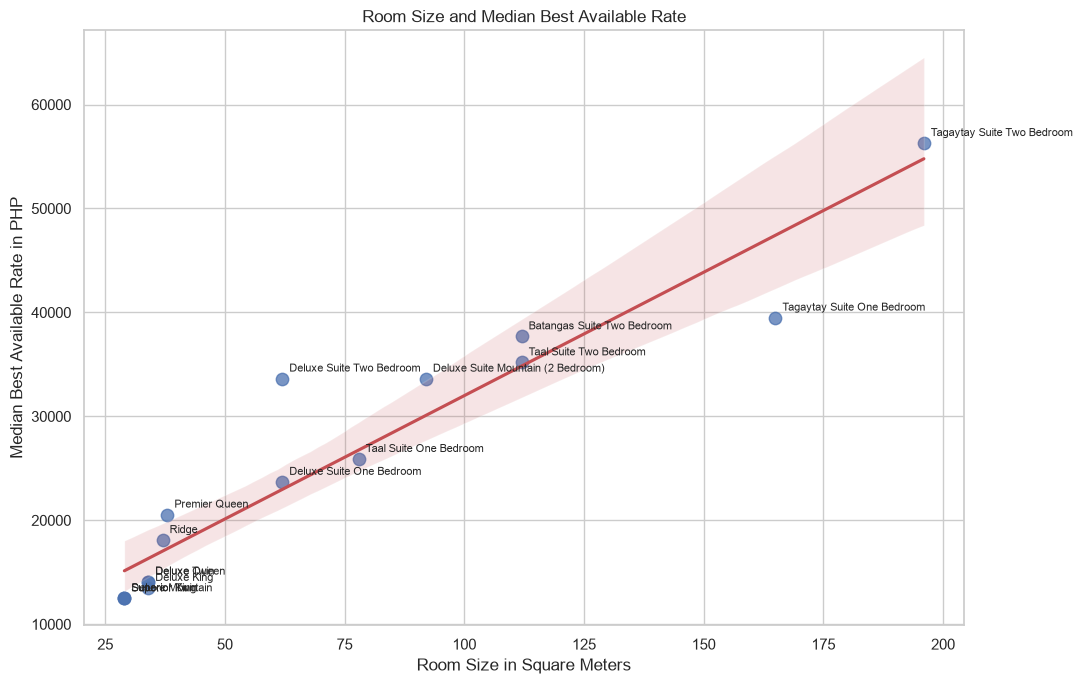

In [29]:
plt.figure(
    figsize=(11, 7)
)

sns.regplot(
    data=room_size_price_df,
    x="room_size_sqm",
    y="median_best_available_rate_php",
    scatter_kws={
        "s": 80,
        "alpha": 0.75
    },
    line_kws={
        "color": "#C44E52"
    }
)

for _, room_record in (
    room_size_price_df.iterrows()
):
    plt.annotate(
        room_record[
            "room_name"
        ],
        (
            room_record[
                "room_size_sqm"
            ],
            room_record[
                "median_best_available_rate_php"
            ]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title(
    "Room Size and Median Best Available Rate"
)

plt.xlabel(
    "Room Size in Square Meters"
)

plt.ylabel(
    "Median Best Available Rate in PHP"
)

plt.tight_layout()
plt.show()

In [30]:
room_relationship_columns = [
    "room_size_sqm",
    "median_best_available_rate_php"
]

relationship_diagnostics = []

for column_name in room_relationship_columns:
    current_values = (
        room_size_price_df[
            column_name
        ]
    )

    first_quartile = (
        current_values.quantile(
            0.25
        )
    )

    third_quartile = (
        current_values.quantile(
            0.75
        )
    )

    interquartile_range = (
        third_quartile
        - first_quartile
    )

    lower_boundary = (
        first_quartile
        - 1.5
        * interquartile_range
    )

    upper_boundary = (
        third_quartile
        + 1.5
        * interquartile_range
    )

    outlier_count = (
        (
            current_values
            < lower_boundary
        )
        | (
            current_values
            > upper_boundary
        )
    ).sum()

    shapiro_statistic, shapiro_p_value = (
        stats.shapiro(
            current_values
        )
    )

    relationship_diagnostics.append({
        "variable": column_name,
        "first_quartile": first_quartile,
        "third_quartile": third_quartile,
        "interquartile_range": (
            interquartile_range
        ),
        "lower_boundary": lower_boundary,
        "upper_boundary": upper_boundary,
        "outliers": outlier_count,
        "shapiro_statistic": (
            shapiro_statistic
        ),
        "shapiro_p_value": (
            shapiro_p_value
        ),
        "normal_distribution": (
            shapiro_p_value
            >= 0.05
        )
    })

relationship_diagnostics_df = pd.DataFrame(
    relationship_diagnostics
)

display(
    relationship_diagnostics_df.round(4)
)

,variable,first_quartile,third_quartile,interquartile_range,lower_boundary,upper_boundary,outliers,shapiro_statistic,shapiro_p_value,normal_distribution
0,room_size_sqm,34.00,97.00,63.00,-60.50,191.50,1,0.81,0.00,False
1,median_best_available_rate_php,"13,950.00","34,029.25","20,079.25","-16,168.88","64,148.12",0,0.88,0.03,False


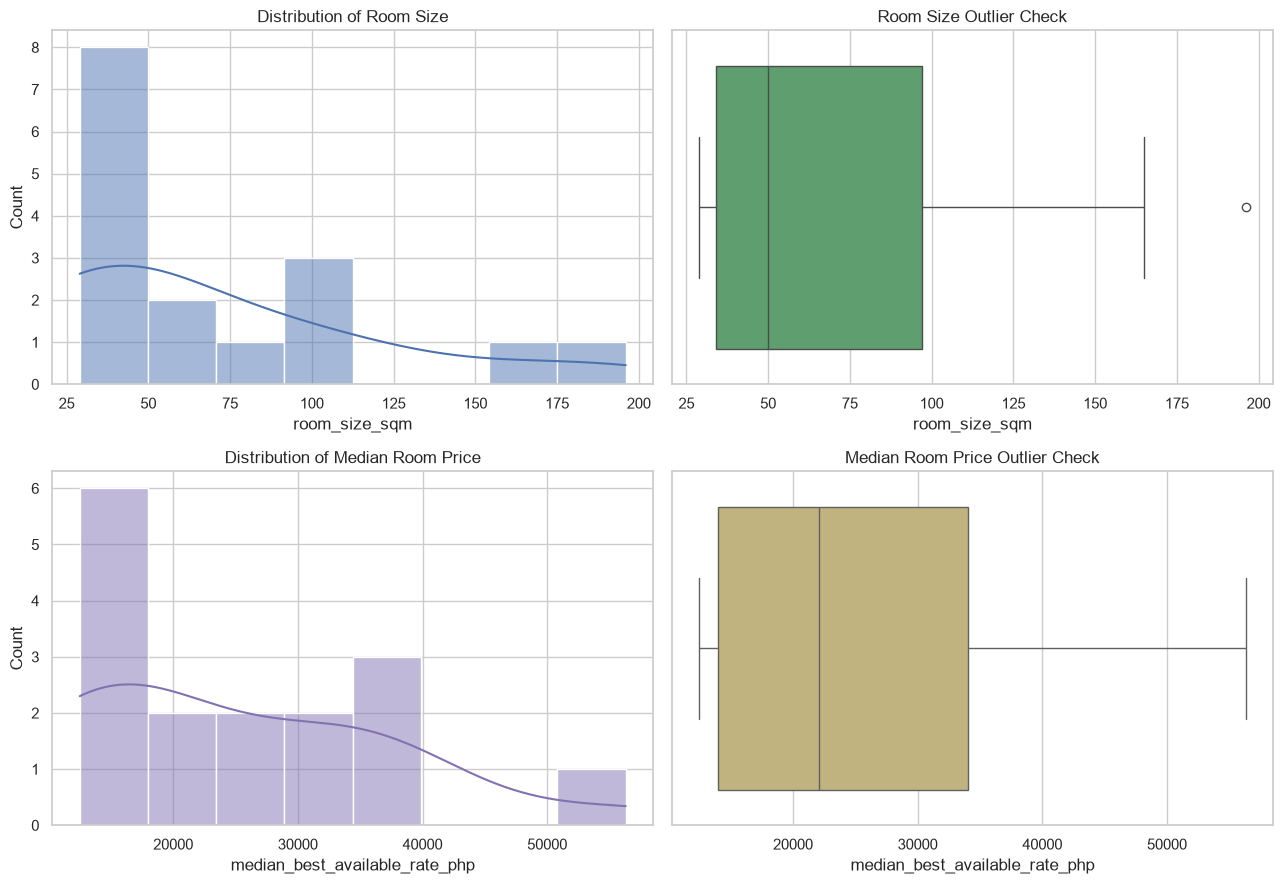

In [31]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9)
)

sns.histplot(
    data=room_size_price_df,
    x="room_size_sqm",
    bins=8,
    kde=True,
    ax=axes[0, 0],
    color="#4C72B0"
)

axes[0, 0].set_title(
    "Distribution of Room Size"
)

sns.boxplot(
    data=room_size_price_df,
    x="room_size_sqm",
    ax=axes[0, 1],
    color="#55A868"
)

axes[0, 1].set_title(
    "Room Size Outlier Check"
)

sns.histplot(
    data=room_size_price_df,
    x="median_best_available_rate_php",
    bins=8,
    kde=True,
    ax=axes[1, 0],
    color="#8172B2"
)

axes[1, 0].set_title(
    "Distribution of Median Room Price"
)

sns.boxplot(
    data=room_size_price_df,
    x="median_best_available_rate_php",
    ax=axes[1, 1],
    color="#CCB974"
)

axes[1, 1].set_title(
    "Median Room Price Outlier Check"
)

plt.tight_layout()
plt.show()

### Room Size and Price Diagnostics

Room size and median Best Available Rate were assessed for outliers and normality.

Room size contained one statistical outlier above the upper boundary of 191.50 square meters. This observation is the 196 square meter Tagaytay Suite Two Bedroom and represents a legitimate premium accommodation.

Median room price contained no interquartile range outliers.

The Shapiro Wilk tests rejected normality for both room size and median price at the 0.05 significance level.

### Statistical Interpretation

The normality assumption required for conventional Pearson correlation inference is not satisfied. The presence of a legitimate room size outlier also makes a rank based method more suitable.

Spearman rank correlation will be used as the primary measure because it assesses whether room price generally increases with room size without requiring normally distributed variables.

### Business Implication

Large suites form a valid part of the hotel portfolio and should not be removed merely because of their size. A rank based analysis preserves these accommodations while reducing their influence on the relationship estimate.

In [32]:
spearman_result = stats.spearmanr(
    room_size_price_df[
        "room_size_sqm"
    ],
    room_size_price_df[
        "median_best_available_rate_php"
    ],
    alternative="greater"
)

spearman_correlation = (
    spearman_result.statistic
)

spearman_p_value = (
    spearman_result.pvalue
)

pearson_result = stats.pearsonr(
    room_size_price_df[
        "room_size_sqm"
    ],
    room_size_price_df[
        "median_best_available_rate_php"
    ],
    alternative="greater"
)

print(
    "Number of rooms:",
    len(
        room_size_price_df
    )
)

print(
    "Spearman correlation:",
    round(
        spearman_correlation,
        4
    )
)

print(
    "Spearman p value:",
    round(
        spearman_p_value,
        6
    )
)

print(
    "Pearson correlation:",
    round(
        pearson_result.statistic,
        4
    )
)

print(
    "Pearson p value:",
    round(
        pearson_result.pvalue,
        6
    )
)

if spearman_p_value < 0.05:
    print(
        "Decision: Reject the null hypothesis"
    )
    print(
        "Conclusion: Larger rooms tend to have higher rates"
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis"
    )
    print(
        "Conclusion: A positive relationship was not established"
    )

Number of rooms: 16
Spearman correlation: 0.9844
Spearman p value: 0.0
Pearson correlation: 0.9486
Pearson p value: 0.0
Decision: Reject the null hypothesis
Conclusion: Larger rooms tend to have higher rates


In [33]:
number_of_rooms = len(
    room_size_price_df
)

degrees_of_freedom = (
    number_of_rooms
    - 2
)

spearman_test_statistic = (
    spearman_correlation
    * np.sqrt(
        degrees_of_freedom
        / (
            1
            - spearman_correlation ** 2
        )
    )
)

lower_critical_value = (
    "Not applicable for this upper tailed test"
)

upper_critical_value = stats.t.ppf(
    0.95,
    degrees_of_freedom
)

print(
    "Degrees of freedom:",
    degrees_of_freedom
)

print(
    "Lower critical value:",
    lower_critical_value
)

print(
    "Upper critical value:",
    round(
        upper_critical_value,
        4
    )
)

print(
    "Test statistic:",
    round(
        spearman_test_statistic,
        4
    )
)

print(
    "Rejection region:",
    (
        "Test statistic is greater than "
        f"{upper_critical_value:.4f}"
    )
)

Degrees of freedom: 14
Lower critical value: Not applicable for this upper tailed test
Upper critical value: 1.7613
Test statistic: 20.9298
Rejection region: Test statistic is greater than 1.7613


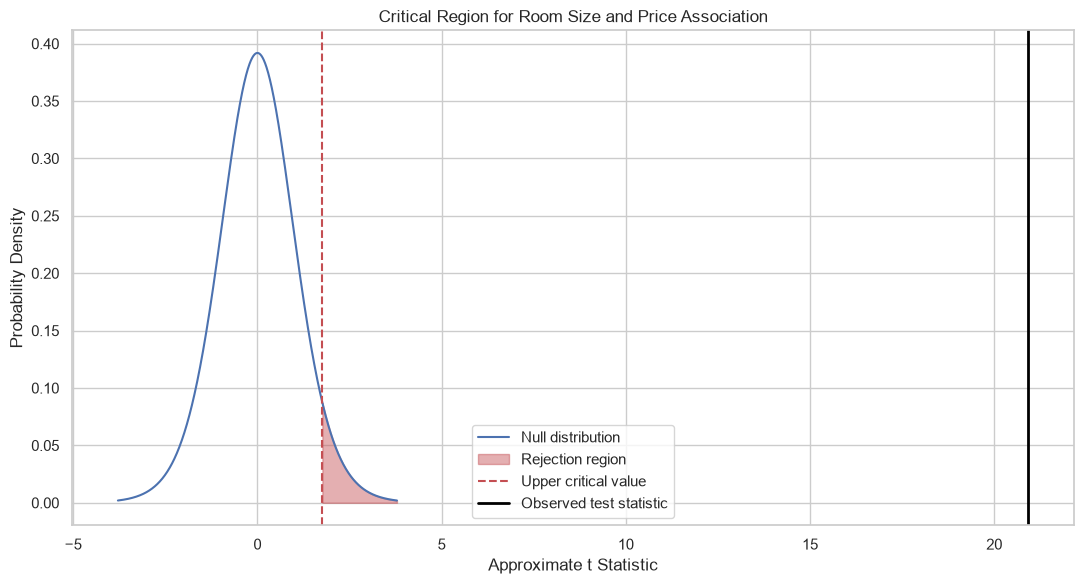

In [34]:
t_values = np.linspace(
    stats.t.ppf(
        0.001,
        degrees_of_freedom
    ),
    stats.t.ppf(
        0.999,
        degrees_of_freedom
    ),
    1000
)

t_density = stats.t.pdf(
    t_values,
    degrees_of_freedom
)

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    t_values,
    t_density,
    color="#4C72B0",
    label="Null distribution"
)

plt.fill_between(
    t_values,
    t_density,
    where=(
        t_values
        >= upper_critical_value
    ),
    color="#C44E52",
    alpha=0.45,
    label="Rejection region"
)

plt.axvline(
    upper_critical_value,
    color="#C44E52",
    linestyle="--",
    label="Upper critical value"
)

plt.axvline(
    spearman_test_statistic,
    color="black",
    linewidth=2,
    label="Observed test statistic"
)

plt.title(
    "Critical Region for Room Size and Price Association"
)

plt.xlabel(
    "Approximate t Statistic"
)

plt.ylabel(
    "Probability Density"
)

plt.legend()
plt.tight_layout()
plt.show()

In [35]:
print(
    "Spearman p value:",
    f"{spearman_p_value:.10e}"
)

print(
    "Pearson p value:",
    f"{pearson_result.pvalue:.10e}"
)

Spearman p value: 2.9014407592e-12
Pearson p value: 1.1061644971e-08


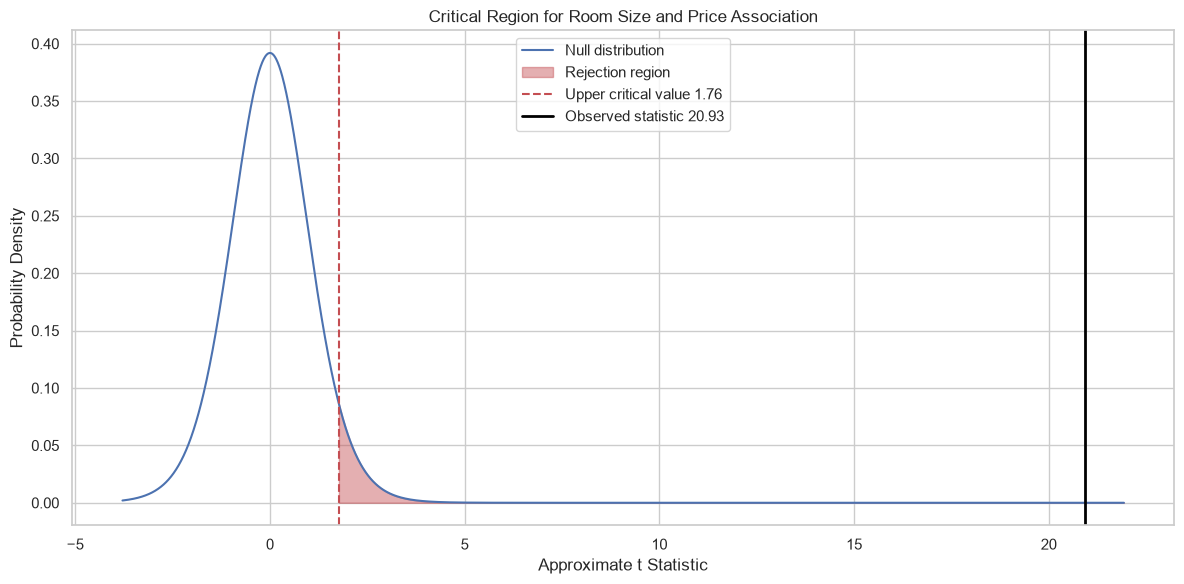

In [36]:
lower_plot_limit = stats.t.ppf(
    0.001,
    degrees_of_freedom
)

upper_plot_limit = (
    spearman_test_statistic
    + 1
)

t_values = np.linspace(
    lower_plot_limit,
    upper_plot_limit,
    2000
)

t_density = stats.t.pdf(
    t_values,
    degrees_of_freedom
)

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    t_values,
    t_density,
    color="#4C72B0",
    label="Null distribution"
)

plt.fill_between(
    t_values,
    t_density,
    where=(
        t_values
        >= upper_critical_value
    ),
    color="#C44E52",
    alpha=0.45,
    label="Rejection region"
)

plt.axvline(
    upper_critical_value,
    color="#C44E52",
    linestyle="--",
    label=(
        "Upper critical value "
        f"{upper_critical_value:.2f}"
    )
)

plt.axvline(
    spearman_test_statistic,
    color="black",
    linewidth=2,
    label=(
        "Observed statistic "
        f"{spearman_test_statistic:.2f}"
    )
)

plt.title(
    "Critical Region for Room Size and Price Association"
)

plt.xlabel(
    "Approximate t Statistic"
)

plt.ylabel(
    "Probability Density"
)

plt.legend()
plt.tight_layout()
plt.show()

### Relationship Between Room Size and Price

Spearman rank correlation produced a coefficient of 0.9844. The approximate test statistic was 20.9298, exceeding the upper critical value of 1.7613.

The null hypothesis was rejected at the 0.05 significance level. The Pearson correlation of 0.9486 provides supporting evidence of a strong linear relationship.

### Statistical Interpretation

There is a statistically significant and exceptionally strong positive association between room size and median Best Available Rate.

The Spearman coefficient of 0.9844 is also the effect size and represents a very large effect. Larger rooms almost consistently occupy higher positions in the hotel price ranking.

The result indicates association rather than causation. Room configuration, number of bedrooms, view, amenities, and room category may also contribute to price.

### Business Implication

Room size is a major component of the hotel pricing structure. Larger suites can support higher rates because they provide more space and may serve families, groups, and premium customers.

However, size alone does not explain every price difference. The two Deluxe Suite configurations with the same floor area have substantially different prices, suggesting that bedroom count and room configuration also create value.

Management can use room size as a pricing benchmark while reviewing accommodations that appear unusually expensive or inexpensive relative to similarly sized rooms.

In [37]:
room_size_price_df[
    "median_price_per_sqm_php"
] = (
    room_size_price_df[
        "median_best_available_rate_php"
    ]
    / room_size_price_df[
        "room_size_sqm"
    ]
)

price_per_sqm_summary_df = (
    room_size_price_df[
        [
            "room_name",
            "room_size_sqm",
            "median_best_available_rate_php",
            "median_price_per_sqm_php"
        ]
    ]
    .sort_values(
        "median_price_per_sqm_php",
        ascending=False
    )
)

display(
    price_per_sqm_summary_df.round(2)
)

print(
    "Average price per square meter:",
    round(
        room_size_price_df[
            "median_price_per_sqm_php"
        ].mean(),
        2
    )
)

print(
    "Median price per square meter:",
    round(
        room_size_price_df[
            "median_price_per_sqm_php"
        ].median(),
        2
    )
)

,room_name,room_size_sqm,median_best_available_rate_php,median_price_per_sqm_php
6,Deluxe Suite Two Bedroom,62.00,"33,639.00",542.56
8,Premier Queen,38.00,"20,550.00",540.79
9,Ridge,37.00,"18,100.00",489.19
2,Deluxe Mountain,29.00,"12,500.00",431.03
10,Superior King,29.00,"12,500.00",431.03
11,Superior Twin,29.00,"12,500.00",431.03
3,Deluxe Queen,34.00,"14,100.00",414.71
7,Deluxe Twin,34.00,"14,100.00",414.71
1,Deluxe King,34.00,"13,500.00",397.06
5,Deluxe Suite One Bedroom,62.00,"23,700.00",382.26


Average price per square meter: 396.84
Median price per square meter: 405.88


In [38]:
price_per_sqm_values = (
    room_size_price_df[
        "median_price_per_sqm_php"
    ]
)

price_per_sqm_q1 = (
    price_per_sqm_values.quantile(
        0.25
    )
)

price_per_sqm_q3 = (
    price_per_sqm_values.quantile(
        0.75
    )
)

price_per_sqm_iqr = (
    price_per_sqm_q3
    - price_per_sqm_q1
)

price_per_sqm_lower_bound = (
    price_per_sqm_q1
    - 1.5 * price_per_sqm_iqr
)

price_per_sqm_upper_bound = (
    price_per_sqm_q3
    + 1.5 * price_per_sqm_iqr
)

room_size_price_df[
    "price_per_sqm_outlier"
] = (
    price_per_sqm_values
    < price_per_sqm_lower_bound
) | (
    price_per_sqm_values
    > price_per_sqm_upper_bound
)

print(
    "Lower boundary:",
    round(
        price_per_sqm_lower_bound,
        2
    )
)

print(
    "Upper boundary:",
    round(
        price_per_sqm_upper_bound,
        2
    )
)

print(
    "Outliers:",
    room_size_price_df[
        "price_per_sqm_outlier"
    ].sum()
)

display(
    room_size_price_df.loc[
        room_size_price_df[
            "price_per_sqm_outlier"
        ],
        [
            "room_name",
            "room_size_sqm",
            "median_best_available_rate_php",
            "median_price_per_sqm_php"
        ]
    ].round(2)
)

Lower boundary: 192.12
Upper boundary: 574.38
Outliers: 0


,room_name,room_size_sqm,median_best_available_rate_php,median_price_per_sqm_php


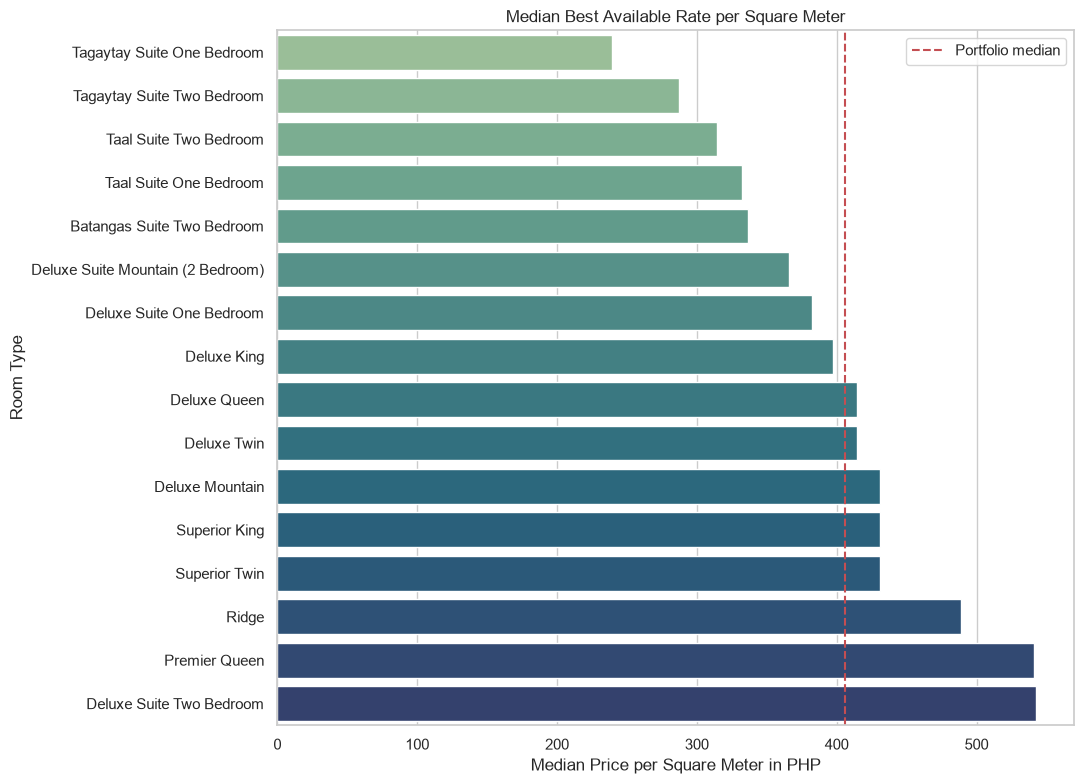

In [39]:
price_per_sqm_plot_df = (
    room_size_price_df.sort_values(
        "median_price_per_sqm_php"
    )
)

plt.figure(
    figsize=(11, 8)
)

sns.barplot(
    data=price_per_sqm_plot_df,
    x="median_price_per_sqm_php",
    y="room_name",
    hue="room_name",
    legend=False,
    palette="crest"
)

plt.axvline(
    price_per_sqm_values.median(),
    color="#C44E52",
    linestyle="--",
    label="Portfolio median"
)

plt.title(
    "Median Best Available Rate per Square Meter"
)

plt.xlabel(
    "Median Price per Square Meter in PHP"
)

plt.ylabel(
    "Room Type"
)

plt.legend()
plt.tight_layout()
plt.show()

### Room Price per Square Meter

The median price per square meter across the room portfolio is PHP 405.88. Values range from PHP 239.41 to PHP 542.56.

The Deluxe Suite Two Bedroom has the highest value at PHP 542.56 per square meter, closely followed by the Premier Queen at PHP 540.79. The Tagaytay Suite One Bedroom has the lowest value at PHP 239.41 per square meter.

No room type falls outside the interquartile range outlier boundaries of PHP 192.12 and PHP 574.38 per square meter.

### Statistical Interpretation

Although room prices increase strongly with size, price does not increase proportionally for every additional square meter. Larger suites generally have lower prices per square meter, while selected smaller rooms and configurations command higher rates relative to their size.

The absence of outliers indicates that all room types remain within the portfolio's expected price efficiency range.

### Business Implication

The Tagaytay suites offer the greatest physical space relative to price and can be positioned as strong value options for families, groups, or longer stays.

The Deluxe Suite Two Bedroom and Premier Queen command the strongest price per square meter. Management should ensure that their configuration, location, view, amenities, and service benefits clearly support this premium.

Price per square meter should be used as a portfolio comparison measure rather than a complete judgment of room value.

In [40]:
meeting_rates_df = eda_dataframes[
    "meeting_rates"
].copy()

meeting_rates_df[
    "price_per_hour_php"
] = (
    meeting_rates_df[
        "price_php"
    ]
    / meeting_rates_df[
        "duration_hours"
    ]
)

meeting_rate_summary_df = (
    meeting_rates_df.groupby(
        [
            "client_sector",
            "package_duration"
        ]
    )
    .agg(
        offers=(
            "price_php",
            "count"
        ),
        average_price_php=(
            "price_php",
            "mean"
        ),
        median_price_php=(
            "price_php",
            "median"
        ),
        minimum_price_php=(
            "price_php",
            "min"
        ),
        maximum_price_php=(
            "price_php",
            "max"
        ),
        average_price_per_hour_php=(
            "price_per_hour_php",
            "mean"
        )
    )
    .reset_index()
)

display(
    meeting_rate_summary_df.round(2)
)

print(
    "Meeting rate records:",
    len(
        meeting_rates_df
    )
)

print(
    "Client sectors:",
    meeting_rates_df[
        "client_sector"
    ].nunique()
)

print(
    "Participant ranges:",
    meeting_rates_df[
        "participant_range"
    ].nunique()
)

print(
    "Package durations:",
    meeting_rates_df[
        "package_duration"
    ].nunique()
)

,client_sector,package_duration,offers,average_price_php,median_price_php,minimum_price_php,maximum_price_php,average_price_per_hour_php
0,Corporate,Full Board,3,"4,850.00","4,950.00",4400,5200,404.17
1,Corporate,Half Day,3,"2,316.67","2,350.00",2100,2500,579.17
2,Corporate,Whole Day,3,"3,000.00","3,050.00",2700,3250,375.00
3,Government,Full Board,3,"4,783.33","4,800.00",4650,4900,398.61
4,Government,Half Day,3,"2,283.33","2,300.00",2200,2350,570.83
5,Government,Whole Day,3,"2,850.00","2,850.00",2800,2900,356.25


Meeting rate records: 18
Client sectors: 2
Participant ranges: 3
Package durations: 3


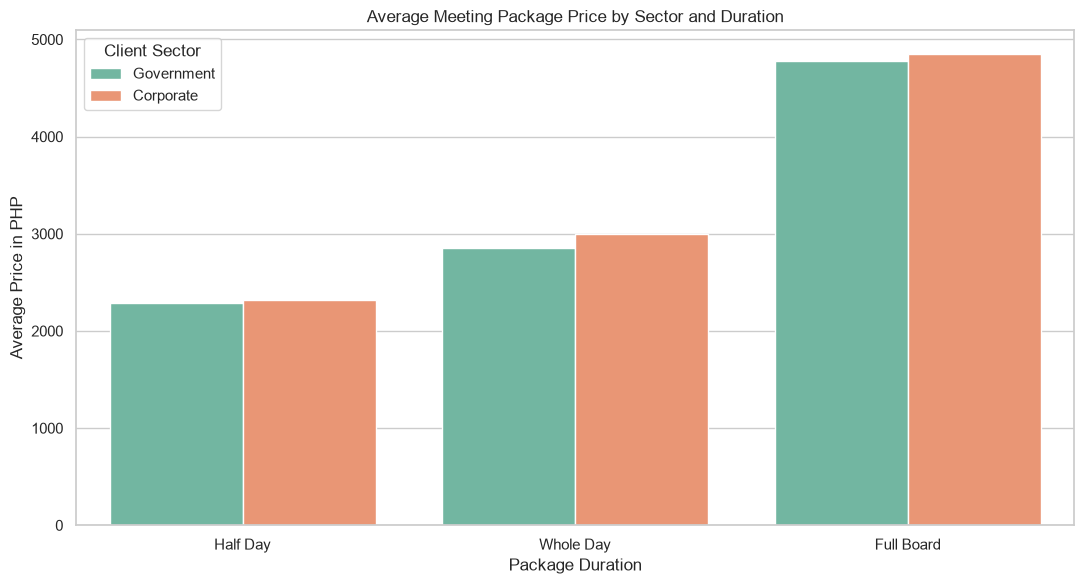

In [41]:
plt.figure(
    figsize=(11, 6)
)

sns.barplot(
    data=meeting_rates_df,
    x="package_duration",
    y="price_php",
    hue="client_sector",
    order=[
        "Half Day",
        "Whole Day",
        "Full Board"
    ],
    errorbar=None,
    palette="Set2"
)

plt.title(
    "Average Meeting Package Price by Sector and Duration"
)

plt.xlabel(
    "Package Duration"
)

plt.ylabel(
    "Average Price in PHP"
)

plt.legend(
    title="Client Sector"
)

plt.tight_layout()
plt.show()

## Meeting Package Pricing

The meeting rate dataset contains 18 offers across two client sectors, three participant ranges, and three package durations.

Corporate average prices are slightly higher than government prices for Half Day, Whole Day, and Full Board packages.

Half Day packages have the highest average hourly prices. Government Half Day packages average PHP 570.83 per hour, while Corporate Half Day packages average PHP 579.17 per hour.

Whole Day packages provide the lowest average hourly cost at PHP 356.25 for government clients and PHP 375 for corporate clients.

### Statistical Interpretation

Package prices increase with duration, but the effective hourly price does not follow the same pattern. Longer packages distribute the total cost over more service hours.

The sector averages suggest higher corporate prices, but each average is based on only three participant ranges. A matched comparison is required before determining whether corporate prices are consistently higher.

### Business Implication

Whole Day packages provide the lowest hourly cost and may be positioned as the strongest value option for clients requiring extended meeting time.

Half Day packages generate more revenue per service hour but may appeal to customers with shorter schedules. Full Board packages can justify their higher total prices through meal coverage and longer venue use.

In [42]:
meeting_sector_pivot_df = (
    meeting_rates_df.pivot_table(
        index=[
            "participant_range",
            "package_duration",
            "duration_hours"
        ],
        columns="client_sector",
        values="price_php"
    )
    .reset_index()
)

meeting_sector_pivot_df[
    "corporate_price_difference_php"
] = (
    meeting_sector_pivot_df[
        "Corporate"
    ]
    - meeting_sector_pivot_df[
        "Government"
    ]
)

meeting_sector_pivot_df[
    "corporate_price_difference_percent"
] = (
    meeting_sector_pivot_df[
        "corporate_price_difference_php"
    ]
    / meeting_sector_pivot_df[
        "Government"
    ]
    * 100
)

duration_order = {
    "Half Day": 1,
    "Whole Day": 2,
    "Full Board": 3
}

meeting_sector_pivot_df[
    "duration_order"
] = (
    meeting_sector_pivot_df[
        "package_duration"
    ].map(
        duration_order
    )
)

meeting_sector_pivot_df = (
    meeting_sector_pivot_df.sort_values(
        [
            "participant_range",
            "duration_order"
        ]
    )
    .drop(
        columns="duration_order"
    )
)

display(
    meeting_sector_pivot_df.round(2)
)

print(
    "Matched package pairs:",
    len(
        meeting_sector_pivot_df
    )
)

print(
    "Average corporate difference:",
    round(
        meeting_sector_pivot_df[
            "corporate_price_difference_php"
        ].mean(),
        2
    )
)

print(
    "Median corporate difference:",
    round(
        meeting_sector_pivot_df[
            "corporate_price_difference_php"
        ].median(),
        2
    )
)

print(
    "Corporate price is higher:",
    (
        meeting_sector_pivot_df[
            "corporate_price_difference_php"
        ] > 0
    ).sum()
)

print(
    "Government price is higher:",
    (
        meeting_sector_pivot_df[
            "corporate_price_difference_php"
        ] < 0
    ).sum()
)

client_sector,participant_range,package_duration,duration_hours,Corporate,Government,corporate_price_difference_php,corporate_price_difference_percent
1,15 to 29,Half Day,4,"2,100.00","2,300.00",-200.00,-8.70
2,15 to 29,Whole Day,8,"2,700.00","2,800.00",-100.00,-3.57
0,15 to 29,Full Board,12,"4,400.00","4,800.00",-400.00,-8.33
4,30 to 60,Half Day,4,"2,350.00","2,200.00",150.00,6.82
5,30 to 60,Whole Day,8,"3,050.00","2,850.00",200.00,7.02
3,30 to 60,Full Board,12,"4,950.00","4,650.00",300.00,6.45
7,61 and above,Half Day,4,"2,500.00","2,350.00",150.00,6.38
8,61 and above,Whole Day,8,"3,250.00","2,900.00",350.00,12.07
6,61 and above,Full Board,12,"5,200.00","4,900.00",300.00,6.12


Matched package pairs: 9
Average corporate difference: 83.33
Median corporate difference: 150.0
Corporate price is higher: 6
Government price is higher: 3


### Matched Corporate and Government Rates

Corporate rates were higher in 6 of 9 matched package configurations. Government rates were higher in the remaining three configurations.

The average Corporate price difference was PHP 83.33, while the median difference was PHP 150.

### Statistical Interpretation

The direction of the sector difference is not consistent across all matched packages. Although Corporate prices are more frequently higher, three package configurations have higher Government prices.

The relatively small average difference suggests that client sector alone may not be a strong pricing determinant. Participant range and duration should also be considered.

### Business Implication

Taal Vista Hotel does not appear to apply one uniform premium to all Corporate packages. Pricing may instead reflect the combination of group size, service style, and duration.

Management should evaluate sector pricing at the individual package level rather than relying only on overall Corporate and Government averages.

In [43]:
meeting_price_differences = (
    meeting_sector_pivot_df[
        "corporate_price_difference_php"
    ]
)

meeting_difference_q1 = (
    meeting_price_differences.quantile(
        0.25
    )
)

meeting_difference_q3 = (
    meeting_price_differences.quantile(
        0.75
    )
)

meeting_difference_iqr = (
    meeting_difference_q3
    - meeting_difference_q1
)

meeting_difference_lower_bound = (
    meeting_difference_q1
    - 1.5 * meeting_difference_iqr
)

meeting_difference_upper_bound = (
    meeting_difference_q3
    + 1.5 * meeting_difference_iqr
)

meeting_difference_outliers = (
    (
        meeting_price_differences
        < meeting_difference_lower_bound
    )
    | (
        meeting_price_differences
        > meeting_difference_upper_bound
    )
)

meeting_shapiro_statistic, meeting_shapiro_p_value = (
    stats.shapiro(
        meeting_price_differences
    )
)

print(
    "First quartile:",
    meeting_difference_q1
)

print(
    "Third quartile:",
    meeting_difference_q3
)

print(
    "Interquartile range:",
    meeting_difference_iqr
)

print(
    "Lower boundary:",
    meeting_difference_lower_bound
)

print(
    "Upper boundary:",
    meeting_difference_upper_bound
)

print(
    "Outliers:",
    meeting_difference_outliers.sum()
)

print(
    "Shapiro Wilk statistic:",
    round(
        meeting_shapiro_statistic,
        4
    )
)

print(
    "Shapiro Wilk p value:",
    round(
        meeting_shapiro_p_value,
        4
    )
)

if meeting_shapiro_p_value < 0.05:
    print(
        "Decision: Reject the null hypothesis"
    )
    print(
        "Conclusion: The differences are not normally distributed"
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis"
    )
    print(
        "Conclusion: Normality was not rejected"
    )

First quartile: -100.0
Third quartile: 300.0
Interquartile range: 400.0
Lower boundary: -700.0
Upper boundary: 900.0
Outliers: 0
Shapiro Wilk statistic: 0.8839
Shapiro Wilk p value: 0.1724
Decision: Fail to reject the null hypothesis
Conclusion: Normality was not rejected


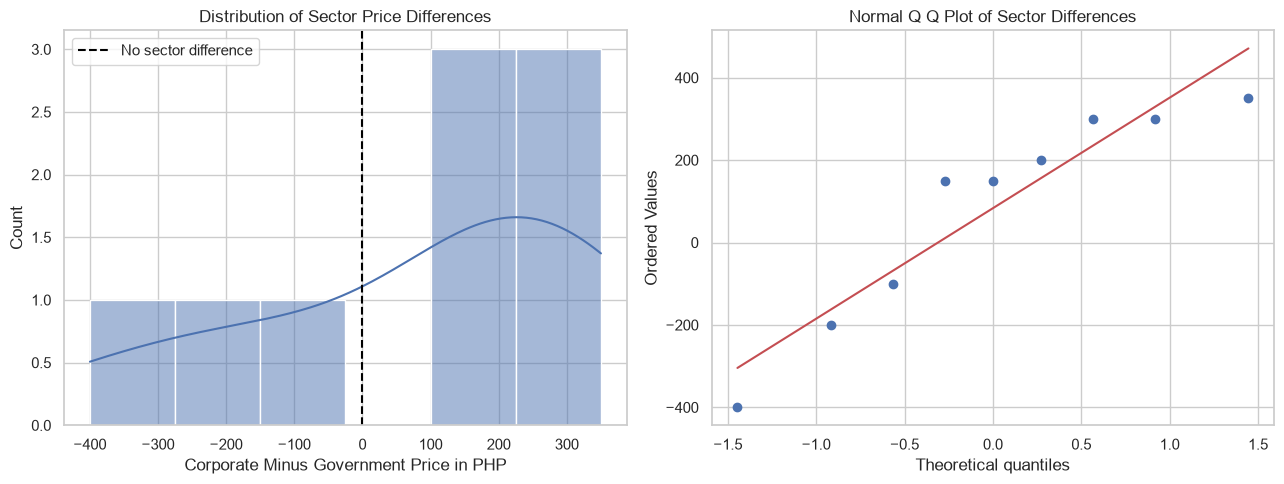

In [44]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

sns.histplot(
    meeting_price_differences,
    bins=6,
    kde=True,
    ax=axes[0],
    color="#4C72B0"
)

axes[0].axvline(
    0,
    color="black",
    linestyle="--",
    label="No sector difference"
)

axes[0].set_title(
    "Distribution of Sector Price Differences"
)

axes[0].set_xlabel(
    "Corporate Minus Government Price in PHP"
)

axes[0].legend()

stats.probplot(
    meeting_price_differences,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title(
    "Normal Q Q Plot of Sector Differences"
)

plt.tight_layout()
plt.show()

In [45]:
meeting_t_result = stats.ttest_rel(
    meeting_sector_pivot_df[
        "Corporate"
    ],
    meeting_sector_pivot_df[
        "Government"
    ],
    alternative="two-sided"
)

meeting_t_statistic = (
    meeting_t_result.statistic
)

meeting_t_p_value = (
    meeting_t_result.pvalue
)

meeting_sample_size = len(
    meeting_price_differences
)

meeting_degrees_of_freedom = (
    meeting_sample_size
    - 1
)

meeting_mean_difference = (
    meeting_price_differences.mean()
)

meeting_standard_error = (
    stats.sem(
        meeting_price_differences
    )
)

meeting_lower_critical_value = stats.t.ppf(
    0.025,
    meeting_degrees_of_freedom
)

meeting_upper_critical_value = stats.t.ppf(
    0.975,
    meeting_degrees_of_freedom
)

meeting_confidence_interval = stats.t.interval(
    0.95,
    meeting_degrees_of_freedom,
    loc=meeting_mean_difference,
    scale=meeting_standard_error
)

meeting_cohens_d = (
    meeting_mean_difference
    / meeting_price_differences.std(
        ddof=1
    )
)

print(
    "Mean Corporate difference:",
    round(
        meeting_mean_difference,
        2
    )
)

print(
    "Test statistic:",
    round(
        meeting_t_statistic,
        4
    )
)

print(
    "P value:",
    round(
        meeting_t_p_value,
        4
    )
)

print(
    "Degrees of freedom:",
    meeting_degrees_of_freedom
)

print(
    "Lower critical value:",
    round(
        meeting_lower_critical_value,
        4
    )
)

print(
    "Upper critical value:",
    round(
        meeting_upper_critical_value,
        4
    )
)

print(
    "Confidence interval:",
    tuple(
        round(
            value,
            2
        )
        for value
        in meeting_confidence_interval
    )
)

print(
    "Paired Cohen d:",
    round(
        meeting_cohens_d,
        4
    )
)

if meeting_t_p_value < 0.05:
    print(
        "Decision: Reject the null hypothesis"
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis"
    )

Mean Corporate difference: 83.33
Test statistic: 0.9667
P value: 0.362
Degrees of freedom: 8
Lower critical value: -2.306
Upper critical value: 2.306
Confidence interval: (np.float64(-115.45), np.float64(282.11))
Paired Cohen d: 0.3222
Decision: Fail to reject the null hypothesis


In [46]:
absolute_meeting_cohens_d = abs(
    meeting_cohens_d
)

if absolute_meeting_cohens_d < 0.20:
    meeting_effect_interpretation = (
        "Negligible"
    )
elif absolute_meeting_cohens_d < 0.50:
    meeting_effect_interpretation = (
        "Small"
    )
elif absolute_meeting_cohens_d < 0.80:
    meeting_effect_interpretation = (
        "Medium"
    )
else:
    meeting_effect_interpretation = (
        "Large"
    )

print(
    "Effect size interpretation:",
    meeting_effect_interpretation
)

Effect size interpretation: Small


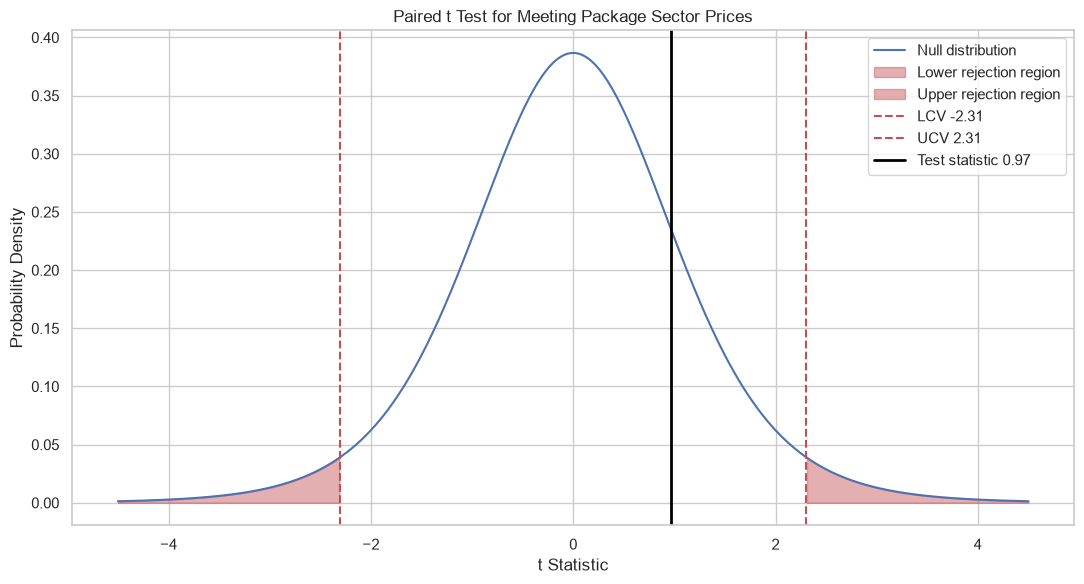

In [47]:
meeting_t_values = np.linspace(
    stats.t.ppf(
        0.001,
        meeting_degrees_of_freedom
    ),
    stats.t.ppf(
        0.999,
        meeting_degrees_of_freedom
    ),
    1000
)

meeting_t_density = stats.t.pdf(
    meeting_t_values,
    meeting_degrees_of_freedom
)

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    meeting_t_values,
    meeting_t_density,
    color="#4C72B0",
    label="Null distribution"
)

plt.fill_between(
    meeting_t_values,
    meeting_t_density,
    where=(
        meeting_t_values
        <= meeting_lower_critical_value
    ),
    color="#C44E52",
    alpha=0.45,
    label="Lower rejection region"
)

plt.fill_between(
    meeting_t_values,
    meeting_t_density,
    where=(
        meeting_t_values
        >= meeting_upper_critical_value
    ),
    color="#C44E52",
    alpha=0.45,
    label="Upper rejection region"
)

plt.axvline(
    meeting_lower_critical_value,
    color="#C44E52",
    linestyle="--",
    label=(
        "LCV "
        f"{meeting_lower_critical_value:.2f}"
    )
)

plt.axvline(
    meeting_upper_critical_value,
    color="#C44E52",
    linestyle="--",
    label=(
        "UCV "
        f"{meeting_upper_critical_value:.2f}"
    )
)

plt.axvline(
    meeting_t_statistic,
    color="black",
    linewidth=2,
    label=(
        "Test statistic "
        f"{meeting_t_statistic:.2f}"
    )
)

plt.title(
    "Paired t Test for Meeting Package Sector Prices"
)

plt.xlabel(
    "t Statistic"
)

plt.ylabel(
    "Probability Density"
)

plt.legend()
plt.tight_layout()
plt.show()

### Corporate and Government Meeting Price Test

The paired t test compared nine Corporate and Government package configurations matched by participant range and duration.

The mean Corporate price was PHP 83.33 higher. The test statistic was 0.9667, which fell between the lower critical value of negative 2.306 and the upper critical value of 2.306.

The p value was 0.362, and the 95 percent confidence interval for the mean difference ranged from negative PHP 115.45 to PHP 282.11. The null hypothesis was not rejected.

The paired Cohen d was 0.3222, indicating a small effect.

### Statistical Interpretation

There is insufficient evidence that Corporate and Government package prices differ on average.

The confidence interval includes zero and allows for either a small Government premium or a modest Corporate premium. The current sample therefore does not support a consistent sector pricing difference.

### Business Implication

Client sector alone does not appear to justify separate general pricing expectations. Duration, participant range, meal inclusions, and service style may be more useful for explaining package prices.

Management should evaluate packages at the configuration level instead of assuming that all Corporate rates are higher. The result is based on only nine matched packages and should not be interpreted as proof that the two sectors always receive identical prices.

The brochure does not explicitly state the rate basis. Revenue projections should not treat these amounts as per person prices without confirmation from the hotel.

In [48]:
event_venues_df = eda_dataframes[
    "event_venues"
].copy()

event_venues_df[
    "banquet_guests_per_sqm"
] = (
    event_venues_df[
        "banquet_capacity"
    ]
    / event_venues_df[
        "floor_area_sqm"
    ]
)

event_venues_df[
    "cocktail_guests_per_sqm"
] = (
    event_venues_df[
        "cocktail_capacity"
    ]
    / event_venues_df[
        "floor_area_sqm"
    ]
)

event_venue_overview_df = (
    event_venues_df.groupby(
        "hotel_wing"
    )
    .agg(
        venues=(
            "venue",
            "count"
        ),
        total_floor_area_sqm=(
            "floor_area_sqm",
            "sum"
        ),
        average_floor_area_sqm=(
            "floor_area_sqm",
            "mean"
        ),
        maximum_theater_capacity=(
            "theater_capacity",
            "max"
        ),
        maximum_banquet_capacity=(
            "banquet_capacity",
            "max"
        ),
        maximum_cocktail_capacity=(
            "cocktail_capacity",
            "max"
        )
    )
    .reset_index()
)

display(
    event_venue_overview_df.round(2)
)

print(
    "Event venues:",
    len(
        event_venues_df
    )
)

print(
    "Venues with unpublished banquet capacity:",
    event_venues_df[
        "banquet_capacity"
    ].isna().sum()
)

print(
    "Venues with unpublished cocktail capacity:",
    event_venues_df[
        "cocktail_capacity"
    ].isna().sum()
)

,hotel_wing,venues,total_floor_area_sqm,average_floor_area_sqm,maximum_theater_capacity,maximum_banquet_capacity,maximum_cocktail_capacity
0,Lake Wing,15,"4,952.63",330.18,"1,000.00",800.00,"1,400.00"
1,Mountain Wing,9,"1,092.08",121.34,420.00,250.00,550.00


Event venues: 24
Venues with unpublished banquet capacity: 2
Venues with unpublished cocktail capacity: 1


In [49]:
display(
    event_venues_df[
        [
            "venue",
            "hotel_wing",
            "floor_area_sqm",
            "theater_capacity",
            "banquet_capacity",
            "cocktail_capacity"
        ]
    ]
    .sort_values(
        "floor_area_sqm",
        ascending=False
    )
    .head(10)
)

,venue,hotel_wing,floor_area_sqm,theater_capacity,banquet_capacity,cocktail_capacity
9,GRAND BALLROOM,Lake Wing,"1,292.10","1,000.00",800.00,"1,400.00"
21,VIEWDECK,Lake Wing,947.10,600.00,500.00,860.00
18,SAMPAGUITA BALLROOM,Mountain Wing,575.40,420.00,250.00,550.00
15,PREMIER GARDEN,Lake Wing,448.00,300.00,200.00,430.00
0,BALLROOM 1,Lake Wing,430.70,350.00,220.00,450.00
2,BALLROOM 3,Lake Wing,430.70,350.00,220.00,450.00
1,BALLROOM 2,Lake Wing,430.70,350.00,220.00,450.00
7,COVERED TERRACE,Lake Wing,363.84,300.00,220.00,450.00
14,MID GARDEN,Lake Wing,216.75,120.00,60.00,120.00
13,LOWER LEVEL FOYER,Mountain Wing,121.00,100.00,60.00,120.00


In [50]:
print(
    "Highest published banquet capacity per square meter:"
)

display(
    event_venues_df[
        [
            "venue",
            "hotel_wing",
            "floor_area_sqm",
            "banquet_capacity",
            "banquet_guests_per_sqm"
        ]
    ]
    .dropna()
    .sort_values(
        "banquet_guests_per_sqm",
        ascending=False
    )
    .head(10)
    .round(2)
)

print(
    "Highest published cocktail capacity per square meter:"
)

display(
    event_venues_df[
        [
            "venue",
            "hotel_wing",
            "floor_area_sqm",
            "cocktail_capacity",
            "cocktail_guests_per_sqm"
        ]
    ]
    .dropna()
    .sort_values(
        "cocktail_guests_per_sqm",
        ascending=False
    )
    .head(10)
    .round(2)
)

Highest published banquet capacity per square meter:


,venue,hotel_wing,floor_area_sqm,banquet_capacity,banquet_guests_per_sqm
9,GRAND BALLROOM,Lake Wing,"1,292.10",800.00,0.62
7,COVERED TERRACE,Lake Wing,363.84,220.00,0.60
23,WALING-WALING 2,Mountain Wing,52.54,30.00,0.57
22,WALING-WALING 1,Mountain Wing,53.96,30.00,0.56
21,VIEWDECK,Lake Wing,947.10,500.00,0.53
8,DAHLIA,Lake Wing,57.80,30.00,0.52
3,CAMIA,Lake Wing,57.80,30.00,0.52
20,SANTAN,Lake Wing,58.10,30.00,0.52
12,LILY,Lake Wing,58.10,30.00,0.52
1,BALLROOM 2,Lake Wing,430.70,220.00,0.51


Highest published cocktail capacity per square meter:


,venue,hotel_wing,floor_area_sqm,cocktail_capacity,cocktail_guests_per_sqm
7,COVERED TERRACE,Lake Wing,363.84,450.00,1.24
17,ROSAL 2,Mountain Wing,60.42,70.00,1.16
23,WALING-WALING 2,Mountain Wing,52.54,60.00,1.14
22,WALING-WALING 1,Mountain Wing,53.96,60.00,1.11
9,GRAND BALLROOM,Lake Wing,"1,292.10","1,400.00",1.08
1,BALLROOM 2,Lake Wing,430.70,450.00,1.04
0,BALLROOM 1,Lake Wing,430.70,450.00,1.04
2,BALLROOM 3,Lake Wing,430.70,450.00,1.04
16,ROSAL 1,Mountain Wing,76.72,80.00,1.04
8,DAHLIA,Lake Wing,57.80,60.00,1.04


## Event Venue Capacity

The Grand Ballroom is the largest venue, with 1,292.10 square meters of floor area. It has the highest published capacities for theater, banquet, and cocktail arrangements.

The Viewdeck is the second largest venue at 947.10 square meters, followed by the Sampaguita Ballroom at 575.40 square meters.

The Grand Ballroom has the highest published banquet density at 0.62 guests per square meter. The Covered Terrace has the highest cocktail density at 1.24 guests per square meter.

### Statistical Interpretation

Venue size and maximum capacity are related, but the highest capacity density does not always belong to the largest venue. Layout type and available floor configuration influence how efficiently a venue can accommodate guests.

The density values use the maximum published capacities selected from the official desktop and mobile tables. They represent planning indicators rather than independently verified safety limits.

### Business Implication

The Grand Ballroom is the strongest option for large events and high capacity banquets. The Covered Terrace provides the most space efficient cocktail configuration and may be attractive for receptions requiring high guest capacity without using the largest ballroom.

Smaller venues such as Waling Waling 1 and Waling Waling 2 also provide relatively efficient layouts for intimate events.

Final venue selection should consider guest comfort, event design, furniture, technical equipment, service space, and current hotel safety requirements. Published maximum capacity should always be confirmed directly with the hotel.

In [51]:
venue_capacity_columns = [
    "theater_capacity",
    "banquet_capacity",
    "cocktail_capacity"
]

venue_correlation_records = []

for capacity_column in venue_capacity_columns:
    correlation_data = (
        event_venues_df[
            [
                "floor_area_sqm",
                capacity_column
            ]
        ]
        .dropna()
    )

    spearman_result = stats.spearmanr(
        correlation_data[
            "floor_area_sqm"
        ],
        correlation_data[
            capacity_column
        ],
        alternative="greater"
    )

    pearson_result = stats.pearsonr(
        correlation_data[
            "floor_area_sqm"
        ],
        correlation_data[
            capacity_column
        ],
        alternative="greater"
    )

    venue_correlation_records.append({
        "capacity_type": capacity_column,
        "venues_included": len(
            correlation_data
        ),
        "spearman_correlation": (
            spearman_result.statistic
        ),
        "spearman_p_value": (
            spearman_result.pvalue
        ),
        "pearson_correlation": (
            pearson_result.statistic
        ),
        "pearson_p_value": (
            pearson_result.pvalue
        )
    })

venue_correlation_df = pd.DataFrame(
    venue_correlation_records
)

display(
    venue_correlation_df.round(6)
)

,capacity_type,venues_included,spearman_correlation,spearman_p_value,pearson_correlation,pearson_p_value
0,theater_capacity,22,0.94,0.00,0.99,0.00
1,banquet_capacity,22,0.91,0.00,0.99,0.00
2,cocktail_capacity,23,0.94,0.00,0.99,0.00


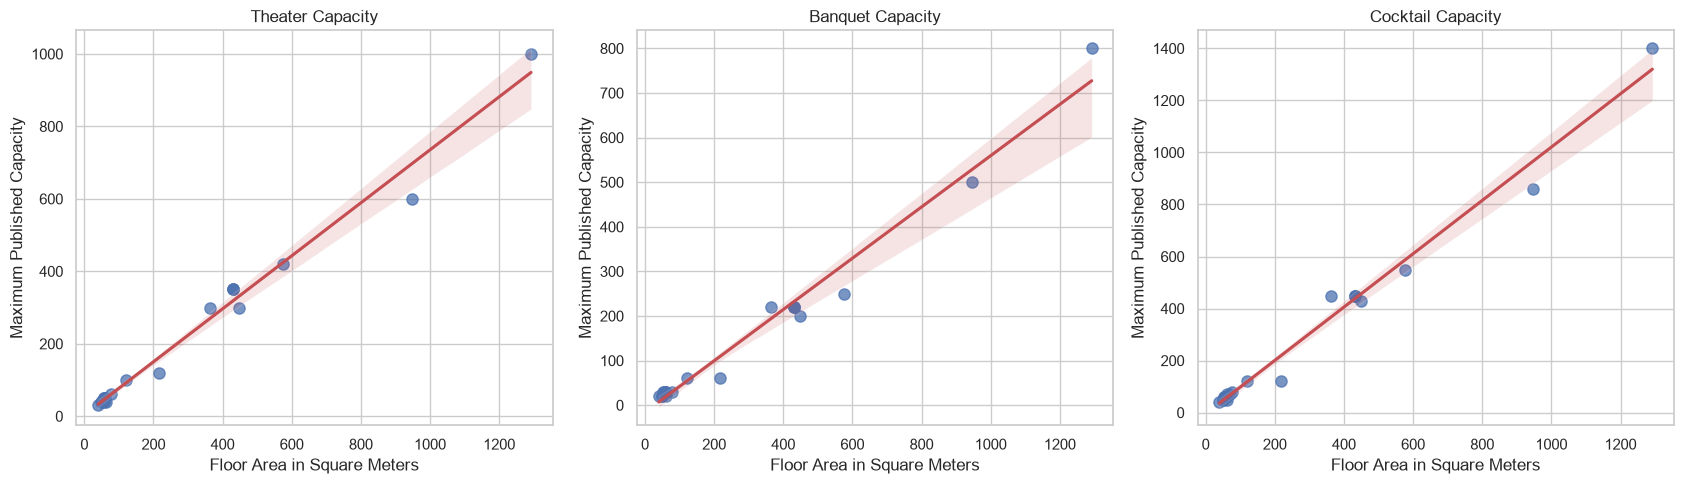

In [52]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

for axis, capacity_column in zip(
    axes,
    venue_capacity_columns
):
    sns.regplot(
        data=event_venues_df,
        x="floor_area_sqm",
        y=capacity_column,
        ax=axis,
        scatter_kws={
            "s": 65,
            "alpha": 0.75
        },
        line_kws={
            "color": "#C44E52"
        }
    )

    axis.set_title(
        capacity_column.replace(
            "_",
            " "
        ).title()
    )

    axis.set_xlabel(
        "Floor Area in Square Meters"
    )

    axis.set_ylabel(
        "Maximum Published Capacity"
    )

plt.tight_layout()
plt.show()

### Venue Size and Published Capacity

Venue floor area has a strong positive relationship with theater, banquet, and cocktail capacity.

Spearman correlations range from 0.91 to 0.94. Pearson correlations are approximately 0.99 for all three arrangements.

### Statistical Interpretation

The results show that larger venues generally support higher published maximum capacities. The slightly lower Spearman coefficients indicate that the ranking is not perfectly consistent because layout efficiency varies among venues.

Pearson correlations are exceptionally high because maximum capacity increases almost proportionally with floor area. These results describe association and do not prove that size alone determines capacity.

### Business Implication

Floor area provides a strong initial basis for estimating the scale of events that a venue can accommodate. However, layout type remains important because venues with similar floor areas may differ in capacity efficiency.

Sales teams can use floor area and published capacity together when shortlisting venues, while final recommendations should account for event format, furniture, production equipment, service aisles, and guest comfort.

In [53]:
family_alpha = 0.05

number_of_capacity_tests = len(
    venue_correlation_df
)

adjusted_alpha = (
    family_alpha
    / number_of_capacity_tests
)

venue_test_records = []

for _, correlation_record in (
    venue_correlation_df.iterrows()
):
    sample_size = int(
        correlation_record[
            "venues_included"
        ]
    )

    degrees_of_freedom = (
        sample_size
        - 2
    )

    correlation_value = (
        correlation_record[
            "spearman_correlation"
        ]
    )

    test_statistic = (
        correlation_value
        * np.sqrt(
            degrees_of_freedom
            / (
                1
                - correlation_value ** 2
            )
        )
    )

    upper_critical_value = stats.t.ppf(
        1 - adjusted_alpha,
        degrees_of_freedom
    )

    venue_test_records.append({
        "capacity_type": (
            correlation_record[
                "capacity_type"
            ]
        ),
        "sample_size": sample_size,
        "degrees_of_freedom": (
            degrees_of_freedom
        ),
        "spearman_correlation": (
            correlation_value
        ),
        "p_value": (
            correlation_record[
                "spearman_p_value"
            ]
        ),
        "adjusted_alpha": (
            adjusted_alpha
        ),
        "lower_critical_value": (
            np.nan
        ),
        "upper_critical_value": (
            upper_critical_value
        ),
        "test_statistic": (
            test_statistic
        ),
        "decision": (
            "Reject the null hypothesis"
            if correlation_record[
                "spearman_p_value"
            ] < adjusted_alpha
            else "Fail to reject the null hypothesis"
        )
    })

venue_test_results_df = pd.DataFrame(
    venue_test_records
)

display(
    venue_test_results_df.round(6)
)

print(
    "Lower critical value:",
    "Not applicable for upper tailed tests"
)

print(
    "Bonferroni adjusted alpha:",
    round(
        adjusted_alpha,
        6
    )
)

,capacity_type,sample_size,degrees_of_freedom,spearman_correlation,p_value,adjusted_alpha,lower_critical_value,upper_critical_value,test_statistic,decision
0,theater_capacity,22,20,0.94,0.00,0.02,NaN,2.29,12.47,Reject the null hypothesis
1,banquet_capacity,22,20,0.91,0.00,0.02,NaN,2.29,9.87,Reject the null hypothesis
2,cocktail_capacity,23,21,0.94,0.00,0.02,NaN,2.28,13.01,Reject the null hypothesis


Lower critical value: Not applicable for upper tailed tests
Bonferroni adjusted alpha: 0.016667


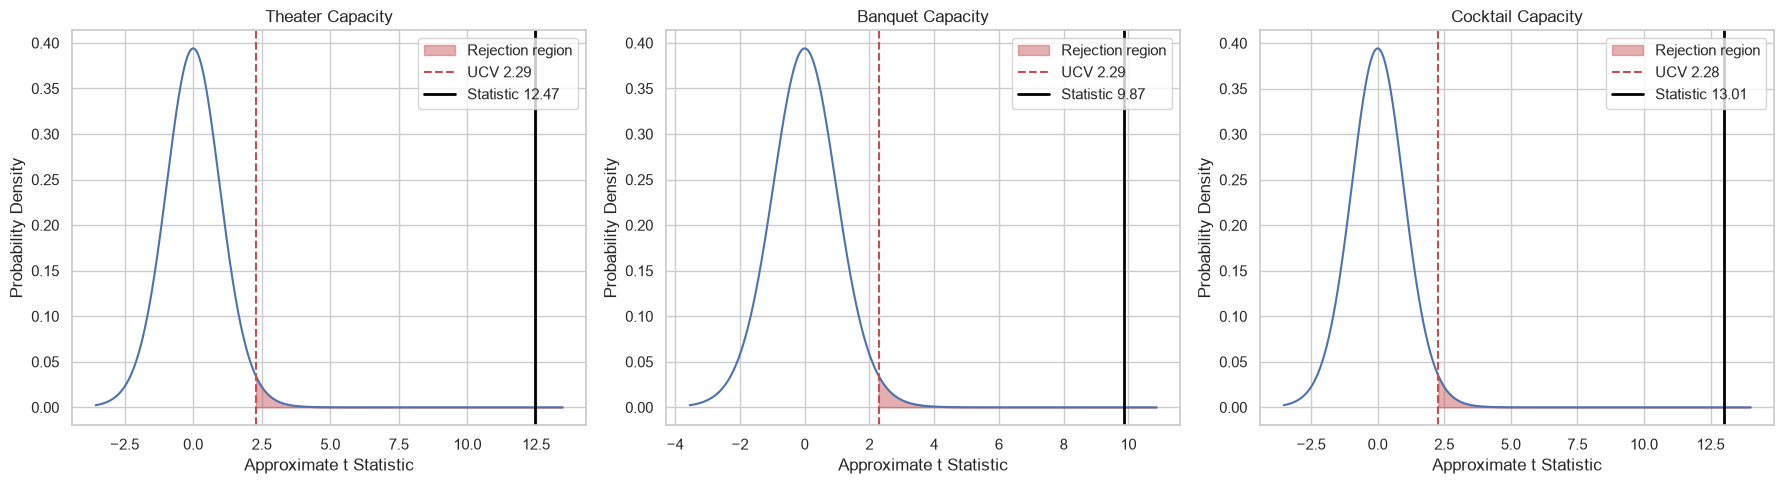

In [54]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for axis, test_record in zip(
    axes,
    venue_test_records
):
    degrees_of_freedom = (
        test_record[
            "degrees_of_freedom"
        ]
    )

    upper_critical_value = (
        test_record[
            "upper_critical_value"
        ]
    )

    test_statistic = (
        test_record[
            "test_statistic"
        ]
    )

    x_values = np.linspace(
        stats.t.ppf(
            0.001,
            degrees_of_freedom
        ),
        test_statistic + 1,
        2000
    )

    density_values = stats.t.pdf(
        x_values,
        degrees_of_freedom
    )

    axis.plot(
        x_values,
        density_values,
        color="#4C72B0"
    )

    axis.fill_between(
        x_values,
        density_values,
        where=(
            x_values
            >= upper_critical_value
        ),
        color="#C44E52",
        alpha=0.45,
        label="Rejection region"
    )

    axis.axvline(
        upper_critical_value,
        color="#C44E52",
        linestyle="--",
        label=(
            "UCV "
            f"{upper_critical_value:.2f}"
        )
    )

    axis.axvline(
        test_statistic,
        color="black",
        linewidth=2,
        label=(
            "Statistic "
            f"{test_statistic:.2f}"
        )
    )

    axis.set_title(
        test_record[
            "capacity_type"
        ].replace(
            "_",
            " "
        ).title()
    )

    axis.set_xlabel(
        "Approximate t Statistic"
    )

    axis.set_ylabel(
        "Probability Density"
    )

    axis.legend()

plt.tight_layout()
plt.show()

In [55]:
for _, test_record in (
    venue_test_results_df.iterrows()
):
    print(
        test_record[
            "capacity_type"
        ],
        f"{test_record['p_value']:.10e}"
    )

theater_capacity 3.4211967142e-11
banquet_capacity 1.9617294859e-09
cocktail_capacity 8.1136545026e-12


### Venue Capacity Hypothesis Tests

Three upper tailed Spearman association tests were conducted for theater, banquet, and cocktail capacity. A Bonferroni adjusted alpha level of 0.0167 was used to control the overall probability of a Type I error.

The theater test statistic was 12.47, exceeding the upper critical value of 2.29. The banquet statistic was 9.87, exceeding 2.29. The cocktail statistic was 13.01, exceeding 2.28.

All three null hypotheses were rejected.

### Statistical Interpretation

Venue floor area has a statistically significant positive association with all three published capacity measures, even after adjustment for multiple testing.

The Spearman correlations range from 0.91 to 0.94 and represent very large effect sizes. Cocktail and theater capacities have the strongest rank associations with floor area, while banquet capacity remains strongly associated but allows slightly more variation in layout efficiency.

The test uses a common approximation for Spearman correlation inference. The findings are also based on maximum published capacities, including values selected from conflicting desktop and mobile tables.

### Business Implication

Floor area is a reliable first indicator of the event scale a venue can support. This allows the sales team to narrow venue options quickly based on expected attendance.

Banquet arrangements require closer layout review because their capacity relationship is slightly less consistent. Final proposals should still confirm current hotel capacity limits and operational setup requirements.

In [56]:
spa_prices_df = eda_dataframes[
    "spa_prices"
].copy()

pasalubong_prices_df = eda_dataframes[
    "pasalubong_prices"
].copy()

product_price_summary_df = pd.DataFrame({
    "product_group": [
        "Spa Services",
        "Pasalubong Products"
    ],
    "records": [
        len(
            spa_prices_df
        ),
        len(
            pasalubong_prices_df
        )
    ],
    "categories": [
        spa_prices_df[
            "service_category"
        ].nunique(),
        pasalubong_prices_df[
            "menu_category"
        ].nunique()
    ],
    "minimum_price_php": [
        spa_prices_df[
            "price_php"
        ].min(),
        pasalubong_prices_df[
            "price_php"
        ].min()
    ],
    "average_price_php": [
        spa_prices_df[
            "price_php"
        ].mean(),
        pasalubong_prices_df[
            "price_php"
        ].mean()
    ],
    "median_price_php": [
        spa_prices_df[
            "price_php"
        ].median(),
        pasalubong_prices_df[
            "price_php"
        ].median()
    ],
    "maximum_price_php": [
        spa_prices_df[
            "price_php"
        ].max(),
        pasalubong_prices_df[
            "price_php"
        ].max()
    ]
})

display(
    product_price_summary_df.round(2)
)

,product_group,records,categories,minimum_price_php,average_price_php,median_price_php,maximum_price_php
0,Spa Services,26,5,300,"2,961.54","3,000.00",7500
1,Pasalubong Products,34,5,150,427.94,390.00,900


In [57]:
spa_category_summary_df = (
    spa_prices_df.groupby(
        "service_category"
    )
    .agg(
        services=(
            "service_name",
            "count"
        ),
        average_price_php=(
            "price_php",
            "mean"
        ),
        median_price_php=(
            "price_php",
            "median"
        ),
        minimum_price_php=(
            "price_php",
            "min"
        ),
        maximum_price_php=(
            "price_php",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "average_price_php",
        ascending=False
    )
)

pasalubong_category_summary_df = (
    pasalubong_prices_df.groupby(
        "menu_category"
    )
    .agg(
        products=(
            "item_name",
            "count"
        ),
        average_price_php=(
            "price_php",
            "mean"
        ),
        median_price_php=(
            "price_php",
            "median"
        ),
        minimum_price_php=(
            "price_php",
            "min"
        ),
        maximum_price_php=(
            "price_php",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "average_price_php",
        ascending=False
    )
)

print(
    "Spa categories:"
)

display(
    spa_category_summary_df.round(2)
)

print(
    "Pasalubong categories:"
)

display(
    pasalubong_category_summary_df.round(2)
)

Spa categories:


,service_category,services,average_price_php,median_price_php,minimum_price_php,maximum_price_php
1,Body Treatments,2,"5,000.00","5,000.00",5000,5000
3,Indulgent Spa Packages,7,"4,800.00","4,000.00",3000,7500
4,Signature Spa Experiences,6,"3,150.00","3,200.00",2500,3500
2,Express Treats,8,"1,662.50","1,650.00",700,2500
0,Add Ons,3,400.00,400.00,300,500


Pasalubong categories:


,menu_category,products,average_price_php,median_price_php,minimum_price_php,maximum_price_php
4,Tsaa Laya’s Tea,1,890.00,890.00,890,890
0,Breads,12,563.33,550.00,330,900
2,Spanish-Style Milkfish,3,376.67,370.00,340,420
3,The Green Olive,4,330.00,315.00,240,450
1,Others,14,317.86,300.00,150,690


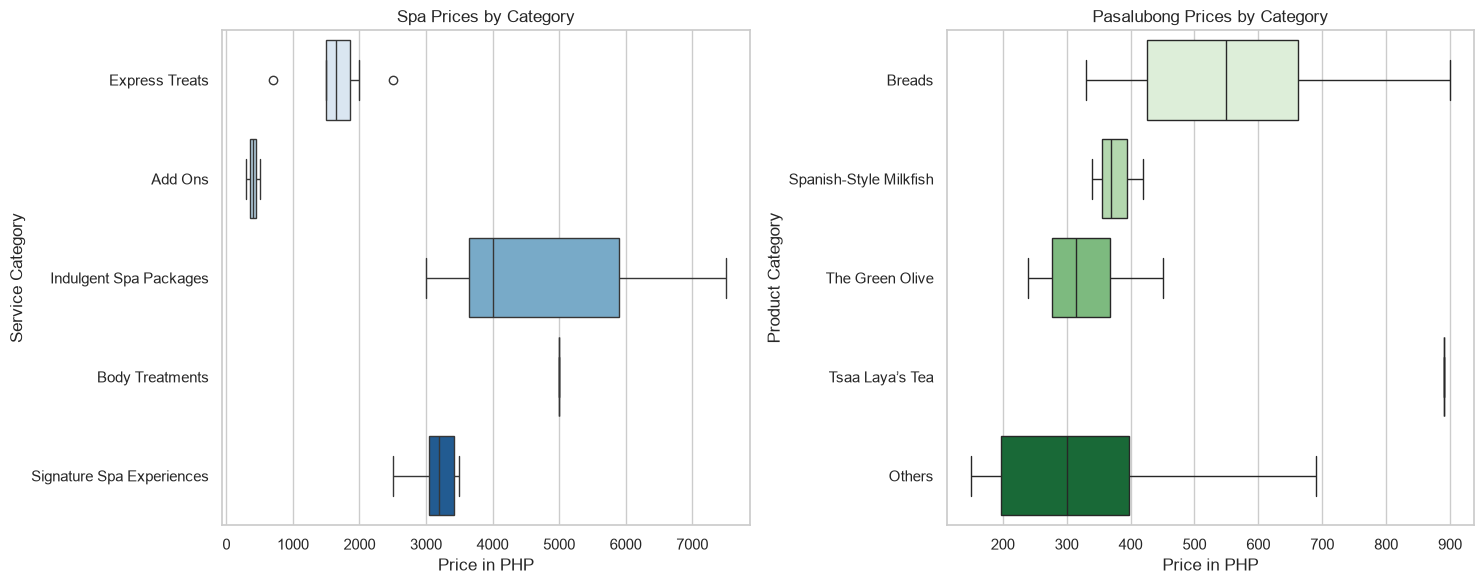

In [58]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

sns.boxplot(
    data=spa_prices_df,
    x="price_php",
    y="service_category",
    hue="service_category",
    legend=False,
    ax=axes[0],
    palette="Blues"
)

axes[0].set_title(
    "Spa Prices by Category"
)

axes[0].set_xlabel(
    "Price in PHP"
)

axes[0].set_ylabel(
    "Service Category"
)

sns.boxplot(
    data=pasalubong_prices_df,
    x="price_php",
    y="menu_category",
    hue="menu_category",
    legend=False,
    ax=axes[1],
    palette="Greens"
)

axes[1].set_title(
    "Pasalubong Prices by Category"
)

axes[1].set_xlabel(
    "Price in PHP"
)

axes[1].set_ylabel(
    "Product Category"
)

plt.tight_layout()
plt.show()

## Spa and Pasalubong Price Profiles

The Spa dataset contains 26 rate records across five service categories. Prices range from PHP 300 to PHP 7,500, with a median of PHP 3,000.

Body Treatments have the highest category average at PHP 5,000. Indulgent Spa Packages follow at PHP 4,800, while Add Ons provide the lowest entry price with an average of PHP 400.

The Pasalubong dataset contains 34 products across five categories. Prices range from PHP 150 to PHP 900, with a median of PHP 390.

Breads have an average price of PHP 563.33. Tsaa Laya’s Tea has the highest displayed category value at PHP 890, but the category contains only one product.

### Statistical Interpretation

The Spa portfolio displays a clear pricing ladder across categories. The overall mean of PHP 2,961.54 is close to the median of PHP 3,000, although variation remains within categories.

Pasalubong prices are concentrated at a much lower price level. The average of PHP 427.94 is moderately above the median of PHP 390, suggesting some influence from higher priced gift sets and larger bread packages.

Category averages based on one or two products are less stable and should be interpreted descriptively.

### Business Implication

The Spa portfolio supports customer segmentation from low cost treatment enhancements to premium packages. Add Ons may support upselling, while Indulgent Packages and Body Treatments target higher spending wellness guests.

Pasalubong products provide accessible supplementary purchases. Bread boxes and curated tea sets can serve as higher value gifts, while lower priced snacks support impulse buying.

In [59]:
product_outlier_records = []

product_price_sources = {
    "Spa Services": (
        spa_prices_df[
            "price_php"
        ]
    ),
    "Pasalubong Products": (
        pasalubong_prices_df[
            "price_php"
        ]
    )
}

for product_group, price_values in (
    product_price_sources.items()
):
    first_quartile = price_values.quantile(
        0.25
    )

    third_quartile = price_values.quantile(
        0.75
    )

    interquartile_range = (
        third_quartile
        - first_quartile
    )

    lower_boundary = (
        first_quartile
        - 1.5 * interquartile_range
    )

    upper_boundary = (
        third_quartile
        + 1.5 * interquartile_range
    )

    outlier_count = (
        (
            price_values
            < lower_boundary
        )
        | (
            price_values
            > upper_boundary
        )
    ).sum()

    shapiro_statistic, shapiro_p_value = (
        stats.shapiro(
            price_values
        )
    )

    product_outlier_records.append({
        "product_group": product_group,
        "first_quartile": first_quartile,
        "third_quartile": third_quartile,
        "interquartile_range": (
            interquartile_range
        ),
        "lower_boundary": lower_boundary,
        "upper_boundary": upper_boundary,
        "outliers": outlier_count,
        "shapiro_statistic": (
            shapiro_statistic
        ),
        "shapiro_p_value": (
            shapiro_p_value
        ),
        "normal_distribution": (
            shapiro_p_value
            >= 0.05
        )
    })

product_price_diagnostics_df = pd.DataFrame(
    product_outlier_records
)

display(
    product_price_diagnostics_df.round(4)
)

,product_group,first_quartile,third_quartile,interquartile_range,lower_boundary,upper_boundary,outliers,shapiro_statistic,shapiro_p_value,normal_distribution
0,Spa Services,"1,575.00","3,725.00","2,150.00","-1,650.00","6,950.00",1,0.96,0.32,True
1,Pasalubong Products,300.00,490.00,190.00,15.00,775.00,3,0.91,0.01,False


In [60]:
spa_upper_boundary = (
    product_price_diagnostics_df.loc[
        product_price_diagnostics_df[
            "product_group"
        ].eq(
            "Spa Services"
        ),
        "upper_boundary"
    ].iloc[0]
)

pasalubong_upper_boundary = (
    product_price_diagnostics_df.loc[
        product_price_diagnostics_df[
            "product_group"
        ].eq(
            "Pasalubong Products"
        ),
        "upper_boundary"
    ].iloc[0]
)

print(
    "Spa price outliers:"
)

display(
    spa_prices_df.loc[
        spa_prices_df[
            "price_php"
        ] > spa_upper_boundary,
        [
            "service_category",
            "service_name",
            "duration_minutes",
            "price_php"
        ]
    ]
)

print(
    "Pasalubong price outliers:"
)

display(
    pasalubong_prices_df.loc[
        pasalubong_prices_df[
            "price_php"
        ] > pasalubong_upper_boundary,
        [
            "menu_category",
            "item_name",
            "package_detail",
            "price_php"
        ]
    ]
)

Spa price outliers:


,service_category,service_name,duration_minutes,price_php
11,Indulgent Spa Packages,Couple's Sunset Retreat,90,7500


Pasalubong price outliers:


,menu_category,item_name,package_detail,price_php
1,Breads,Chicken Empanada,Box of 12,900
9,Breads,Ensaymada Halaya,Box of 12,820
19,Tsaa Laya’s Tea,Special Tea Set,"1 canister Lemon Ginger, 2 Bughaw Floral Blend...",890


### Spa and Pasalubong Outliers

The Spa price distribution has one upper outlier above PHP 6,950. Couple's Sunset Retreat is priced at PHP 7,500.

The Shapiro Wilk p value was 0.32, so normality was not rejected for Spa prices.

The Pasalubong price distribution contains three upper outliers above PHP 775. These are the Chicken Empanada Box of 12, Ensaymada Halaya Box of 12, and Special Tea Set.

The Pasalubong Shapiro Wilk p value was approximately 0.01, so normality was rejected.

### Statistical Interpretation

The Spa outlier represents a specialized couple package rather than an erroneous observation. The remaining Spa prices are sufficiently consistent with a normal distribution based on the current sample.

Pasalubong prices are nonnormal because larger packages and curated gift sets occupy a separate upper price tier.

### Business Implication

Couple's Sunset Retreat should be evaluated as a premium shared experience rather than directly compared with individual treatments.

The higher priced Pasalubong records represent gift and bulk purchase opportunities. Removing them would understate the range of customer spending options. Product analysis should distinguish individual items from larger boxes and curated sets.

In [61]:
spa_prices_df[
    "price_per_minute_php"
] = (
    spa_prices_df[
        "price_php"
    ]
    / spa_prices_df[
        "duration_minutes"
    ]
)

spa_duration_summary_df = (
    spa_prices_df.groupby(
        "duration_minutes"
    )
    .agg(
        services=(
            "service_name",
            "count"
        ),
        average_price_php=(
            "price_php",
            "mean"
        ),
        median_price_php=(
            "price_php",
            "median"
        ),
        average_price_per_minute_php=(
            "price_per_minute_php",
            "mean"
        )
    )
    .reset_index()
)

display(
    spa_duration_summary_df.round(2)
)

spa_duration_spearman = stats.spearmanr(
    spa_prices_df[
        "duration_minutes"
    ],
    spa_prices_df[
        "price_php"
    ],
    alternative="greater"
)

print(
    "Spearman correlation:",
    round(
        spa_duration_spearman.statistic,
        4
    )
)

print(
    "P value:",
    f"{spa_duration_spearman.pvalue:.10e}"
)

print(
    "Effect size:",
    round(
        spa_duration_spearman.statistic,
        4
    )
)

,duration_minutes,services,average_price_php,median_price_php,average_price_per_minute_php
0,15,4,475.00,450.00,31.67
1,45,4,"1,625.00","1,500.00",36.11
2,60,4,"2,150.00","2,150.00",35.83
3,90,8,"3,837.50","3,350.00",42.64
4,105,2,"4,650.00","4,650.00",44.29
5,120,3,"4,666.67","5,000.00",38.89
6,180,1,"6,000.00","6,000.00",33.33


Spearman correlation: 0.9344
P value: 1.4945052954e-12
Effect size: 0.9344


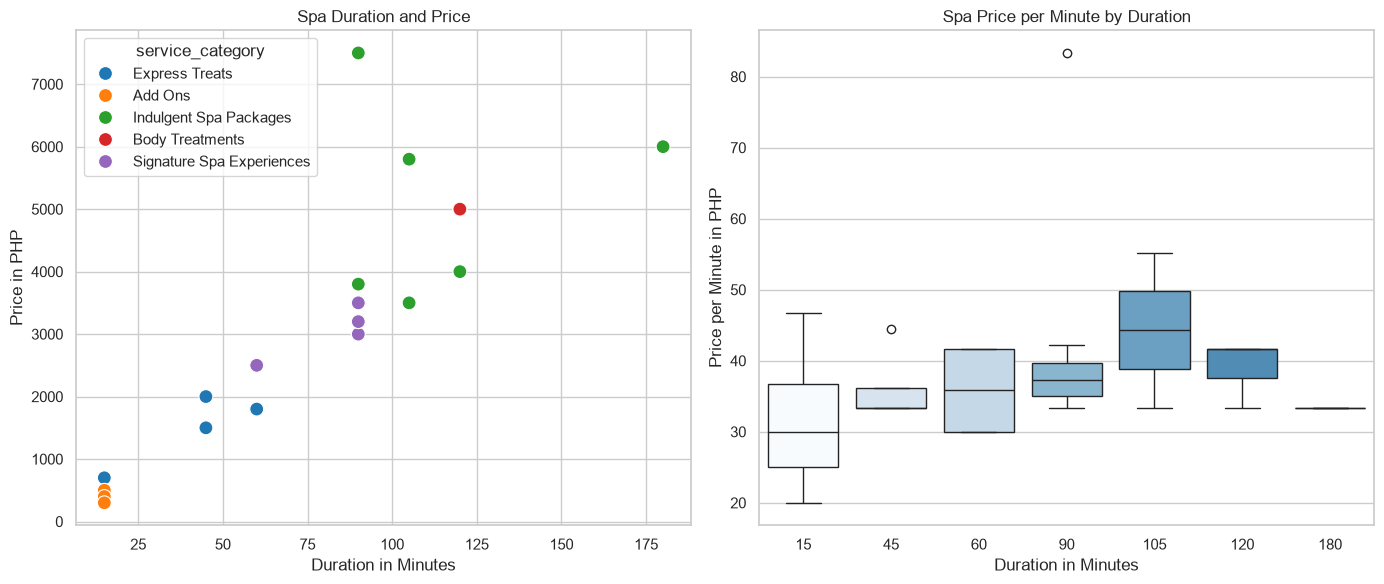

In [62]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

sns.scatterplot(
    data=spa_prices_df,
    x="duration_minutes",
    y="price_php",
    hue="service_category",
    s=100,
    ax=axes[0],
    palette="tab10"
)

axes[0].set_title(
    "Spa Duration and Price"
)

axes[0].set_xlabel(
    "Duration in Minutes"
)

axes[0].set_ylabel(
    "Price in PHP"
)

sns.boxplot(
    data=spa_prices_df,
    x="duration_minutes",
    y="price_per_minute_php",
    hue="duration_minutes",
    legend=False,
    ax=axes[1],
    palette="Blues"
)

axes[1].set_title(
    "Spa Price per Minute by Duration"
)

axes[1].set_xlabel(
    "Duration in Minutes"
)

axes[1].set_ylabel(
    "Price per Minute in PHP"
)

plt.tight_layout()
plt.show()

In [63]:
spa_sample_size = len(
    spa_prices_df
)

spa_degrees_of_freedom = (
    spa_sample_size
    - 2
)

spa_test_statistic = (
    spa_duration_spearman.statistic
    * np.sqrt(
        spa_degrees_of_freedom
        / (
            1
            - spa_duration_spearman.statistic ** 2
        )
    )
)

spa_upper_critical_value = stats.t.ppf(
    0.95,
    spa_degrees_of_freedom
)

print(
    "Sample size:",
    spa_sample_size
)

print(
    "Degrees of freedom:",
    spa_degrees_of_freedom
)

print(
    "Lower critical value:",
    "Not applicable for this upper tailed test"
)

print(
    "Upper critical value:",
    round(
        spa_upper_critical_value,
        4
    )
)

print(
    "Test statistic:",
    round(
        spa_test_statistic,
        4
    )
)

print(
    "P value:",
    f"{spa_duration_spearman.pvalue:.10e}"
)

if spa_duration_spearman.pvalue < 0.05:
    print(
        "Decision: Reject the null hypothesis"
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis"
    )

Sample size: 26
Degrees of freedom: 24
Lower critical value: Not applicable for this upper tailed test
Upper critical value: 1.7109
Test statistic: 12.8507
P value: 1.4945052954e-12
Decision: Reject the null hypothesis


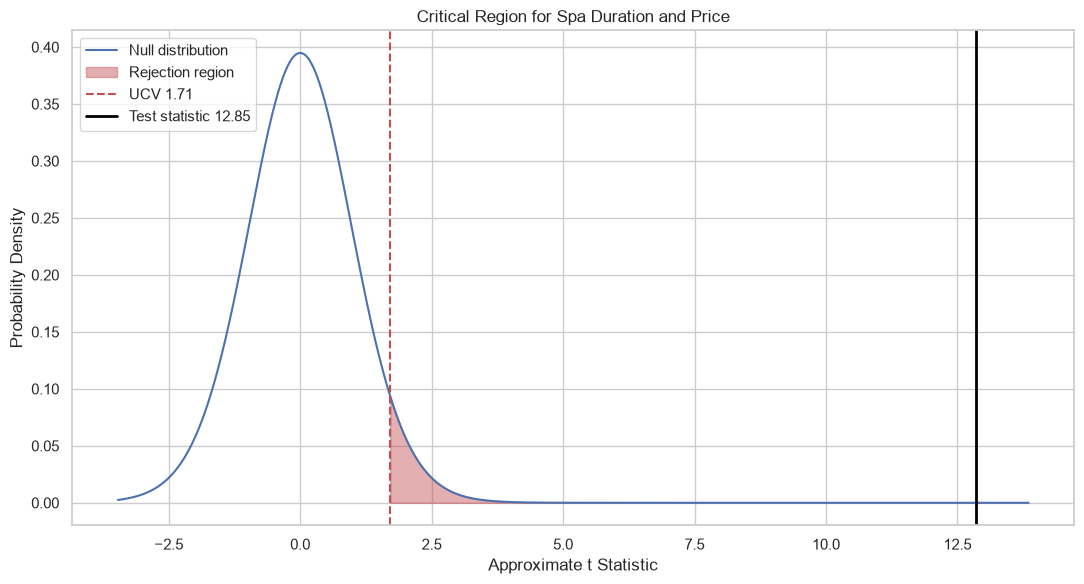

In [64]:
spa_t_values = np.linspace(
    stats.t.ppf(
        0.001,
        spa_degrees_of_freedom
    ),
    spa_test_statistic + 1,
    2000
)

spa_t_density = stats.t.pdf(
    spa_t_values,
    spa_degrees_of_freedom
)

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    spa_t_values,
    spa_t_density,
    color="#4C72B0",
    label="Null distribution"
)

plt.fill_between(
    spa_t_values,
    spa_t_density,
    where=(
        spa_t_values
        >= spa_upper_critical_value
    ),
    color="#C44E52",
    alpha=0.45,
    label="Rejection region"
)

plt.axvline(
    spa_upper_critical_value,
    color="#C44E52",
    linestyle="--",
    label=(
        "UCV "
        f"{spa_upper_critical_value:.2f}"
    )
)

plt.axvline(
    spa_test_statistic,
    color="black",
    linewidth=2,
    label=(
        "Test statistic "
        f"{spa_test_statistic:.2f}"
    )
)

plt.title(
    "Critical Region for Spa Duration and Price"
)

plt.xlabel(
    "Approximate t Statistic"
)

plt.ylabel(
    "Probability Density"
)

plt.legend()
plt.tight_layout()
plt.show()

### Spa Duration and Price Relationship

Spa duration and price have a Spearman correlation of 0.9344, representing a very large positive effect. The p value is substantially below the 0.05 alpha level.

The null hypothesis is rejected. Longer Spa services tend to have higher total prices.

### Statistical Interpretation

The relationship between duration and total price is strong and statistically significant. However, price per minute is not constant across durations.

The 105 minute services have the highest average price per minute, while the 180 minute package provides a lower effective rate. The 90 minute average is partly influenced by Couple's Sunset Retreat, which serves two guests.

### Business Implication

Duration is a major driver of Spa pricing, but service content and number of guests also contribute to price.

Longer packages can be positioned as better time based value, while 90 and 105 minute services may justify higher effective rates through added treatments, premium components, or shared experiences.

Management should avoid presenting price per minute as the only measure of value because treatment complexity and package inclusions differ.

In [65]:
bread_prices_df = (
    pasalubong_prices_df[
        pasalubong_prices_df[
            "menu_category"
        ].eq(
            "Breads"
        )
    ]
    .copy()
)

bread_prices_df[
    "pieces_per_box"
] = (
    bread_prices_df[
        "package_detail"
    ]
    .str.extract(
        r"(\d+)"
    )[0]
    .astype(
        int
    )
)

bread_prices_df[
    "price_per_piece_php"
] = (
    bread_prices_df[
        "price_php"
    ]
    / bread_prices_df[
        "pieces_per_box"
    ]
)

bread_package_pivot_df = (
    bread_prices_df.pivot_table(
        index="item_name",
        columns="pieces_per_box",
        values="price_php"
    )
    .rename(
        columns={
            6: "box_of_6_price_php",
            12: "box_of_12_price_php"
        }
    )
    .dropna()
    .reset_index()
)

bread_package_pivot_df[
    "cost_of_two_boxes_of_6_php"
] = (
    bread_package_pivot_df[
        "box_of_6_price_php"
    ]
    * 2
)

bread_package_pivot_df[
    "box_of_12_savings_php"
] = (
    bread_package_pivot_df[
        "cost_of_two_boxes_of_6_php"
    ]
    - bread_package_pivot_df[
        "box_of_12_price_php"
    ]
)

bread_package_pivot_df[
    "box_of_12_savings_percent"
] = (
    bread_package_pivot_df[
        "box_of_12_savings_php"
    ]
    / bread_package_pivot_df[
        "cost_of_two_boxes_of_6_php"
    ]
    * 100
)

bread_package_pivot_df[
    "box_of_6_price_per_piece_php"
] = (
    bread_package_pivot_df[
        "box_of_6_price_php"
    ]
    / 6
)

bread_package_pivot_df[
    "box_of_12_price_per_piece_php"
] = (
    bread_package_pivot_df[
        "box_of_12_price_php"
    ]
    / 12
)

display(
    bread_package_pivot_df.round(2)
)

print(
    "Bread products compared:",
    len(
        bread_package_pivot_df
    )
)

print(
    "Average savings in PHP:",
    round(
        bread_package_pivot_df[
            "box_of_12_savings_php"
        ].mean(),
        2
    )
)

print(
    "Average savings percent:",
    round(
        bread_package_pivot_df[
            "box_of_12_savings_percent"
        ].mean(),
        2
    )
)

print(
    "Products with quantity savings:",
    (
        bread_package_pivot_df[
            "box_of_12_savings_php"
        ] > 0
    ).sum()
)

pieces_per_box,item_name,box_of_6_price_php,box_of_12_price_php,cost_of_two_boxes_of_6_php,box_of_12_savings_php,box_of_12_savings_percent,box_of_6_price_per_piece_php,box_of_12_price_per_piece_php
0,Cheese Bread,350.00,650.00,700.00,50.00,7.14,58.33,54.17
1,Chicken Empanada,500.00,900.00,"1,000.00",100.00,10.00,83.33,75.00
2,Ensaymada Brioche,450.00,700.00,900.00,200.00,22.22,75.00,58.33
3,Ensaymada Halaya,460.00,820.00,920.00,100.00,10.87,76.67,68.33
4,Pan de Coco,350.00,650.00,700.00,50.00,7.14,58.33,54.17
5,Ube Cheese Pandesal,330.00,600.00,660.00,60.00,9.09,55.00,50.00


Bread products compared: 6
Average savings in PHP: 93.33
Average savings percent: 11.08
Products with quantity savings: 6


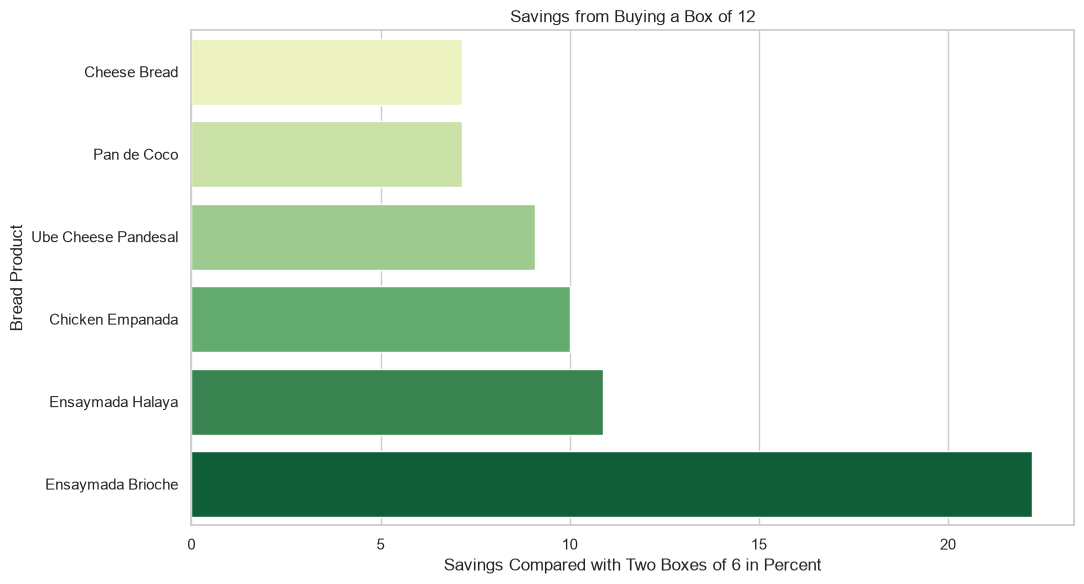

In [66]:
bread_savings_plot_df = (
    bread_package_pivot_df.sort_values(
        "box_of_12_savings_percent"
    )
)

plt.figure(
    figsize=(11, 6)
)

sns.barplot(
    data=bread_savings_plot_df,
    x="box_of_12_savings_percent",
    y="item_name",
    hue="item_name",
    legend=False,
    palette="YlGn"
)

plt.title(
    "Savings from Buying a Box of 12"
)

plt.xlabel(
    "Savings Compared with Two Boxes of 6 in Percent"
)

plt.ylabel(
    "Bread Product"
)

plt.tight_layout()
plt.show()

### Bread Box Quantity Discounts

All six bread products provide savings when customers purchase a box of 12 instead of two boxes of six.

The average saving is PHP 93.33, equivalent to 11.08 percent.

### Statistical Interpretation

The direction of the price difference is completely consistent across the six products. Every box of 12 has a lower total cost than the equivalent quantity purchased through two boxes of six.

The percentage reduction varies by product, indicating that the strength of the quantity discount is not uniform.

### Business Implication

The box of 12 provides a clear incentive for larger purchases and may increase average transaction value. The hotel can communicate both the total saving and lower price per piece to make the value easier for customers to recognize.

Products with smaller percentage savings may be reviewed to determine whether a more consistent quantity discount would strengthen the offer.

In [67]:
bread_saving_count = (
    bread_package_pivot_df[
        "box_of_12_savings_php"
    ].gt(
        0
    ).sum()
)

bread_product_count = len(
    bread_package_pivot_df
)

bread_sign_test = stats.binomtest(
    bread_saving_count,
    n=bread_product_count,
    p=0.50,
    alternative="greater"
)

bread_confidence_interval = (
    bread_sign_test.proportion_ci(
        confidence_level=0.95,
        method="wilson"
    )
)

bread_observed_probability = (
    bread_saving_count
    / bread_product_count
)

bread_cohens_h = (
    2
    * np.arcsin(
        np.sqrt(
            bread_observed_probability
        )
    )
    - 2
    * np.arcsin(
        np.sqrt(
            0.50
        )
    )
)

print(
    "Products with savings:",
    bread_saving_count
)

print(
    "Products compared:",
    bread_product_count
)

print(
    "Observed savings probability:",
    round(
        bread_observed_probability,
        4
    )
)

print(
    "Exact binomial p value:",
    round(
        bread_sign_test.pvalue,
        6
    )
)

print(
    "Confidence interval lower bound:",
    round(
        bread_confidence_interval.low,
        4
    )
)

print(
    "Confidence interval upper bound:",
    round(
        bread_confidence_interval.high,
        4
    )
)

print(
    "Cohen h:",
    round(
        bread_cohens_h,
        4
    )
)

Products with savings: 6
Products compared: 6
Observed savings probability: 1.0
Exact binomial p value: 0.015625
Confidence interval lower bound: 0.6892
Confidence interval upper bound: 1.0
Cohen h: 1.5708


In [68]:
bread_possible_savings = np.arange(
    0,
    bread_product_count + 1
)

bread_null_probabilities = stats.binom.pmf(
    bread_possible_savings,
    bread_product_count,
    0.50
)

bread_upper_critical_value = next(
    saving_count
    for saving_count
    in bread_possible_savings
    if stats.binom.sf(
        saving_count - 1,
        bread_product_count,
        0.50
    ) <= 0.05
)

print(
    "Lower critical value:",
    "Not applicable for this upper tailed test"
)

print(
    "Upper critical value:",
    bread_upper_critical_value
)

print(
    "Observed saving count:",
    bread_saving_count
)

print(
    "Rejection region:",
    (
        "Products with savings are at least "
        f"{bread_upper_critical_value}"
    )
)

if bread_sign_test.pvalue < 0.05:
    print(
        "Decision: Reject the null hypothesis"
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis"
    )

Lower critical value: Not applicable for this upper tailed test
Upper critical value: 6
Observed saving count: 6
Rejection region: Products with savings are at least 6
Decision: Reject the null hypothesis


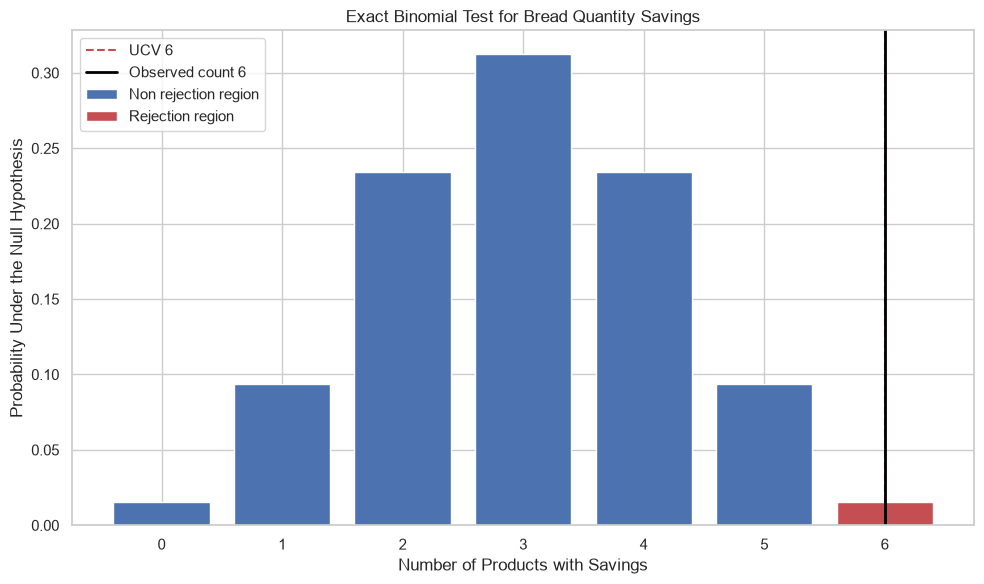

In [69]:
bread_rejection_mask = (
    bread_possible_savings
    >= bread_upper_critical_value
)

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    bread_possible_savings[
        ~bread_rejection_mask
    ],
    bread_null_probabilities[
        ~bread_rejection_mask
    ],
    color="#4C72B0",
    label="Non rejection region"
)

plt.bar(
    bread_possible_savings[
        bread_rejection_mask
    ],
    bread_null_probabilities[
        bread_rejection_mask
    ],
    color="#C44E52",
    label="Rejection region"
)

plt.axvline(
    bread_upper_critical_value,
    color="#C44E52",
    linestyle="--",
    label=(
        "UCV "
        f"{bread_upper_critical_value}"
    )
)

plt.axvline(
    bread_saving_count,
    color="black",
    linewidth=2,
    label=(
        "Observed count "
        f"{bread_saving_count}"
    )
)

plt.title(
    "Exact Binomial Test for Bread Quantity Savings"
)

plt.xlabel(
    "Number of Products with Savings"
)

plt.ylabel(
    "Probability Under the Null Hypothesis"
)

plt.xticks(
    bread_possible_savings
)

plt.legend()
plt.tight_layout()
plt.show()

### Bread Quantity Discount Test

All six bread products provided savings when a box of 12 was compared with two boxes of six.

The exact binomial p value was 0.015625. The observed saving count of six reached the upper critical value of six, placing the result in the rejection region.

The null hypothesis was rejected. Cohen h was 1.5708, indicating a very large effect. The one sided 95 percent confidence interval ranged from 68.92 percent to 100 percent.

### Statistical Interpretation

There is statistically significant evidence that the current bread menu consistently provides quantity savings for boxes of 12.

The effect is large because every observed product follows the same pricing direction. However, the sample contains only six products, so the exact percentage of future products offering savings remains uncertain.

### Business Implication

The quantity discount is a consistent feature of the current bread menu. Marketing materials can accurately communicate that buying a box of 12 provides better value than purchasing the same quantity through two smaller boxes.

Management can use the average saving of PHP 93.33 or 11.08 percent as a descriptive portfolio benchmark while showing product specific savings to customers.

In [72]:
wedding_rates_df = eda_dataframes[
    "wedding_rates"
].copy()

christmas_packages_df = eda_dataframes[
    "christmas_packages"
].copy()

wedding_reception_df = (
    wedding_rates_df[
        wedding_rates_df[
            "package_category"
        ].eq(
            "Reception"
        )
    ]
    .copy()
)

wedding_reception_df[
    "base_price_per_person_php"
] = (
    wedding_reception_df[
        "package_price_php"
    ]
    / wedding_reception_df[
        "included_persons"
    ]
)

wedding_reception_df[
    "excess_rate_difference_php"
] = (
    wedding_reception_df[
        "excess_person_rate_php"
    ]
    - wedding_reception_df[
        "base_price_per_person_php"
    ]
)

wedding_reception_df[
    "excess_rate_difference_percent"
] = (
    wedding_reception_df[
        "excess_rate_difference_php"
    ]
    / wedding_reception_df[
        "base_price_per_person_php"
    ]
    * 100
)

christmas_packages_df[
    "base_price_per_person_php"
] = (
    christmas_packages_df[
        "package_price_php"
    ]
    / christmas_packages_df[
        "guaranteed_persons"
    ]
)

wedding_reception_df[
    "package_cost_per_included_person_php"
] = (
    wedding_reception_df[
        "base_price_per_person_php"
    ]
)

christmas_packages_df[
    "package_cost_per_guaranteed_person_php"
] = (
    christmas_packages_df[
        "base_price_per_person_php"
    ]
)

christmas_packages_df[
    "excess_rate_difference_php"
] = (
    christmas_packages_df[
        "excess_person_rate_php"
    ]
    - christmas_packages_df[
        "base_price_per_person_php"
    ]
)

christmas_packages_df[
    "excess_rate_difference_percent"
] = (
    christmas_packages_df[
        "excess_rate_difference_php"
    ]
    / christmas_packages_df[
        "base_price_per_person_php"
    ]
    * 100
)

print(
    "Wedding reception package unit prices:"
)

display(
    wedding_reception_df[
        [
            "package_name",
            "menu_style",
            "included_persons",
            "package_price_php",
            "base_price_per_person_php",
            "excess_person_rate_php",
            "excess_rate_difference_percent"
        ]
    ]
    .sort_values(
        [
            "package_name",
            "menu_style"
        ]
    )
    .round(2)
)

print(
    "Christmas package unit prices:"
)

display(
    christmas_packages_df[
        [
            "package_name",
            "guaranteed_persons",
            "package_price_php",
            "base_price_per_person_php",
            "excess_person_rate_php",
            "excess_rate_difference_percent"
        ]
    ]
    .sort_values(
        "guaranteed_persons"
    )
    .round(2)
)

Wedding reception package unit prices:


,package_name,menu_style,included_persons,package_price_php,base_price_per_person_php,excess_person_rate_php,excess_rate_difference_percent
2,Blue Lace Agate,Buffet Menu,100.00,495000,"4,950.00","2,950.00",-40.40
3,Blue Lace Agate,Set Menu,100.00,498888,"4,988.88","2,980.00",-40.27
6,Green Jade,Buffet Menu,100.00,995000,"9,950.00","3,300.00",-66.83
7,Green Jade,Set Menu,100.00,1000000,"10,000.00","3,350.00",-66.50
4,Lemon Quartz,Buffet Menu,100.00,685000,"6,850.00","3,200.00",-53.28
5,Lemon Quartz,Set Menu,100.00,690888,"6,908.88","3,300.00",-52.24
0,Rose Quartz,Buffet Menu,100.00,350000,"3,500.00","2,400.00",-31.43
1,Rose Quartz,Set Menu,100.00,360000,"3,600.00","2,500.00",-30.56


Christmas package unit prices:


,package_name,guaranteed_persons,package_price_php,base_price_per_person_php,excess_person_rate_php,excess_rate_difference_percent
0,Classic Noel,20,39000,"1,950.00",1800,-7.69
1,Holiday Elegance,35,82000,"2,342.86",2150,-8.23
2,Festive Prestige,50,105000,"2,100.00",2250,7.14
3,Yuletide Collection,100,225000,"2,250.00",2350,4.44


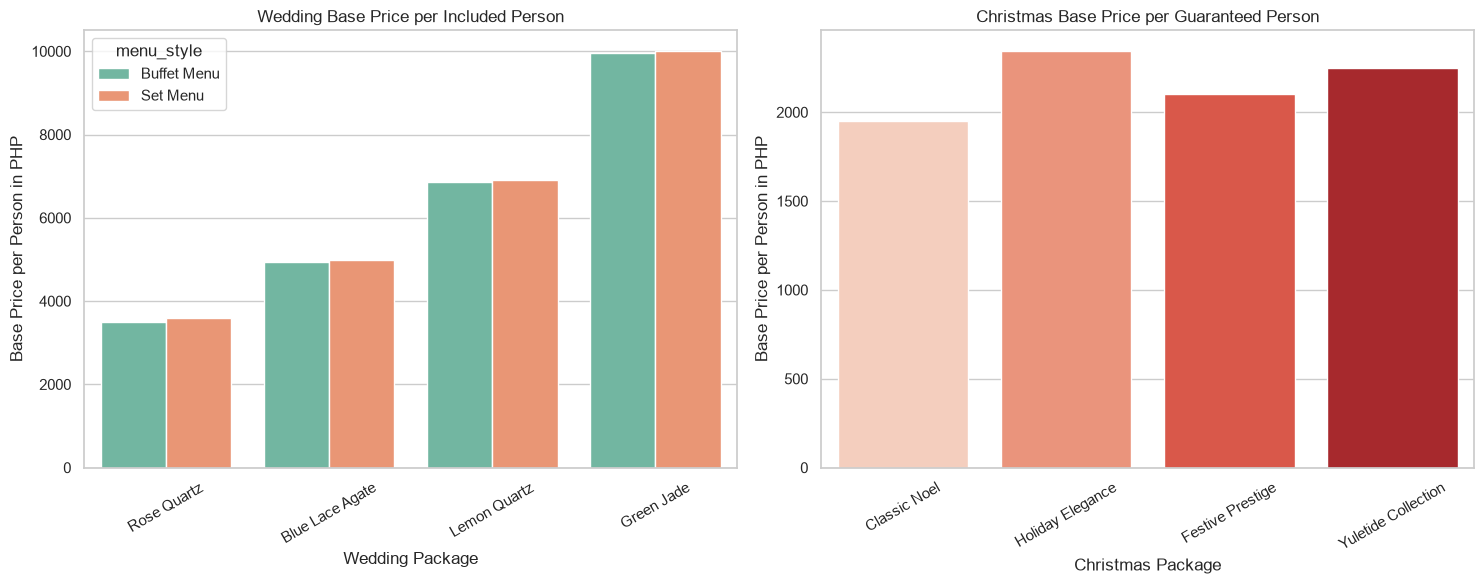

In [71]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

sns.barplot(
    data=wedding_reception_df,
    x="package_name",
    y="base_price_per_person_php",
    hue="menu_style",
    ax=axes[0],
    palette="Set2"
)

axes[0].set_title(
    "Wedding Base Price per Included Person"
)

axes[0].set_xlabel(
    "Wedding Package"
)

axes[0].set_ylabel(
    "Base Price per Person in PHP"
)

axes[0].tick_params(
    axis="x",
    rotation=30
)

sns.barplot(
    data=christmas_packages_df,
    x="package_name",
    y="base_price_per_person_php",
    hue="package_name",
    legend=False,
    ax=axes[1],
    palette="Reds"
)

axes[1].set_title(
    "Christmas Base Price per Guaranteed Person"
)

axes[1].set_xlabel(
    "Christmas Package"
)

axes[1].set_ylabel(
    "Base Price per Person in PHP"
)

axes[1].tick_params(
    axis="x",
    rotation=30
)

plt.tight_layout()
plt.show()

## Wedding and Christmas Package Unit Allocation

Wedding reception packages range from PHP 350,000 to PHP 1,000,000 for 100 included guests.

Rose Quartz has the lowest allocated package cost at PHP 3,500 to PHP 3,600 per included person. Green Jade has the highest at PHP 9,950 to PHP 10,000.

Set Menu prices are higher than Buffet Menu prices across all four wedding tiers.

Christmas packages range from 20 to 100 guaranteed guests. Classic Noel has an allocated package cost of PHP 1,950 per guaranteed person, while the other packages range from approximately PHP 2,100 to PHP 2,343.

### Statistical Interpretation

Wedding excess guest rates are consistently lower than the total package cost divided by the included guest count. This does not represent a direct food discount because the original package price contains fixed benefits that do not increase proportionally with every additional guest.

The same limitation applies to Christmas packages. Differences between the allocated package cost and excess guest rate reflect a mixture of fixed package benefits and variable guest costs.

### Business Implication

The package price per included or guaranteed person is useful for comparing overall package tiers, but it should not be presented as the meal price per person.

Premium Wedding packages may justify higher allocated costs through accommodation, decoration, entertainment, beverage, and venue benefits. Sales teams should explain these inclusions clearly so customers understand why excess guest rates are lower than the initial package allocation.

In [73]:
wedding_menu_pivot_df = (
    wedding_reception_df.pivot_table(
        index="package_name",
        columns="menu_style",
        values="package_price_php"
    )
    .reset_index()
)

wedding_menu_pivot_df[
    "set_menu_premium_php"
] = (
    wedding_menu_pivot_df[
        "Set Menu"
    ]
    - wedding_menu_pivot_df[
        "Buffet Menu"
    ]
)

wedding_menu_pivot_df[
    "set_menu_premium_percent"
] = (
    wedding_menu_pivot_df[
        "set_menu_premium_php"
    ]
    / wedding_menu_pivot_df[
        "Buffet Menu"
    ]
    * 100
)

display(
    wedding_menu_pivot_df.round(2)
)

set_menu_higher_count = (
    wedding_menu_pivot_df[
        "set_menu_premium_php"
    ].gt(
        0
    ).sum()
)

wedding_package_count = len(
    wedding_menu_pivot_df
)

wedding_sign_test = stats.binomtest(
    set_menu_higher_count,
    n=wedding_package_count,
    p=0.50,
    alternative="greater"
)

wedding_observed_probability = (
    set_menu_higher_count
    / wedding_package_count
)

wedding_cohens_h = (
    2
    * np.arcsin(
        np.sqrt(
            wedding_observed_probability
        )
    )
    - 2
    * np.arcsin(
        np.sqrt(
            0.50
        )
    )
)

print(
    "Packages with a Set Menu premium:",
    set_menu_higher_count
)

print(
    "Packages compared:",
    wedding_package_count
)

print(
    "Average Set Menu premium:",
    round(
        wedding_menu_pivot_df[
            "set_menu_premium_php"
        ].mean(),
        2
    )
)

print(
    "Median Set Menu premium:",
    round(
        wedding_menu_pivot_df[
            "set_menu_premium_php"
        ].median(),
        2
    )
)

print(
    "Exact binomial p value:",
    round(
        wedding_sign_test.pvalue,
        6
    )
)

print(
    "Cohen h:",
    round(
        wedding_cohens_h,
        4
    )
)

if wedding_sign_test.pvalue < 0.05:
    print(
        "Decision: Reject the null hypothesis"
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis"
    )

menu_style,package_name,Buffet Menu,Set Menu,set_menu_premium_php,set_menu_premium_percent
0,Blue Lace Agate,"495,000.00","498,888.00","3,888.00",0.79
1,Green Jade,"995,000.00","1,000,000.00","5,000.00",0.50
2,Lemon Quartz,"685,000.00","690,888.00","5,888.00",0.86
3,Rose Quartz,"350,000.00","360,000.00","10,000.00",2.86


Packages with a Set Menu premium: 4
Packages compared: 4
Average Set Menu premium: 6194.0
Median Set Menu premium: 5444.0
Exact binomial p value: 0.0625
Cohen h: 1.5708
Decision: Fail to reject the null hypothesis


In [74]:
wedding_possible_counts = np.arange(
    0,
    wedding_package_count + 1
)

wedding_null_probabilities = stats.binom.pmf(
    wedding_possible_counts,
    wedding_package_count,
    0.50
)

minimum_possible_p_value = (
    0.50 ** wedding_package_count
)

print(
    "Lower critical value:",
    "Not applicable for this upper tailed test"
)

print(
    "Upper critical value:",
    "Not attainable with four observations"
)

print(
    "Observed count:",
    set_menu_higher_count
)

print(
    "Smallest attainable p value:",
    minimum_possible_p_value
)

print(
    "Rejection region:",
    "None at alpha 0.05"
)

Lower critical value: Not applicable for this upper tailed test
Upper critical value: Not attainable with four observations
Observed count: 4
Smallest attainable p value: 0.0625
Rejection region: None at alpha 0.05


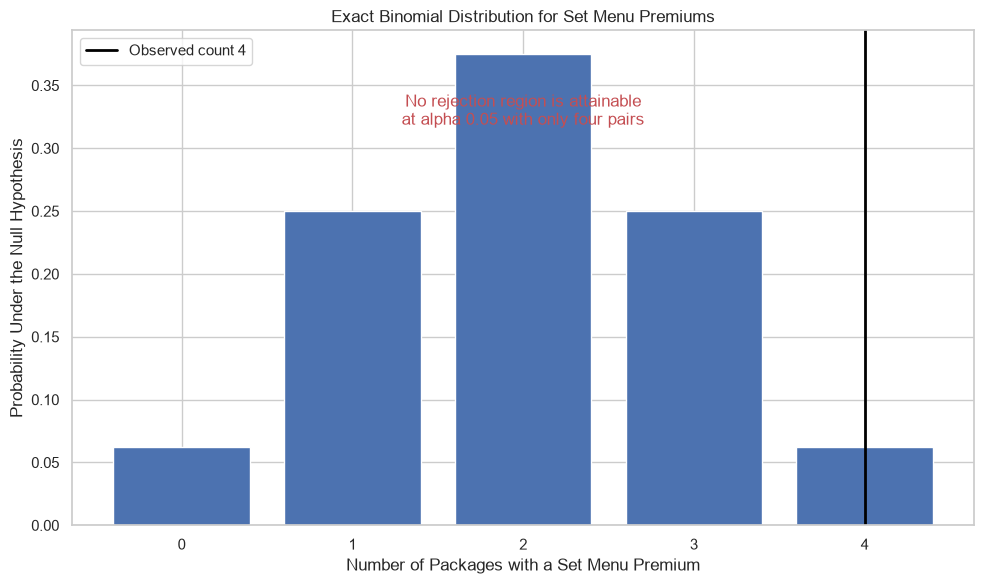

In [75]:
plt.figure(
    figsize=(10, 6)
)

plt.bar(
    wedding_possible_counts,
    wedding_null_probabilities,
    color="#4C72B0"
)

plt.axvline(
    set_menu_higher_count,
    color="black",
    linewidth=2,
    label=(
        "Observed count "
        f"{set_menu_higher_count}"
    )
)

plt.text(
    2,
    max(
        wedding_null_probabilities
    ) * 0.85,
    (
        "No rejection region is attainable\n"
        "at alpha 0.05 with only four pairs"
    ),
    ha="center",
    color="#C44E52"
)

plt.title(
    "Exact Binomial Distribution for Set Menu Premiums"
)

plt.xlabel(
    "Number of Packages with a Set Menu Premium"
)

plt.ylabel(
    "Probability Under the Null Hypothesis"
)

plt.xticks(
    wedding_possible_counts
)

plt.legend()
plt.tight_layout()
plt.show()

### Wedding Set Menu Premium Test

Set Menu prices were higher than Buffet Menu prices across all four Wedding package tiers.

The average Set Menu premium was PHP 6,194, while the median premium was PHP 5,444. Percentage premiums ranged from 0.50 percent for Green Jade to 2.86 percent for Rose Quartz.

The exact binomial p value was 0.0625. No rejection region was attainable at an alpha level of 0.05 because the smallest possible one sided p value with four observations was also 0.0625.

The null hypothesis was not rejected. Cohen h was 1.5708, indicating a very large observed directional effect.

### Statistical Interpretation

All observed packages follow the same pricing direction, but four pairs do not provide enough statistical resolution to establish significance at the 0.05 level.

The result illustrates the difference between practical consistency and statistical significance. The observed effect is large, but the sample is very small.

Failing to reject the null hypothesis does not mean that Set Menu and Buffet Menu prices are equal. It means that the available sample is insufficient for a statistically conclusive general statement.

### Business Implication

The current package menu consistently applies a Set Menu premium. Sales teams can report the exact premium for each published package.

The premium is relatively small as a percentage of the full Wedding package price. Management should clearly communicate the service or dining benefits that distinguish the Set Menu option.

Future package versions can be added to the analysis to determine whether this pricing pattern remains consistent over time.

In [76]:
remaining_dataset_names = [
    "dining",
    "promotions",
    "official_reviews",
    "facilities",
    "hotel_facts",
    "hotel_contact"
]

for dataset_name in remaining_dataset_names:
    current_df = eda_dataframes[
        dataset_name
    ]

    print()
    print(
        "DATASET:",
        dataset_name
    )

    print(
        "Shape:",
        current_df.shape
    )

    print(
        "Columns:"
    )

    print(
        current_df.columns.tolist()
    )

    display(
        current_df.head()
    )


DATASET: dining
Shape: (5, 12)
Columns:
['outlet_record_id', 'outlet_name', 'tagline', 'outlet_description', 'operating_hours', 'schedule_note', 'menu_url', 'reservation_url', 'source_url', 'date_collected', 'reservation_url_available', 'reservation_url_fallback_used']


,outlet_record_id,outlet_name,tagline,outlet_description,operating_hours,schedule_note,menu_url,reservation_url,source_url,date_collected,reservation_url_available,reservation_url_fallback_used
0,1,VERANDA,Broad and Open,"For a sentimental and harmonious vibe, partake...","Open daily, 6:00 AM – 10:00 PM",NOTE: Schedule for buffet may change without p...,https://www.taalvistahotel.com/veranda_menu/,https://forms.office.com/r/LTwLn6BxuU,https://www.taalvistahotel.com/dining/,2026-09-02,True,False
1,2,TĀZA FRESH TABLE,Sustainable and Natural,"For a blissful and breezy surrounding, you can...","Open daily, 12:00 NN – 10:00 PM",Not displayed,https://www.taalvistahotel.com/taza_menu,https://forms.office.com/r/LTwLn6BxuU,https://www.taalvistahotel.com/dining/,2026-09-02,True,False
2,3,LOBBY LOUNGE,Grand and Iconic,Underneath the remarkable Tudor-designed rooft...,Sunday to Thursday 10:00 AM – 11:00 PM | Frida...,Not displayed,https://www.taalvistahotel.com/lobby-lounge-menu/,https://www.taalvistahotel.com/dining/,https://www.taalvistahotel.com/dining/,2026-09-02,False,True
3,4,pasalubong,Not displayed,"For a taste of sweetness, stop by the hotel’s ...",Sunday to Thursday 10:00 AM – 6:00 PM | Friday...,Not displayed,https://www.taalvistahotel.com/wp-content/uplo...,https://www.taalvistahotel.com/dining/,https://www.taalvistahotel.com/dining/,2026-09-02,False,True
4,5,alta ridge bar,Not displayed,"Welcome to ALTA Ridge Bar, your perfect spot t...",Friday – Sunday 4:00 PM – 10:00 PM,Not displayed,https://www.taalvistahotel.com/alta-ridge-bar-...,https://www.taalvistahotel.com/dining/,https://www.taalvistahotel.com/dining/,2026-09-02,False,True



DATASET: promotions
Shape: (25, 13)
Columns:
['promotion_record_id', 'promotion_category', 'promotion_name', 'promotion_details', 'details_url', 'action_label', 'action_url', 'source_url', 'date_collected', 'details_url_available', 'action_url_available', 'details_url_fallback_used', 'action_url_fallback_used']


,promotion_record_id,promotion_category,promotion_name,promotion_details,details_url,action_label,action_url,source_url,date_collected,details_url_available,action_url_available,details_url_fallback_used,action_url_fallback_used
0,1,Accommodation,"RAIN, RAIN, GETAWAY!","Escape the rain with a cozy stay, delightful p...",https://www.taalvistahotel.com/wp-content/uplo...,BOOK NOW,https://www.simplebooking.it/ibe2/hotel/6757?l...,https://www.taalvistahotel.com/family-friendly...,2026-09-02,True,True,False,False
1,2,Accommodation,Mobile exclusive deals,Your dream staycation is just a tap away. Book...,https://www.taalvistahotel.com/wp-content/uplo...,BOOK NOW,https://www.simplebooking.it/ibe2/hotel/6757?l...,https://www.taalvistahotel.com/family-friendly...,2026-09-02,True,True,False,False
2,3,Accommodation,elevated escapes,Where comfort meets calm and every view feels ...,https://www.taalvistahotel.com/wp-content/uplo...,BOOK NOW,https://www.simplebooking.it/ibe2/hotel/6757/?...,https://www.taalvistahotel.com/family-friendly...,2026-09-02,True,True,False,False
3,4,Accommodation,Suite serenity: A moment of luxury,Surrender to an atmosphere of stillness and su...,https://www.taalvistahotel.com/wp-content/uplo...,BOOK NOW,https://www.simplebooking.it/ibe2/hotel/6757/?...,https://www.taalvistahotel.com/family-friendly...,2026-09-02,True,True,False,False
4,5,Accommodation,PLAN AHEAD PAY LESS!,Plan you Tagaytay escape ahead and enjoy 30% o...,https://www.taalvistahotel.com/wp-content/uplo...,BOOK NOW,https://www.simplebooking.it/ibe2/hotel/6757/?...,https://www.taalvistahotel.com/family-friendly...,2026-09-02,True,True,False,False



DATASET: official_reviews
Shape: (6, 10)
Columns:
['review_record_id', 'displayed_source', 'review_title', 'review_excerpt', 'reviewer_name', 'reviewer_location', 'excerpt_truncated', 'source_context', 'source_url', 'date_collected']


...

,facility_record_id,facility_name,facility_description,operating_hours,source_url,date_collected
0,1,KIDS’ CORNER AND GAME ROOM,Happy place your kids will love – with colorfu...,Open daily from 8AM to 8PM,https://www.taalvistahotel.com/facilities/,2026-09-02
1,2,"RAIN, THE SPA","Nestled in the cool comforts of Tagaytay, Rain...",Sunday – Thursday: 10 AM to 10 PM | Friday – S...,https://www.taalvistahotel.com/facilities/,2026-09-02
2,3,FITNESS CENTER,A variety of exercise equipment is available f...,Open daily from 6AM to 9PM,https://www.taalvistahotel.com/facilities/,2026-09-02
3,4,SWIMMING POOL,Take a dip or swim some laps in our pool locat...,Open daily from 7AM to 6PM,https://www.taalvistahotel.com/facilities/,2026-09-02
4,5,KULTURA BUTIK,Bring a bit of Tagaytay to your loved ones bac...,Open Thursday to Monday from 9AM to 6PM,https://www.taalvistahotel.com/facilities/,2026-09-02



DATASET: hotel_facts
Shape: (12, 8)
Columns:
['fact_record_id', 'fact_category', 'fact_name', 'fact_value', 'fact_unit', 'source_statement', 'source_url', 'date_collected']


,fact_record_id,fact_category,fact_name,fact_value,fact_unit,source_statement,source_url,date_collected
0,1,Identity,hotel_name,Taal Vista Hotel,Not applicable,"Previously known as Taal Vista Lodge, the hote...",https://www.taalvistahotel.com/about/,2026-09-02
1,2,Identity,former_name,Taal Vista Lodge,Not applicable,"Previously known as Taal Vista Lodge, the hote...",https://www.taalvistahotel.com/about/,2026-09-02
2,3,History,development_initiated_year,1935,year,"Previously known as Taal Vista Lodge, the hote...",https://www.taalvistahotel.com/about/,2026-09-02
3,4,History,designer,Andres Luna de San Pedro,Not applicable,"Previously known as Taal Vista Lodge, the hote...",https://www.taalvistahotel.com/about/,2026-09-02
4,5,Property,original_site_area,6,hectares,"Previously known as Taal Vista Lodge, the hote...",https://www.taalvistahotel.com/about/,2026-09-02



DATASET: hotel_contact
Shape: (5, 8)
Columns:
['contact_record_id', 'department', 'contact_type', 'contact_value', 'availability', 'contact_note', 'source_url', 'date_collected']


,contact_record_id,department,contact_type,contact_value,availability,contact_note,source_url,date_collected
0,1,Hotel,Address,"Kilometer 60, Aguinaldo Highway, Tagaytay City...",Not displayed,Official hotel address,https://www.taalvistahotel.com/contact-us/,2026-09-02
1,2,General,Telephone,+63 2 7917 8225,Not displayed,General telephone number,https://www.taalvistahotel.com/contact-us/,2026-09-02
2,3,Room Reservations,Mobile,+639178091254,Not displayed,Room reservation enquiries,https://www.taalvistahotel.com/contact-us/,2026-09-02
3,4,Food and Beverage,Mobile,+639459766841,Not displayed,Food and beverage enquiries; Viber ready,https://www.taalvistahotel.com/contact-us/,2026-09-02
4,5,Sales,Mobile,+63 9171863218,Monday to Friday | 8 AM to 4 PM,Sales enquiries,https://www.taalvistahotel.com/contact-us/,2026-09-02


In [77]:
promotions_df = eda_dataframes[
    "promotions"
].copy()

dining_df = eda_dataframes[
    "dining"
].copy()

official_reviews_df = eda_dataframes[
    "official_reviews"
].copy()

In [78]:
promotion_category_summary_df = (
    promotions_df.groupby(
        "promotion_category"
    )
    .agg(
        promotions=(
            "promotion_name",
            "count"
        ),
        direct_details_links=(
            "details_url_available",
            "sum"
        ),
        direct_action_links=(
            "action_url_available",
            "sum"
        )
    )
    .reset_index()
)

promotion_category_summary_df[
    "details_link_coverage_percent"
] = (
    promotion_category_summary_df[
        "direct_details_links"
    ]
    / promotion_category_summary_df[
        "promotions"
    ]
    * 100
)

promotion_category_summary_df[
    "action_link_coverage_percent"
] = (
    promotion_category_summary_df[
        "direct_action_links"
    ]
    / promotion_category_summary_df[
        "promotions"
    ]
    * 100
)

display(
    promotion_category_summary_df.round(2)
)

print(
    "Total promotions:",
    len(
        promotions_df
    )
)

print(
    "Direct details link coverage:",
    round(
        promotions_df[
            "details_url_available"
        ].mean()
        * 100,
        2
    )
)

print(
    "Direct action link coverage:",
    round(
        promotions_df[
            "action_url_available"
        ].mean()
        * 100,
        2
    )
)

,promotion_category,promotions,direct_details_links,direct_action_links,details_link_coverage_percent,action_link_coverage_percent
0,Accommodation,6,6,6,100.00,100.00
1,Dining,12,4,3,33.33,25.00
2,Events,5,3,5,60.00,100.00
3,"Rain, The Spa",2,1,2,50.00,100.00


Total promotions: 25
Direct details link coverage: 56.0
Direct action link coverage: 64.0


In [79]:
dining_access_summary_df = pd.DataFrame({
    "access_measure": [
        "Menu available",
        "Direct reservation link",
        "Reservation fallback used"
    ],
    "outlets": [
        dining_df[
            "menu_url"
        ].notna().sum(),
        dining_df[
            "reservation_url_available"
        ].sum(),
        dining_df[
            "reservation_url_fallback_used"
        ].sum()
    ],
    "coverage_percent": [
        dining_df[
            "menu_url"
        ].notna().mean()
        * 100,
        dining_df[
            "reservation_url_available"
        ].mean()
        * 100,
        dining_df[
            "reservation_url_fallback_used"
        ].mean()
        * 100
    ]
})

display(
    dining_access_summary_df.round(2)
)

,access_measure,outlets,coverage_percent
0,Menu available,5,100.00
1,Direct reservation link,2,40.00
2,Reservation fallback used,3,60.00


In [80]:
review_source_summary_df = (
    official_reviews_df.groupby(
        "displayed_source"
    )
    .agg(
        testimonials=(
            "review_record_id",
            "count"
        ),
        truncated_excerpts=(
            "excerpt_truncated",
            "sum"
        )
    )
    .reset_index()
)

review_source_summary_df[
    "sample_share_percent"
] = (
    review_source_summary_df[
        "testimonials"
    ]
    / len(
        official_reviews_df
    )
    * 100
)

review_source_summary_df[
    "truncated_percent"
] = (
    review_source_summary_df[
        "truncated_excerpts"
    ]
    / review_source_summary_df[
        "testimonials"
    ]
    * 100
)

display(
    review_source_summary_df.round(2)
)

print(
    "Official testimonials:",
    len(
        official_reviews_df
    )
)

print(
    "Truncated excerpts:",
    official_reviews_df[
        "excerpt_truncated"
    ].sum()
)

print(
    "Locations not displayed:",
    official_reviews_df[
        "reviewer_location"
    ].eq(
        "Not displayed"
    ).sum()
)

,displayed_source,testimonials,truncated_excerpts,sample_share_percent,truncated_percent
0,Review Pro,2,1,33.33,50.00
1,TripAdvisor,4,3,66.67,75.00


Official testimonials: 6
Truncated excerpts: 4
Locations not displayed: 1


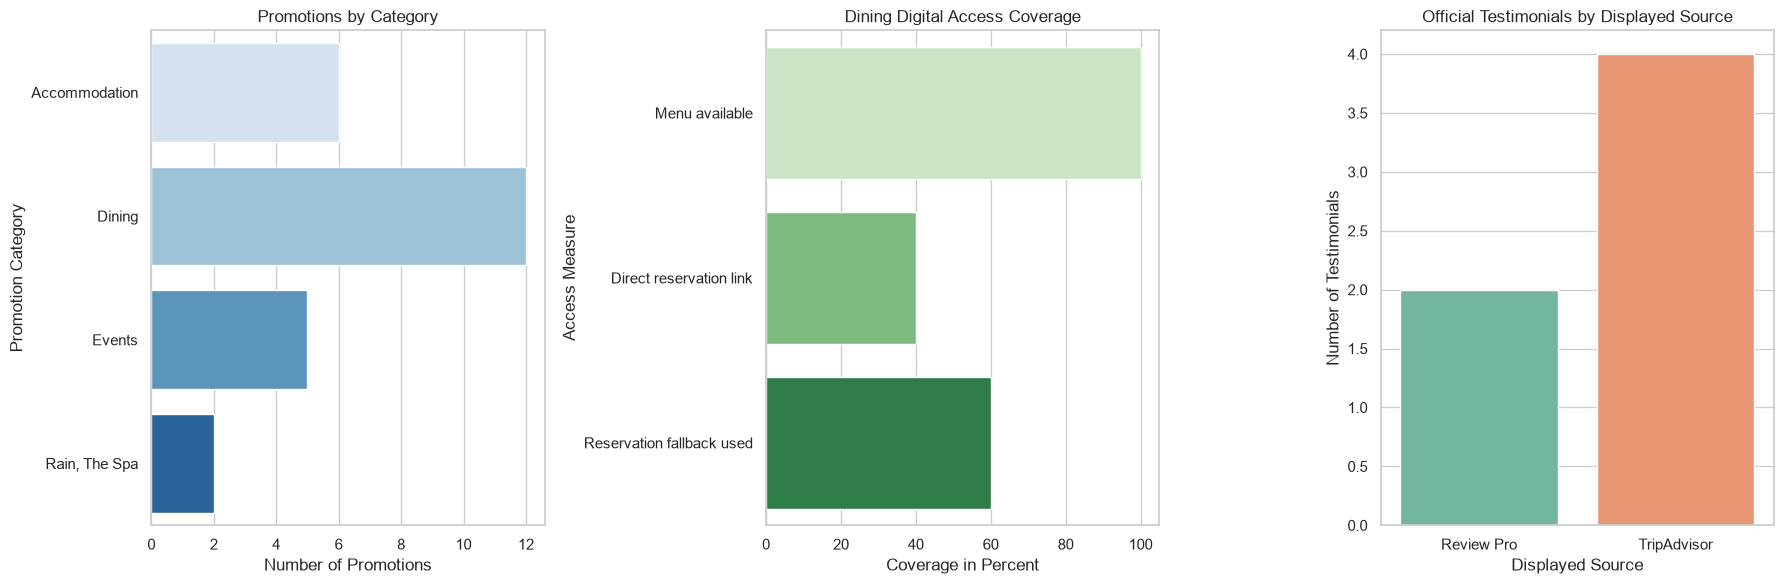

In [81]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

sns.barplot(
    data=promotion_category_summary_df,
    x="promotions",
    y="promotion_category",
    hue="promotion_category",
    legend=False,
    ax=axes[0],
    palette="Blues"
)

axes[0].set_title(
    "Promotions by Category"
)

axes[0].set_xlabel(
    "Number of Promotions"
)

axes[0].set_ylabel(
    "Promotion Category"
)

sns.barplot(
    data=dining_access_summary_df,
    x="coverage_percent",
    y="access_measure",
    hue="access_measure",
    legend=False,
    ax=axes[1],
    palette="Greens"
)

axes[1].set_title(
    "Dining Digital Access Coverage"
)

axes[1].set_xlabel(
    "Coverage in Percent"
)

axes[1].set_ylabel(
    "Access Measure"
)

sns.barplot(
    data=review_source_summary_df,
    x="displayed_source",
    y="testimonials",
    hue="displayed_source",
    legend=False,
    ax=axes[2],
    palette="Set2"
)

axes[2].set_title(
    "Official Testimonials by Displayed Source"
)

axes[2].set_xlabel(
    "Displayed Source"
)

axes[2].set_ylabel(
    "Number of Testimonials"
)

plt.tight_layout()
plt.show()

## Digital Access and Testimonial Coverage

The official website displays 25 promotions. Accommodation has six promotions with complete direct details and action link coverage.

Dining contains the largest number of promotions at 12, but only 33.33 percent have direct details links and 25 percent have direct action links. Events have complete action link coverage, while Rain, The Spa has complete action coverage but only 50 percent direct details coverage.

All five dining outlets provide menu links. Only two outlets provide direct reservation links, while three direct customers to the general Dining page.

The official website displays six curated testimonials. Four are attributed to TripAdvisor and two to Review Pro. Four of the six excerpts are truncated, and one reviewer location is not displayed.

### Statistical Interpretation

The results measure website content coverage rather than customer behavior. Accommodation promotions have the strongest digital path, while Dining has the largest gap between the number of offers and direct customer links.

The testimonial sample is too small, selected, and incomplete for estimating overall satisfaction, sentiment, or review source performance.

### Business Implication

Dining promotions may lose potential conversions when customers cannot move directly from an offer to complete details or a reservation action. Direct links should be added wherever an active booking or information page exists.

Dining outlets without dedicated reservation links may benefit from a consistent reservation form or booking system.

The six testimonials can support website storytelling, but they should not be used as evidence of general guest satisfaction. A larger independent review dataset with ratings, dates, and complete text would be required for reliable reputation analysis.

In [82]:
review_files = sorted(
    clean_data_folder.glob(
        "*review*_clean.csv"
    )
)

print(
    "Clean review files found:",
    len(
        review_files
    )
)

for review_file in review_files:
    review_check_df = pd.read_csv(
        review_file
    )

    print()
    print(
        "File:",
        review_file.name
    )

    print(
        "Shape:",
        review_check_df.shape
    )

    print(
        "Columns:"
    )

    print(
        review_check_df.columns.tolist()
    )

Clean review files found: 1

File: taal_vista_official_reviews_clean.csv
Shape: (6, 10)
Columns:
['review_record_id', 'displayed_source', 'review_title', 'review_excerpt', 'reviewer_name', 'reviewer_location', 'excerpt_truncated', 'source_context', 'source_url', 'date_collected']


In [88]:
google_reviews_file = (
    clean_data_folder
    / "taal_vista_google_reviews_clean.csv"
)

google_reviews_df = pd.read_csv(
    google_reviews_file
)

google_reviews_df[
    "estimated_review_date"
] = pd.to_datetime(
    google_reviews_df[
        "estimated_review_date"
    ],
    errors="coerce"
)

google_reviews_df[
    "date_collected"
] = pd.to_datetime(
    google_reviews_df[
        "date_collected"
    ],
    errors="coerce"
)

eda_dataframes[
    "google_reviews"
] = google_reviews_df

print(
    "Google reviews loaded:",
    google_reviews_df.shape
)

print(
    "EDA datasets:",
    len(
        eda_dataframes
    )
)

print(
    "Total EDA rows:",
    sum(
        current_df.shape[0]
        for current_df
        in eda_dataframes.values()
    )
)

print(
    "Missing ratings:",
    google_reviews_df[
        "rating"
    ].isna().sum()
)

print(
    "Duplicate review IDs:",
    google_reviews_df[
        "review_id"
    ].duplicated().sum()
)

Google reviews loaded: (4227, 17)
EDA datasets: 15
Total EDA rows: 4504
Missing ratings: 0
Duplicate review IDs: 0


## Expanded Google Review Dataset

A separate cleaned Google review dataset was added after the initial EDA files were loaded.

The expanded analytical collection now contains 15 datasets and 4,504 total records. The Google review dataset contributes 4,227 valid rating records with no missing ratings or duplicate review identifiers.

The six official website testimonials remain separate because they are curated excerpts with a different structure and purpose.

In [89]:
google_rating_summary_df = pd.DataFrame({
    "metric": [
        "Reviews",
        "Average rating",
        "Median rating",
        "Most common rating",
        "Standard deviation",
        "Minimum rating",
        "Maximum rating",
        "Written reviews",
        "Owner replies"
    ],
    "value": [
        len(
            google_reviews_df
        ),
        google_reviews_df[
            "rating"
        ].mean(),
        google_reviews_df[
            "rating"
        ].median(),
        google_reviews_df[
            "rating"
        ].mode().iloc[0],
        google_reviews_df[
            "rating"
        ].std(),
        google_reviews_df[
            "rating"
        ].min(),
        google_reviews_df[
            "rating"
        ].max(),
        google_reviews_df[
            "review_text_clean"
        ].notna().sum(),
        google_reviews_df[
            "has_owner_reply"
        ].sum()
    ]
})

display(
    google_rating_summary_df.round(2)
)

,metric,value
0,Reviews,"4,227.00"
1,Average rating,4.44
2,Median rating,5.00
3,Most common rating,5.00
4,Standard deviation,0.90
5,Minimum rating,1.00
6,Maximum rating,5.00
7,Written reviews,138.00
8,Owner replies,"2,851.00"


In [90]:
google_rating_distribution_df = (
    google_reviews_df[
        "rating"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "rating"
    )
    .reset_index(
        name="reviews"
    )
)

google_rating_distribution_df[
    "percentage"
] = (
    google_rating_distribution_df[
        "reviews"
    ]
    / len(
        google_reviews_df
    )
    * 100
)

display(
    google_rating_distribution_df.round(2)
)

print(
    "Written review coverage:",
    round(
        google_reviews_df[
            "review_text_clean"
        ].notna().mean()
        * 100,
        2
    )
)

print(
    "Owner reply coverage:",
    round(
        google_reviews_df[
            "has_owner_reply"
        ].mean()
        * 100,
        2
    )
)

print(
    "Estimated review date coverage:",
    round(
        google_reviews_df[
            "estimated_review_date"
        ].notna().mean()
        * 100,
        2
    )
)

,rating,reviews,percentage
0,1.00,112,2.65
1,2.00,74,1.75
2,3.00,316,7.48
3,4.00,1083,25.62
4,5.00,2642,62.50


Written review coverage: 3.26
Owner reply coverage: 67.45
Estimated review date coverage: 67.45


In [91]:
google_reviews_df[
    "rating_group"
] = pd.cut(
    google_reviews_df[
        "rating"
    ],
    bins=[
        0,
        2,
        3,
        5
    ],
    labels=[
        "Low rating",
        "Neutral rating",
        "High rating"
    ]
)

google_rating_group_df = (
    google_reviews_df[
        "rating_group"
    ]
    .value_counts()
    .reindex(
        [
            "Low rating",
            "Neutral rating",
            "High rating"
        ]
    )
    .rename_axis(
        "rating_group"
    )
    .reset_index(
        name="reviews"
    )
)

google_rating_group_df[
    "percentage"
] = (
    google_rating_group_df[
        "reviews"
    ]
    / len(
        google_reviews_df
    )
    * 100
)

display(
    google_rating_group_df.round(2)
)

,rating_group,reviews,percentage
0,Low rating,186,4.40
1,Neutral rating,316,7.48
2,High rating,3725,88.12


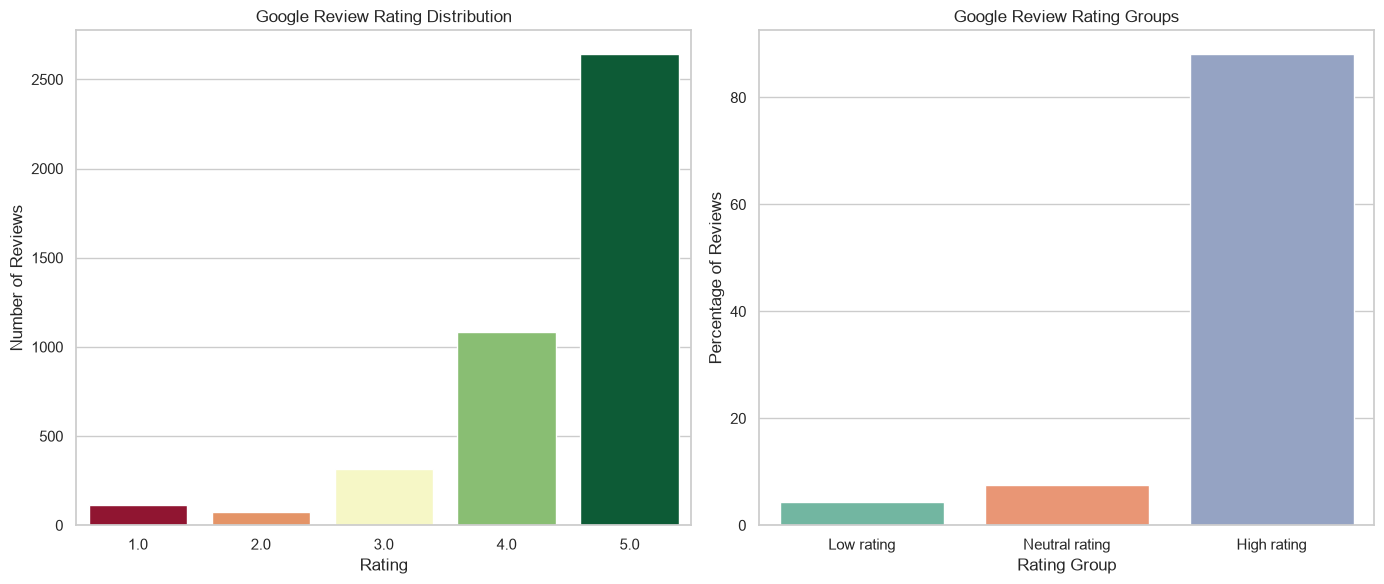

In [92]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

sns.barplot(
    data=google_rating_distribution_df,
    x="rating",
    y="reviews",
    hue="rating",
    legend=False,
    ax=axes[0],
    palette="RdYlGn"
)

axes[0].set_title(
    "Google Review Rating Distribution"
)

axes[0].set_xlabel(
    "Rating"
)

axes[0].set_ylabel(
    "Number of Reviews"
)

sns.barplot(
    data=google_rating_group_df,
    x="rating_group",
    y="percentage",
    hue="rating_group",
    legend=False,
    ax=axes[1],
    palette="Set2"
)

axes[1].set_title(
    "Google Review Rating Groups"
)

axes[1].set_xlabel(
    "Rating Group"
)

axes[1].set_ylabel(
    "Percentage of Reviews"
)

plt.tight_layout()
plt.show()

## Google Review Rating Profile

The cleaned Google review dataset contains 4,227 valid rating records.

The average rating is 4.44, while both the median and most common rating are 5. Ratings of five account for 62.50 percent of records, followed by four star ratings at 25.62 percent.

Using the defined rating groups, 88.12 percent are high ratings, 7.48 percent are neutral, and 4.40 percent are low.

Only 138 records, equivalent to 3.26 percent, contain written review text.

### Statistical Interpretation

The rating distribution is concentrated near the upper limit of the five point scale. The median and mode of five indicate a strong ceiling effect.

The mean remains useful as a summary but should not be interpreted as normally distributed continuous data because ratings are bounded and ordinal.

The written review subset is much smaller than the rating dataset. Text findings may not reflect the experience of reviewers who submitted ratings without written comments.

### Business Implication

The observed rating profile indicates strong customer evaluation on Google. Maintaining the high proportion of four and five star ratings is important for hotel reputation and booking consideration.

Low ratings account for only 4.40 percent, but these records remain valuable for identifying service recovery priorities.

Management should not assume that written comments represent all reviewers because only 3.26 percent of the cleaned records contain text.

In [93]:
google_reviews_df[
    "has_estimated_date"
] = (
    google_reviews_df[
        "estimated_review_date"
    ].notna()
)

date_reply_cross_table = pd.crosstab(
    google_reviews_df[
        "has_estimated_date"
    ],
    google_reviews_df[
        "has_owner_reply"
    ],
    margins=True
)

display(
    date_reply_cross_table
)

print(
    "Date and reply indicators always match:",
    google_reviews_df[
        "has_estimated_date"
    ].eq(
        google_reviews_df[
            "has_owner_reply"
        ]
    ).all()
)

display(
    google_reviews_df.groupby(
        [
            "has_estimated_date",
            "has_owner_reply"
        ]
    )[
        "rating"
    ]
    .agg(
        reviews="count",
        average_rating="mean",
        median_rating="median"
    )
    .reset_index()
    .round(2)
)

has_owner_reply,False,True,All
has_estimated_date,,,
False,1376,0,1376
True,0,2851,2851
All,1376,2851,4227


Date and reply indicators always match: True


,has_estimated_date,has_owner_reply,reviews,average_rating,median_rating
0,False,False,1376,4.40,5.00
1,True,True,2851,4.45,5.00


In [94]:
google_rating_q1 = (
    google_reviews_df[
        "rating"
    ].quantile(
        0.25
    )
)

google_rating_q3 = (
    google_reviews_df[
        "rating"
    ].quantile(
        0.75
    )
)

google_rating_iqr = (
    google_rating_q3
    - google_rating_q1
)

google_rating_lower_bound = (
    google_rating_q1
    - 1.5 * google_rating_iqr
)

google_rating_upper_bound = (
    google_rating_q3
    + 1.5 * google_rating_iqr
)

google_reviews_df[
    "rating_outlier"
] = (
    google_reviews_df[
        "rating"
    ] < google_rating_lower_bound
) | (
    google_reviews_df[
        "rating"
    ] > google_rating_upper_bound
)

print(
    "First quartile:",
    google_rating_q1
)

print(
    "Third quartile:",
    google_rating_q3
)

print(
    "Interquartile range:",
    google_rating_iqr
)

print(
    "Lower boundary:",
    google_rating_lower_bound
)

print(
    "Upper boundary:",
    google_rating_upper_bound
)

print(
    "Rating outliers:",
    google_reviews_df[
        "rating_outlier"
    ].sum()
)

print(
    "Outliers by rating:"
)

print(
    google_reviews_df.loc[
        google_reviews_df[
            "rating_outlier"
        ],
        "rating"
    ].value_counts().sort_index()
)

First quartile: 4.0
Third quartile: 5.0
Interquartile range: 1.0
Lower boundary: 2.5
Upper boundary: 6.5
Rating outliers: 186
Outliers by rating:
rating
1.00    112
2.00     74
Name: count, dtype: int64


### Google Review Completeness and Rating Outliers

Estimated review dates and owner reply indicators match perfectly across all 4,227 records.

All 2,851 records with estimated dates also contain owner replies. All 1,376 records without estimated dates also lack owner replies.

The average rating is 4.45 among records with both fields and 4.40 among records without them.

Using the interquartile range method, ratings below 2.5 are classified as statistical outliers. This identifies 186 low ratings, consisting of 112 one star and 74 two star reviews.

### Statistical Interpretation

The perfect relationship between date availability and owner reply availability indicates a likely extraction dependency. These variables were probably captured together from detailed webpage elements.

The observed 67.45 percent owner reply coverage should not be interpreted as the hotel’s true response rate because missing replies may represent incomplete extraction rather than an absence of management response.

One and two star ratings are statistical outliers relative to the highly positive distribution, but they are valid observations and must not be removed.

### Business Implication

The hotel’s response performance cannot be reliably evaluated using this extraction. A future scraper should independently capture review dates and owner responses for every visible review.

Low ratings represent only 4.40 percent of records, but they are especially important for service recovery. Removing them would hide the customer experiences most relevant for operational improvement.

In [95]:
google_shapiro_statistic, google_shapiro_p_value = (
    stats.shapiro(
        google_reviews_df[
            "rating"
        ]
    )
)

google_rating_skewness = stats.skew(
    google_reviews_df[
        "rating"
    ],
    bias=False
)

google_rating_kurtosis = stats.kurtosis(
    google_reviews_df[
        "rating"
    ],
    fisher=True,
    bias=False
)

print(
    "Shapiro Wilk statistic:",
    round(
        google_shapiro_statistic,
        4
    )
)

print(
    "Shapiro Wilk p value:",
    f"{google_shapiro_p_value:.10e}"
)

print(
    "Skewness:",
    round(
        google_rating_skewness,
        4
    )
)

print(
    "Excess kurtosis:",
    round(
        google_rating_kurtosis,
        4
    )
)

print(
    "Alpha level:",
    0.05
)

if google_shapiro_p_value < 0.05:
    print(
        "Decision: Reject the null hypothesis"
    )
    print(
        "Conclusion: Ratings are not normally distributed"
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis"
    )
    print(
        "Conclusion: Normality was not rejected"
    )

Shapiro Wilk statistic: 0.6551
Shapiro Wilk p value: 1.4148921999e-68
Skewness: -1.9698
Excess kurtosis: 4.0217
Alpha level: 0.05
Decision: Reject the null hypothesis
Conclusion: Ratings are not normally distributed


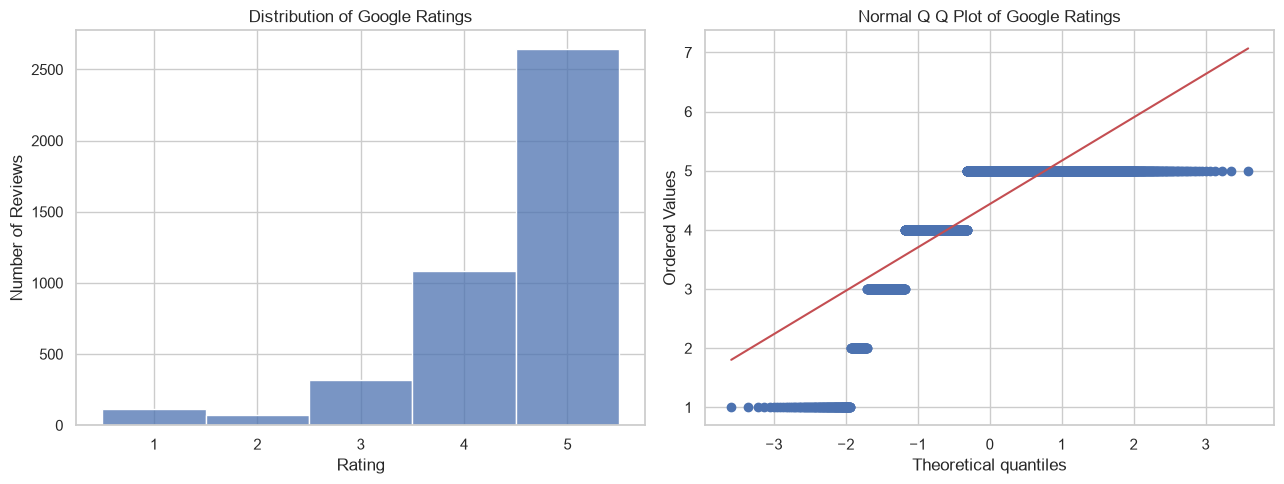

In [96]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

sns.histplot(
    data=google_reviews_df,
    x="rating",
    discrete=True,
    ax=axes[0],
    color="#4C72B0"
)

axes[0].set_title(
    "Distribution of Google Ratings"
)

axes[0].set_xlabel(
    "Rating"
)

axes[0].set_ylabel(
    "Number of Reviews"
)

stats.probplot(
    google_reviews_df[
        "rating"
    ],
    dist="norm",
    plot=axes[1]
)

axes[1].set_title(
    "Normal Q Q Plot of Google Ratings"
)

plt.tight_layout()
plt.show()

### Google Rating Normality

The Shapiro Wilk statistic was 0.6551, with a p value of approximately 1.41 times 10 to the power of negative 68.

At the 0.05 alpha level, the null hypothesis of normality was rejected.

The rating distribution has a skewness of negative 1.9698 and excess kurtosis of 4.0217.

### Statistical Interpretation

Google ratings are strongly negatively skewed because most observations are concentrated at four and five stars, with a smaller tail extending toward low ratings.

The distribution is not normal. This result is expected because ratings are discrete, ordinal, bounded between one and five, and affected by a ceiling at five.

The median and rating proportions are more appropriate descriptive measures than relying only on the mean.

### Business Implication

The concentration of ratings at the upper end reflects a strong observed reputation profile. However, the small number of low ratings should still be examined because they may identify recurring service failures hidden by the high overall average.

Statistical comparisons involving ratings should use methods suitable for ordinal or categorical outcomes.

In [97]:
high_rating_count = (
    google_reviews_df[
        "rating_group"
    ].eq(
        "High rating"
    ).sum()
)

total_rating_count = len(
    google_reviews_df
)

high_rating_proportion = (
    high_rating_count
    / total_rating_count
)

high_rating_benchmark = 0.80

high_rating_test = stats.binomtest(
    high_rating_count,
    n=total_rating_count,
    p=high_rating_benchmark,
    alternative="greater"
)

high_rating_confidence_interval = (
    high_rating_test.proportion_ci(
        confidence_level=0.95,
        method="wilson"
    )
)

high_rating_cohens_h = (
    2
    * np.arcsin(
        np.sqrt(
            high_rating_proportion
        )
    )
    - 2
    * np.arcsin(
        np.sqrt(
            high_rating_benchmark
        )
    )
)

print(
    "High ratings:",
    high_rating_count
)

print(
    "Total ratings:",
    total_rating_count
)

print(
    "Observed high rating proportion:",
    round(
        high_rating_proportion,
        4
    )
)

print(
    "Benchmark proportion:",
    high_rating_benchmark
)

print(
    "Exact binomial p value:",
    f"{high_rating_test.pvalue:.10e}"
)

print(
    "Confidence interval lower bound:",
    round(
        high_rating_confidence_interval.low,
        4
    )
)

print(
    "Confidence interval upper bound:",
    round(
        high_rating_confidence_interval.high,
        4
    )
)

print(
    "Cohen h:",
    round(
        high_rating_cohens_h,
        4
    )
)

High ratings: 3725
Total ratings: 4227
Observed high rating proportion: 0.8812
Benchmark proportion: 0.8
Exact binomial p value: 6.0222328511e-45
Confidence interval lower bound: 0.8728
Confidence interval upper bound: 1.0
Cohen h: 0.2236


In [98]:
high_rating_upper_critical_value = next(
    rating_count
    for rating_count in range(
        total_rating_count + 1
    )
    if stats.binom.sf(
        rating_count - 1,
        total_rating_count,
        high_rating_benchmark
    ) <= 0.05
)

print(
    "Lower critical value:",
    "Not applicable for this upper tailed test"
)

print(
    "Upper critical value:",
    high_rating_upper_critical_value
)

print(
    "Observed high rating count:",
    high_rating_count
)

print(
    "Rejection region:",
    (
        "High rating count is at least "
        f"{high_rating_upper_critical_value}"
    )
)

if high_rating_test.pvalue < 0.05:
    print(
        "Decision: Reject the null hypothesis"
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis"
    )

Lower critical value: Not applicable for this upper tailed test
Upper critical value: 3425
Observed high rating count: 3725
Rejection region: High rating count is at least 3425
Decision: Reject the null hypothesis


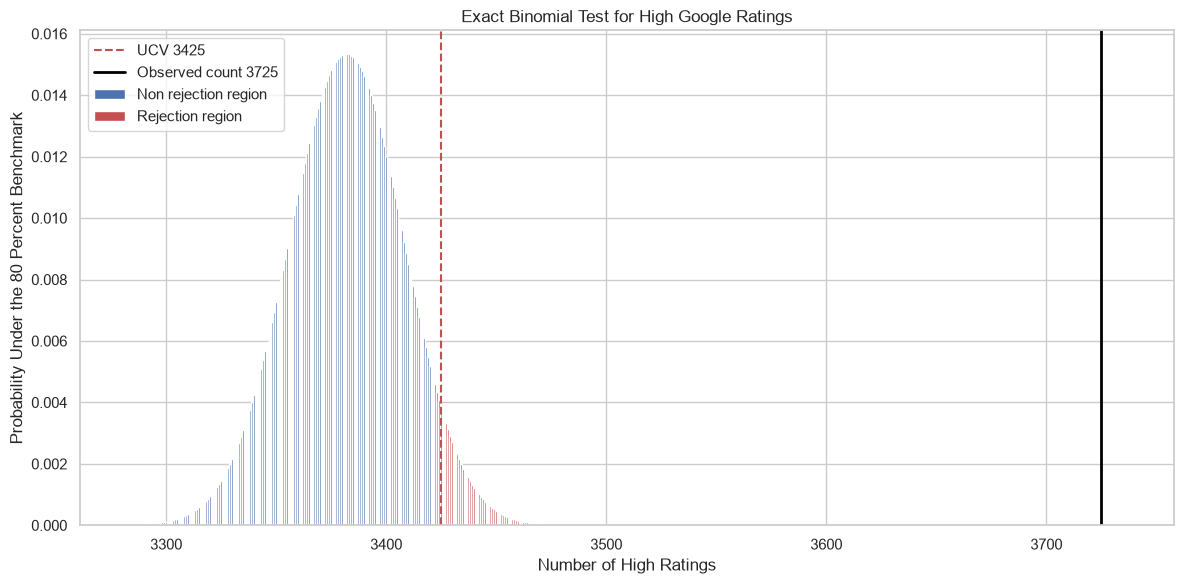

In [99]:
lower_plot_count = int(
    stats.binom.ppf(
        0.0001,
        total_rating_count,
        high_rating_benchmark
    )
)

upper_plot_count = (
    high_rating_count
    + 10
)

high_rating_counts = np.arange(
    lower_plot_count,
    upper_plot_count + 1
)

high_rating_null_probabilities = stats.binom.pmf(
    high_rating_counts,
    total_rating_count,
    high_rating_benchmark
)

high_rating_rejection_mask = (
    high_rating_counts
    >= high_rating_upper_critical_value
)

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    high_rating_counts[
        ~high_rating_rejection_mask
    ],
    high_rating_null_probabilities[
        ~high_rating_rejection_mask
    ],
    color="#4C72B0",
    label="Non rejection region"
)

plt.bar(
    high_rating_counts[
        high_rating_rejection_mask
    ],
    high_rating_null_probabilities[
        high_rating_rejection_mask
    ],
    color="#C44E52",
    label="Rejection region"
)

plt.axvline(
    high_rating_upper_critical_value,
    color="#C44E52",
    linestyle="--",
    label=(
        "UCV "
        f"{high_rating_upper_critical_value}"
    )
)

plt.axvline(
    high_rating_count,
    color="black",
    linewidth=2,
    label=(
        "Observed count "
        f"{high_rating_count}"
    )
)

plt.title(
    "Exact Binomial Test for High Google Ratings"
)

plt.xlabel(
    "Number of High Ratings"
)

plt.ylabel(
    "Probability Under the 80 Percent Benchmark"
)

plt.legend()
plt.tight_layout()
plt.show()

### High Google Rating Probability

High ratings account for 88.12 percent of the 4,227 valid Google rating records.

The exact binomial test compared this result with an analytical benchmark of 80 percent. The observed count of 3,725 high ratings exceeded the upper critical value of 3,425.

The p value was approximately 6.02 times 10 to the power of negative 45. The null hypothesis was rejected.

The one sided 95 percent confidence interval has a lower bound of 87.28 percent. Cohen h was 0.2236, indicating a small effect.

### Statistical Interpretation

There is statistically significant evidence that the high rating proportion exceeds the selected 80 percent benchmark.

The very small p value is influenced by the large sample size. The effect size provides the practical context: the observed proportion is meaningfully but not dramatically above the benchmark.

The benchmark was selected for this analysis and is not an official Google performance standard.

### Business Implication

The hotel has a strong observed Google rating profile, with the high rating proportion exceeding the project benchmark by 8.12 percentage points.

Management should focus on preserving this performance while investigating the 186 low ratings for recurring operational issues. Small declines in the high rating proportion could affect the public rating because most current records are concentrated at the upper end.

In [100]:
reviewer_type_df = (
    google_reviews_df[
        google_reviews_df[
            "is_local_guide"
        ].notna()
    ]
    .copy()
)

reviewer_type_df[
    "reviewer_type"
] = np.where(
    reviewer_type_df[
        "is_local_guide"
    ].eq(
        True
    ),
    "Local Guide",
    "Other Reviewer"
)

reviewer_rating_summary_df = (
    reviewer_type_df.groupby(
        "reviewer_type"
    )
    .agg(
        reviews=(
            "rating",
            "count"
        ),
        average_rating=(
            "rating",
            "mean"
        ),
        median_rating=(
            "rating",
            "median"
        ),
        high_ratings=(
            "rating_group",
            lambda values: (
                values
                == "High rating"
            ).sum()
        ),
        low_ratings=(
            "rating_group",
            lambda values: (
                values
                == "Low rating"
            ).sum()
        )
    )
    .reset_index()
)

reviewer_rating_summary_df[
    "high_rating_percent"
] = (
    reviewer_rating_summary_df[
        "high_ratings"
    ]
    / reviewer_rating_summary_df[
        "reviews"
    ]
    * 100
)

reviewer_rating_summary_df[
    "low_rating_percent"
] = (
    reviewer_rating_summary_df[
        "low_ratings"
    ]
    / reviewer_rating_summary_df[
        "reviews"
    ]
    * 100
)

display(
    reviewer_rating_summary_df.round(2)
)

print(
    "Records excluded because reviewer type is missing:",
    google_reviews_df[
        "is_local_guide"
    ].isna().sum()
)

,reviewer_type,reviews,average_rating,median_rating,high_ratings,low_ratings,high_rating_percent,low_rating_percent
0,Local Guide,2834,4.45,5.00,2516,89,88.78,3.14
1,Other Reviewer,1059,4.38,5.00,913,80,86.21,7.55


Records excluded because reviewer type is missing: 334


,reviewer_type,rating,reviews,percentage_within_reviewer_type
0,Local Guide,1.00,39,1.38
1,Local Guide,2.00,50,1.76
2,Local Guide,3.00,229,8.08
3,Local Guide,4.00,792,27.95
4,Local Guide,5.00,1724,60.83
5,Other Reviewer,1.00,63,5.95
6,Other Reviewer,2.00,17,1.61
7,Other Reviewer,3.00,66,6.23
8,Other Reviewer,4.00,225,21.25
9,Other Reviewer,5.00,688,64.97


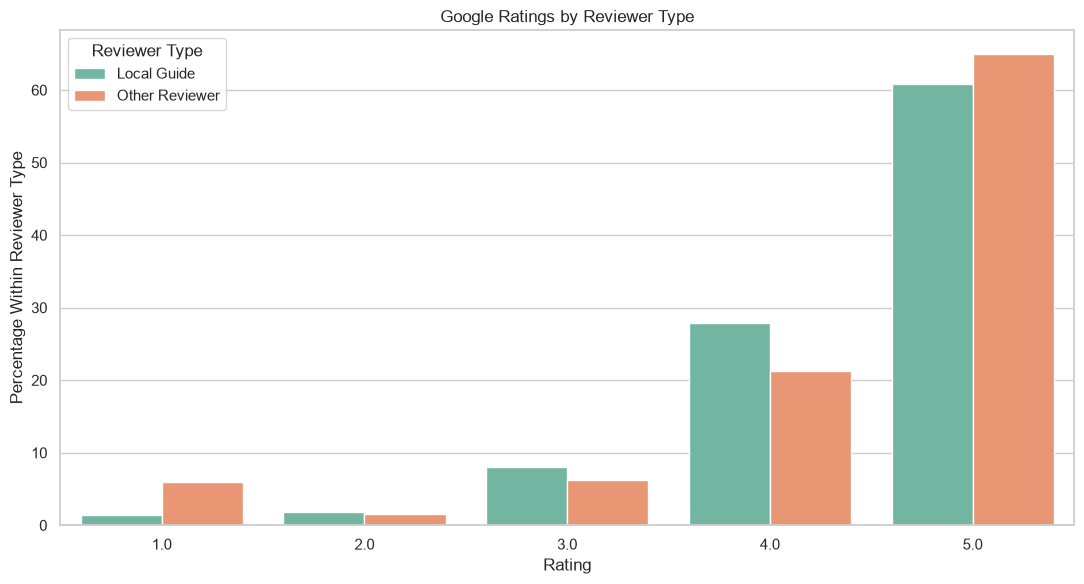

In [101]:
reviewer_rating_distribution_df = (
    reviewer_type_df.groupby(
        [
            "reviewer_type",
            "rating"
        ]
    )
    .size()
    .reset_index(
        name="reviews"
    )
)

reviewer_rating_distribution_df[
    "percentage_within_reviewer_type"
] = (
    reviewer_rating_distribution_df[
        "reviews"
    ]
    / reviewer_rating_distribution_df.groupby(
        "reviewer_type"
    )[
        "reviews"
    ]
    .transform(
        "sum"
    )
    * 100
)

display(
    reviewer_rating_distribution_df.round(2)
)

plt.figure(
    figsize=(11, 6)
)

sns.barplot(
    data=reviewer_rating_distribution_df,
    x="rating",
    y="percentage_within_reviewer_type",
    hue="reviewer_type",
    palette="Set2"
)

plt.title(
    "Google Ratings by Reviewer Type"
)

plt.xlabel(
    "Rating"
)

plt.ylabel(
    "Percentage Within Reviewer Type"
)

plt.legend(
    title="Reviewer Type"
)

plt.tight_layout()
plt.show()

### Google Ratings by Reviewer Type

Local Guides have an average rating of 4.45, while other identified reviewers average 4.38. Both groups have a median rating of five.

High ratings account for 88.78 percent of Local Guide reviews and 86.21 percent of other reviewer ratings.

Low ratings account for 3.14 percent of Local Guide reviews and 7.55 percent of other reviewer ratings.

A total of 334 records were excluded because reviewer information was unavailable.

### Statistical Interpretation

The descriptive results show a 2.57 percentage point difference in high rating proportions. Other reviewers also have a higher proportion of one star ratings, while Local Guides have a higher concentration of four star ratings.

A formal proportion test is required to determine whether the observed high rating difference is statistically distinguishable from zero.

### Business Implication

Both reviewer groups provide predominantly positive ratings. However, other reviewers contribute a larger share of low ratings and may reveal different service expectations or reporting behavior.

Reviewer type should not be treated as a cause of rating differences because review experience, visit timing, customer expectations, and missing reviewer information may also influence the pattern.

In [102]:
local_guide_summary = (
    reviewer_rating_summary_df[
        reviewer_rating_summary_df[
            "reviewer_type"
        ].eq(
            "Local Guide"
        )
    ].iloc[0]
)

other_reviewer_summary = (
    reviewer_rating_summary_df[
        reviewer_rating_summary_df[
            "reviewer_type"
        ].eq(
            "Other Reviewer"
        )
    ].iloc[0]
)

local_high_count = int(
    local_guide_summary[
        "high_ratings"
    ]
)

local_total_count = int(
    local_guide_summary[
        "reviews"
    ]
)

other_high_count = int(
    other_reviewer_summary[
        "high_ratings"
    ]
)

other_total_count = int(
    other_reviewer_summary[
        "reviews"
    ]
)

local_high_proportion = (
    local_high_count
    / local_total_count
)

other_high_proportion = (
    other_high_count
    / other_total_count
)

pooled_high_proportion = (
    local_high_count
    + other_high_count
) / (
    local_total_count
    + other_total_count
)

pooled_standard_error = np.sqrt(
    pooled_high_proportion
    * (
        1
        - pooled_high_proportion
    )
    * (
        1 / local_total_count
        + 1 / other_total_count
    )
)

reviewer_z_statistic = (
    local_high_proportion
    - other_high_proportion
) / pooled_standard_error

reviewer_p_value = (
    2
    * stats.norm.sf(
        abs(
            reviewer_z_statistic
        )
    )
)

proportion_difference = (
    local_high_proportion
    - other_high_proportion
)

unpooled_standard_error = np.sqrt(
    local_high_proportion
    * (
        1
        - local_high_proportion
    )
    / local_total_count
    + other_high_proportion
    * (
        1
        - other_high_proportion
    )
    / other_total_count
)

reviewer_confidence_interval = (
    proportion_difference
    - 1.96 * unpooled_standard_error,
    proportion_difference
    + 1.96 * unpooled_standard_error
)

reviewer_cohens_h = (
    2
    * np.arcsin(
        np.sqrt(
            local_high_proportion
        )
    )
    - 2
    * np.arcsin(
        np.sqrt(
            other_high_proportion
        )
    )
)

print(
    "Difference in high rating proportions:",
    round(
        proportion_difference,
        4
    )
)

print(
    "Z statistic:",
    round(
        reviewer_z_statistic,
        4
    )
)

print(
    "P value:",
    round(
        reviewer_p_value,
        4
    )
)

print(
    "Lower critical value:",
    -1.96
)

print(
    "Upper critical value:",
    1.96
)

print(
    "Confidence interval:",
    tuple(
        round(
            value,
            4
        )
        for value
        in reviewer_confidence_interval
    )
)

print(
    "Cohen h:",
    round(
        reviewer_cohens_h,
        4
    )
)

if reviewer_p_value < 0.05:
    print(
        "Decision: Reject the null hypothesis"
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis"
    )

Difference in high rating proportions: 0.0257
Z statistic: 2.1986
P value: 0.0279
Lower critical value: -1.96
Upper critical value: 1.96
Confidence interval: (np.float64(0.0019), np.float64(0.0495))
Cohen h: 0.0777
Decision: Reject the null hypothesis


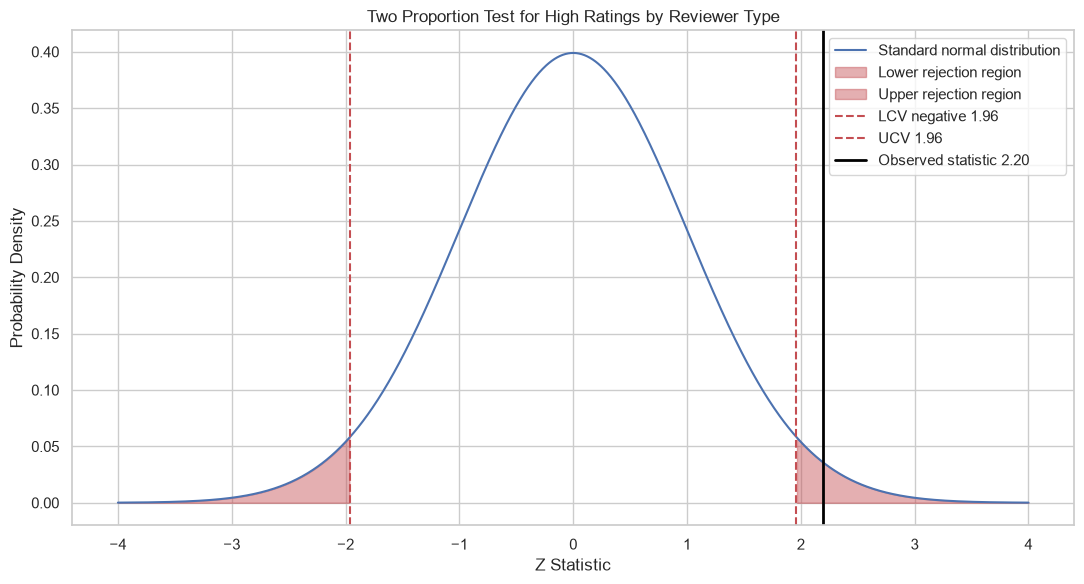

In [103]:
reviewer_z_values = np.linspace(
    -4,
    4,
    1000
)

reviewer_z_density = stats.norm.pdf(
    reviewer_z_values
)

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    reviewer_z_values,
    reviewer_z_density,
    color="#4C72B0",
    label="Standard normal distribution"
)

plt.fill_between(
    reviewer_z_values,
    reviewer_z_density,
    where=(
        reviewer_z_values
        <= -1.96
    ),
    color="#C44E52",
    alpha=0.45,
    label="Lower rejection region"
)

plt.fill_between(
    reviewer_z_values,
    reviewer_z_density,
    where=(
        reviewer_z_values
        >= 1.96
    ),
    color="#C44E52",
    alpha=0.45,
    label="Upper rejection region"
)

plt.axvline(
    -1.96,
    color="#C44E52",
    linestyle="--",
    label="LCV negative 1.96"
)

plt.axvline(
    1.96,
    color="#C44E52",
    linestyle="--",
    label="UCV 1.96"
)

plt.axvline(
    reviewer_z_statistic,
    color="black",
    linewidth=2,
    label=(
        "Observed statistic "
        f"{reviewer_z_statistic:.2f}"
    )
)

plt.title(
    "Two Proportion Test for High Ratings by Reviewer Type"
)

plt.xlabel(
    "Z Statistic"
)

plt.ylabel(
    "Probability Density"
)

plt.legend()
plt.tight_layout()
plt.show()

### High Ratings by Reviewer Type

A two-proportion z-test was used to compare the proportion of high ratings
between Local Guides and other reviewers.

Local Guides had a high-rating proportion of 88.78%, compared with 86.21%
among other reviewers. The estimated difference was 2.57 percentage points.

The observed z statistic of 2.1986 exceeded the upper critical value of 1.96.
The p value was 0.0279, which was below the 0.05 significance level.
Therefore, the null hypothesis was rejected.

The 95% confidence interval indicated that the Local Guide high-rating
proportion was approximately 0.19 to 4.95 percentage points higher.

However, Cohen's h was 0.0777, indicating a negligible practical effect.
Although the difference was statistically significant, the two reviewer
groups displayed broadly similar levels of positive ratings. The significant
result was partly supported by the large sample size.

A total of 334 reviews with missing reviewer-type information were excluded
from this comparison.

### Business Implication

The hotel does not need separate service strategies for Local Guides and
other reviewers based on this small difference. Both groups report similarly
high satisfaction. Management should focus on the specific concerns found in
low-rated and written reviews rather than reviewer classification alone.

In [104]:
written_review_coverage_df = (
    google_reviews_df.groupby(
        "rating"
    )
    .agg(
        total_reviews=(
            "review_id",
            "count"
        ),
        written_reviews=(
            "review_text_clean",
            "count"
        )
    )
    .reset_index()
)

written_review_coverage_df[
    "written_review_percent"
] = (
    written_review_coverage_df[
        "written_reviews"
    ]
    / written_review_coverage_df[
        "total_reviews"
    ]
    * 100
)

display(
    written_review_coverage_df.round(2)
)

print(
    "Total written reviews:",
    written_review_coverage_df[
        "written_reviews"
    ].sum()
)

print(
    "Overall written review coverage:",
    round(
        google_reviews_df[
            "review_text_clean"
        ].notna().mean()
        * 100,
        2
    )
)

,rating,total_reviews,written_reviews,written_review_percent
0,1.00,112,10,8.93
1,2.00,74,7,9.46
2,3.00,316,14,4.43
3,4.00,1083,25,2.31
4,5.00,2642,82,3.10


Total written reviews: 138
Overall written review coverage: 3.26


In [105]:
google_reviews_df[
    "written_review_available"
] = google_reviews_df[
    "review_text_clean"
].notna()

written_review_table = pd.crosstab(
    google_reviews_df["rating"],
    google_reviews_df[
        "written_review_available"
    ]
)

display(written_review_table)

chi_square_statistic, chi_square_p_value, \
degrees_of_freedom, expected_frequencies = (
    stats.chi2_contingency(
        written_review_table
    )
)

expected_frequencies_df = pd.DataFrame(
    expected_frequencies,
    index=written_review_table.index,
    columns=written_review_table.columns
)

number_of_reviews = (
    written_review_table.to_numpy().sum()
)

minimum_dimension = min(
    written_review_table.shape[0] - 1,
    written_review_table.shape[1] - 1
)

cramers_v = np.sqrt(
    chi_square_statistic
    / (
        number_of_reviews
        * minimum_dimension
    )
)

alpha_level = 0.05

lower_critical_value = (
    "Not applicable for this upper tailed test"
)

upper_critical_value = stats.chi2.ppf(
    1 - alpha_level,
    degrees_of_freedom
)

print(
    "Chi square statistic:",
    round(
        chi_square_statistic,
        4
    )
)

print(
    "P value:",
    format(
        chi_square_p_value,
        ".10f"
    )
)

print(
    "Degrees of freedom:",
    degrees_of_freedom
)

print(
    "Alpha level:",
    alpha_level
)

print(
    "Lower critical value:",
    lower_critical_value
)

print(
    "Upper critical value:",
    round(
        upper_critical_value,
        4
    )
)

print(
    "Cramer's V:",
    round(
        cramers_v,
        4
    )
)

print(
    "Minimum expected frequency:",
    round(
        expected_frequencies_df.min().min(),
        2
    )
)

if chi_square_p_value < alpha_level:
    print(
        "Decision: Reject the null hypothesis"
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis"
    )

written_review_available,False,True
rating,,
1.00,102,10
2.00,67,7
3.00,302,14
4.00,1058,25
5.00,2560,82


Chi square statistic: 25.0809
P value: 0.0000484592
Degrees of freedom: 4
Alpha level: 0.05
Lower critical value: Not applicable for this upper tailed test
Upper critical value: 9.4877
Cramer's V: 0.077
Minimum expected frequency: 2.42
Decision: Reject the null hypothesis


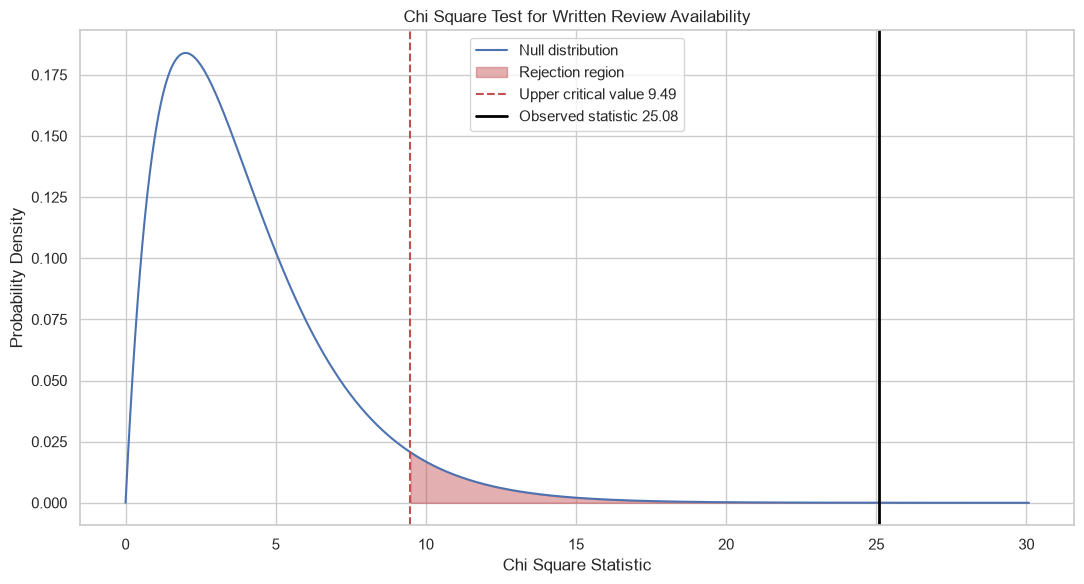

In [106]:
chi_square_values = np.linspace(
    0,
    max(
        chi_square_statistic + 5,
        upper_critical_value + 5
    ),
    1500
)

chi_square_density = stats.chi2.pdf(
    chi_square_values,
    degrees_of_freedom
)

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    chi_square_values,
    chi_square_density,
    color="#4C72B0",
    label="Null distribution"
)

plt.fill_between(
    chi_square_values,
    chi_square_density,
    where=(
        chi_square_values
        >= upper_critical_value
    ),
    color="#C44E52",
    alpha=0.45,
    label="Rejection region"
)

plt.axvline(
    upper_critical_value,
    color="#C44E52",
    linestyle="--",
    label=(
        "Upper critical value "
        f"{upper_critical_value:.2f}"
    )
)

plt.axvline(
    chi_square_statistic,
    color="black",
    linewidth=2,
    label=(
        "Observed statistic "
        f"{chi_square_statistic:.2f}"
    )
)

plt.title(
    "Chi Square Test for Written Review Availability"
)

plt.xlabel(
    "Chi Square Statistic"
)

plt.ylabel(
    "Probability Density"
)

plt.legend()

plt.tight_layout()

plt.show()

In [107]:
google_reviews_df[
    "rating_group"
] = pd.cut(
    google_reviews_df["rating"],
    bins=[0, 2, 3, 5],
    labels=[
        "Low rating",
        "Neutral rating",
        "High rating"
    ]
)

written_review_group_table = pd.crosstab(
    google_reviews_df["rating_group"],
    google_reviews_df[
        "written_review_available"
    ]
)

display(
    written_review_group_table
)

group_chi_square_statistic, \
group_chi_square_p_value, \
group_degrees_of_freedom, \
group_expected_frequencies = (
    stats.chi2_contingency(
        written_review_group_table
    )
)

group_expected_frequencies_df = pd.DataFrame(
    group_expected_frequencies,
    index=written_review_group_table.index,
    columns=written_review_group_table.columns
)

number_of_reviews = (
    written_review_group_table
    .to_numpy()
    .sum()
)

minimum_dimension = min(
    written_review_group_table.shape[0] - 1,
    written_review_group_table.shape[1] - 1
)

group_cramers_v = np.sqrt(
    group_chi_square_statistic
    / (
        number_of_reviews
        * minimum_dimension
    )
)

alpha_level = 0.05

group_upper_critical_value = stats.chi2.ppf(
    1 - alpha_level,
    group_degrees_of_freedom
)

print(
    "Chi square statistic:",
    round(
        group_chi_square_statistic,
        4
    )
)

print(
    "P value:",
    format(
        group_chi_square_p_value,
        ".10f"
    )
)

print(
    "Degrees of freedom:",
    group_degrees_of_freedom
)

print(
    "Alpha level:",
    alpha_level
)

print(
    "Lower critical value:",
    "Not applicable for this upper tailed test"
)

print(
    "Upper critical value:",
    round(
        group_upper_critical_value,
        4
    )
)

print(
    "Cramer's V:",
    round(
        group_cramers_v,
        4
    )
)

print(
    "Minimum expected frequency:",
    round(
        group_expected_frequencies_df
        .min()
        .min(),
        2
    )
)

if group_chi_square_p_value < alpha_level:
    print(
        "Decision: Reject the null hypothesis"
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis"
    )

written_review_available,False,True
rating_group,,
Low rating,169,17
Neutral rating,302,14
High rating,3618,107


Chi square statistic: 23.5028
P value: 0.0000078784
Degrees of freedom: 2
Alpha level: 0.05
Lower critical value: Not applicable for this upper tailed test
Upper critical value: 5.9915
Cramer's V: 0.0746
Minimum expected frequency: 6.07
Decision: Reject the null hypothesis


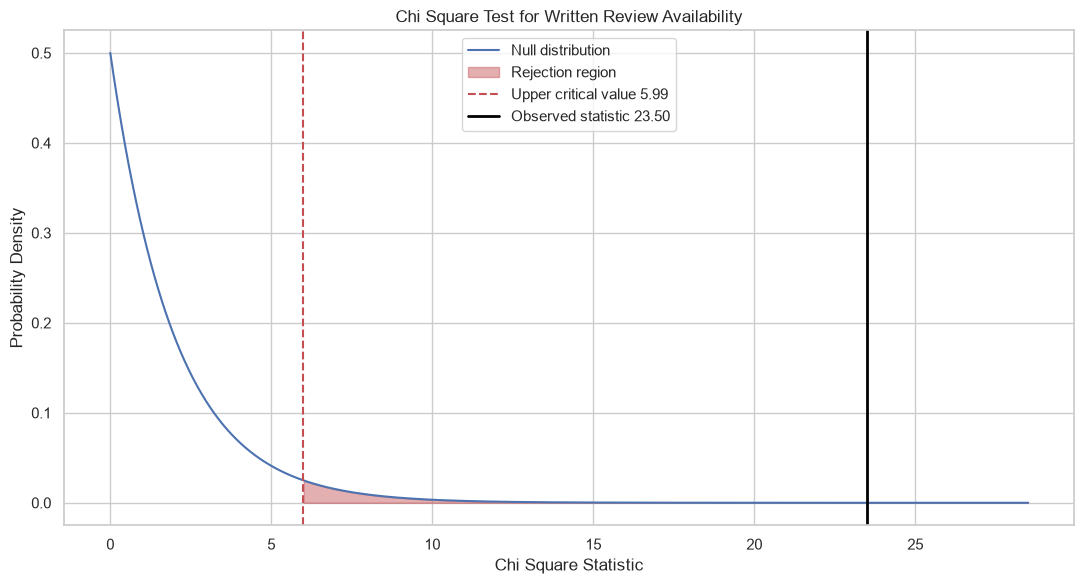

In [108]:
group_chi_square_values = np.linspace(
    0,
    max(
        group_chi_square_statistic + 5,
        group_upper_critical_value + 5
    ),
    1500
)

group_chi_square_density = stats.chi2.pdf(
    group_chi_square_values,
    group_degrees_of_freedom
)

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    group_chi_square_values,
    group_chi_square_density,
    color="#4C72B0",
    label="Null distribution"
)

plt.fill_between(
    group_chi_square_values,
    group_chi_square_density,
    where=(
        group_chi_square_values
        >= group_upper_critical_value
    ),
    color="#C44E52",
    alpha=0.45,
    label="Rejection region"
)

plt.axvline(
    group_upper_critical_value,
    color="#C44E52",
    linestyle="--",
    label=(
        "Upper critical value "
        f"{group_upper_critical_value:.2f}"
    )
)

plt.axvline(
    group_chi_square_statistic,
    color="black",
    linewidth=2,
    label=(
        "Observed statistic "
        f"{group_chi_square_statistic:.2f}"
    )
)

plt.title(
    "Chi Square Test for Written Review Availability"
)

plt.xlabel(
    "Chi Square Statistic"
)

plt.ylabel(
    "Probability Density"
)

plt.legend()

plt.tight_layout()

plt.show()

### Written Review Availability by Rating Group

A chi square test of independence was used to determine whether written
review availability was associated with rating group.

The minimum expected frequency was 6.07, confirming that the expected
frequency assumption was satisfied.

The observed chi square statistic was 23.5028, exceeding the upper critical
value of 5.9915. The p value was 0.0000078784, which was below the 0.05
significance level. Therefore, the null hypothesis was rejected.

Written review availability was significantly associated with rating group.
Approximately 9.14% of low ratings contained written feedback, compared with
4.43% of neutral ratings and 2.87% of high ratings.

Cramer's V was 0.0746, indicating a weak association. The result is
statistically significant, but rating group has only a small practical
relationship with whether a reviewer provides written comments.

### Business Implication

Guests giving low ratings were more likely to explain their experiences.
The written reviews may therefore provide useful information about service
failures and improvement opportunities.

However, only 138 of the 4,227 reviews contained text. Negative ratings were
also more strongly represented among written reviews. Any theme analysis
must therefore describe the written review sample and should not be
generalized to every Google reviewer.

In [109]:
from sklearn.feature_extraction.text import (
    CountVectorizer
)

written_reviews_df = google_reviews_df[
    google_reviews_df[
        "review_text_clean"
    ].notna()
].copy()

text_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

text_matrix = text_vectorizer.fit_transform(
    written_reviews_df[
        "review_text_clean"
    ]
)

word_frequency_df = pd.DataFrame({
    "word_or_phrase": (
        text_vectorizer
        .get_feature_names_out()
    ),
    "frequency": (
        text_matrix
        .sum(axis=0)
        .A1
    )
})

word_frequency_df = (
    word_frequency_df
    .sort_values(
        "frequency",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

print(
    "Written reviews analyzed:",
    len(written_reviews_df)
)

print(
    "Words and phrases found:",
    len(word_frequency_df)
)

display(
    word_frequency_df.head(30)
)

Written reviews analyzed: 138
Words and phrases found: 295


,word_or_phrase,frequency
0,room,34
1,hotel,31
2,good,29
3,food,26
4,sky,25
5,view,25
6,ranch,25
7,sky ranch,25
8,great,24
9,skyranch,23


In [110]:
rating_group_frequency_records = []

rating_group_order = [
    "Low rating",
    "Neutral rating",
    "High rating"
]

for current_rating_group in rating_group_order:

    current_reviews_df = written_reviews_df[
        written_reviews_df[
            "rating_group"
        ].eq(
            current_rating_group
        )
    ]

    current_vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2
    )

    current_text_matrix = (
        current_vectorizer.fit_transform(
            current_reviews_df[
                "review_text_clean"
            ]
        )
    )

    current_frequency_df = pd.DataFrame({
        "word_or_phrase": (
            current_vectorizer
            .get_feature_names_out()
        ),
        "frequency": (
            current_text_matrix
            .sum(axis=0)
            .A1
        )
    })

    current_frequency_df = (
        current_frequency_df
        .sort_values(
            "frequency",
            ascending=False
        )
        .head(20)
    )

    current_frequency_df.insert(
        0,
        "rating_group",
        current_rating_group
    )

    rating_group_frequency_records.append(
        current_frequency_df
    )

rating_group_word_frequency_df = pd.concat(
    rating_group_frequency_records,
    ignore_index=True
)

for current_rating_group in rating_group_order:

    print()
    print(
        current_rating_group.upper()
    )

    display(
        rating_group_word_frequency_df[
            rating_group_word_frequency_df[
                "rating_group"
            ].eq(
                current_rating_group
            )
        ][
            [
                "word_or_phrase",
                "frequency"
            ]
        ]
    )


LOW RATING


,word_or_phrase,frequency
0,room,10
1,old,6
2,just,4
3,wing,3
4,service,3
5,check,3
6,dinner,3
7,food,3
8,furniture,3
9,got,3



NEUTRAL RATING


,word_or_phrase,frequency
20,food,8
21,hotel,6
22,breakfast,5
23,taal,4
24,rooms,4
25,view,3
26,sky ranch,3
27,sky,3
28,room,3
29,ranch,3



HIGH RATING


,word_or_phrase,frequency
40,good,26
41,great,24
42,hotel,23
43,ranch,22
44,sky ranch,22
45,sky,22
46,room,21
47,clean,21
48,view,21
49,skyranch,21


In [111]:
review_theme_patterns = {
    "Room experience": (
        r"\broom\b|\brooms\b|\bsuite\b|"
        r"\bbed\b|\bfurniture\b|\bwing\b"
    ),
    "Food and dining": (
        r"\bfood\b|\bbreakfast\b|\bbuffet\b|"
        r"\bdinner\b|\brestaurant\b|"
        r"\brestaurants\b|\bmeal\b"
    ),
    "Location and access": (
        r"\bsky ranch\b|\bskyranch\b|"
        r"\bnear\b|\bnearby\b|\bwalk\b|"
        r"\bwalking\b|\bpark\b|\baccess\b"
    ),
    "View and scenery": (
        r"\bview\b|\bviews\b|\blake\b|"
        r"\btaal\b|\bvolcano\b|\bscenery\b"
    ),
    "Cleanliness": (
        r"\bclean\b|\bcleanliness\b|"
        r"\bdirty\b|\bdust\b|\bstain\b|"
        r"\bsmell\b"
    ),
    "Service and staff": (
        r"\bservice\b|\bstaff\b|\bmanager\b|"
        r"\breception\b|\bcheck in\b|"
        r"\bhelpful\b|\bfriendly\b"
    ),
    "Safety and security": (
        r"\bsafe\b|\bsafety\b|\bsecurity\b"
    )
}

for theme_name, theme_pattern in (
    review_theme_patterns.items()
):

    written_reviews_df[
        theme_name
    ] = written_reviews_df[
        "review_text_clean"
    ].str.lower().str.contains(
        theme_pattern,
        regex=True,
        na=False
    )

review_theme_records = []

for theme_name in review_theme_patterns:

    current_theme_df = written_reviews_df[
        written_reviews_df[
            theme_name
        ]
    ]

    review_theme_records.append({
        "review_theme": theme_name,
        "reviews_mentioning_theme": (
            len(current_theme_df)
        ),
        "coverage_percent": (
            len(current_theme_df)
            / len(written_reviews_df)
            * 100
        ),
        "average_rating": (
            current_theme_df[
                "rating"
            ].mean()
        ),
        "median_rating": (
            current_theme_df[
                "rating"
            ].median()
        ),
        "low_rating_reviews": (
            current_theme_df[
                "rating_group"
            ].eq(
                "Low rating"
            ).sum()
        ),
        "high_rating_reviews": (
            current_theme_df[
                "rating_group"
            ].eq(
                "High rating"
            ).sum()
        )
    })

review_theme_summary_df = pd.DataFrame(
    review_theme_records
)

review_theme_summary_df[
    "low_rating_percent"
] = (
    review_theme_summary_df[
        "low_rating_reviews"
    ]
    / review_theme_summary_df[
        "reviews_mentioning_theme"
    ]
    * 100
)

review_theme_summary_df[
    "high_rating_percent"
] = (
    review_theme_summary_df[
        "high_rating_reviews"
    ]
    / review_theme_summary_df[
        "reviews_mentioning_theme"
    ]
    * 100
)

review_theme_summary_df = (
    review_theme_summary_df
    .sort_values(
        "reviews_mentioning_theme",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    review_theme_summary_df.round(2)
)

,review_theme,reviews_mentioning_theme,coverage_percent,average_rating,median_rating,low_rating_reviews,high_rating_reviews,low_rating_percent,high_rating_percent
0,Location and access,67,48.55,4.43,5.00,4,58,5.97,86.57
1,Food and dining,52,37.68,4.13,5.00,5,39,9.62,75.00
2,Room experience,44,31.88,3.82,4.00,9,30,20.45,68.18
3,View and scenery,33,23.91,4.21,5.00,3,26,9.09,78.79
4,Cleanliness,25,18.12,4.44,5.00,2,21,8.00,84.00
5,Safety and security,21,15.22,4.33,5.00,2,18,9.52,85.71
6,Service and staff,17,12.32,3.29,3.00,6,8,35.29,47.06


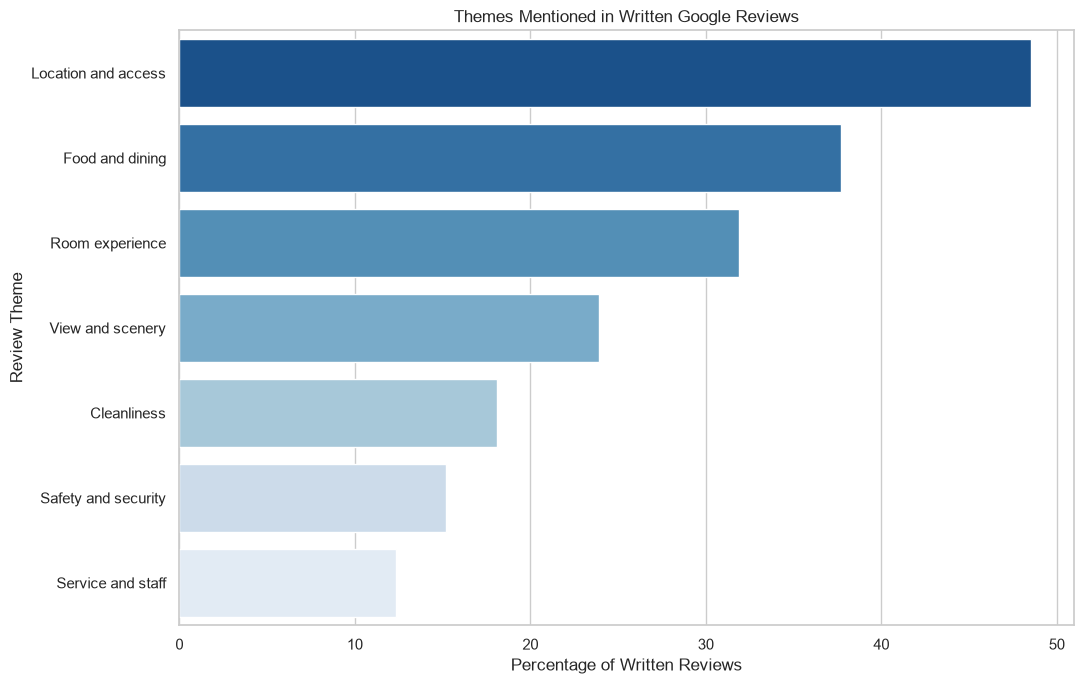

In [112]:
plt.figure(
    figsize=(11, 7)
)

sns.barplot(
    data=review_theme_summary_df,
    x="coverage_percent",
    y="review_theme",
    hue="review_theme",
    legend=False,
    palette="Blues_r"
)

plt.title(
    "Themes Mentioned in Written Google Reviews"
)

plt.xlabel(
    "Percentage of Written Reviews"
)

plt.ylabel(
    "Review Theme"
)

plt.tight_layout()

plt.show()

### Themes in Written Google Reviews

Keyword based theme identification was applied to the 138 written Google
reviews. Reviews could be assigned to multiple themes, so the percentages
do not total 100%.

Location and access was the most frequently mentioned theme, appearing in
48.55% of written reviews. Reviews mentioning this theme had an average
rating of 4.43, and 86.57% were high ratings. Proximity to Sky Ranch and
other nearby attractions appears to be an important part of the guest
experience.

Cleanliness also performed strongly, with an average rating of 4.44 and an
84.00% high rating share. View and scenery received an average rating of
4.21, supporting the importance of the Taal Lake setting.

Food and dining received an average rating of 4.13. Although most comments
were associated with high ratings, the lower high rating share of 75.00%
suggests more varied guest experiences.

Room experience had an average rating of 3.82, with 20.45% of comments
coming from low rated reviews. Terms found in the low rating group included
old, furniture, room, and wing, suggesting that room condition may require
closer examination.

Service and staff had the lowest average rating at 3.29 and the highest low
rating share at 35.29%. This makes service related feedback the leading
candidate for detailed complaint analysis.

### Business Implication

The hotel's location, views, cleanliness, and accessibility appear to be
important strengths among guests who provided written feedback.

Room condition and service delivery require closer investigation. Management
should review the specific low rated comments before deciding whether the
issues relate to room maintenance, check in procedures, staff interaction,
food service, or another operational concern.

These findings describe only the 138 written reviews and should not be
generalized to all 4,227 Google ratings.

In [113]:
theme_columns = list(
    review_theme_patterns.keys()
)

low_rating_written_reviews_df = (
    written_reviews_df[
        written_reviews_df[
            "rating_group"
        ].eq(
            "Low rating"
        )
    ][
        [
            "rating",
            "review_text_clean"
        ]
        + theme_columns
    ]
    .reset_index(
        drop=True
    )
)

print(
    "Low rating written reviews:",
    len(
        low_rating_written_reviews_df
    )
)

display(
    low_rating_written_reviews_df
)

Low rating written reviews: 17


,rating,review_text_clean,Room experience,Food and dining,Location and access,View and scenery,Cleanliness,Service and staff,Safety and security
0,1.00,The room is filthy and very old. I was given a...,True,True,True,False,False,False,False
1,1.00,Old very old and bed are so uncomfortable,True,False,False,False,False,False,False
2,1.00,"Haven’t been remodeled since at least 1960, mi...",True,True,False,True,False,True,True
3,2.00,No bath in most,False,False,False,False,False,False,False
4,1.00,From Mountain Wing Room To Lake Wing Room | SO...,True,False,False,True,False,False,False
5,2.00,Near Skyranch Tagaytay.,False,False,True,False,False,False,False
6,1.00,Outdated and stinks | Walking distance to skyr...,True,False,True,False,False,False,False
7,2.00,Room was large but very plain. Only one pictur...,True,True,False,False,False,True,False
8,1.00,Dirty and dated,False,False,False,False,True,False,False
9,2.00,old furniture and no carpets,True,False,False,False,False,False,False


In [114]:
pd.set_option(
    "display.max_colwidth",
    None
)

low_rating_comments_df = (
    written_reviews_df[
        written_reviews_df[
            "rating_group"
        ].eq(
            "Low rating"
        )
    ][
        [
            "rating",
            "review_text_clean"
        ]
    ]
    .reset_index(
        drop=True
    )
)

display(
    low_rating_comments_df
)

,rating,review_text_clean
0,1.00,The room is filthy and very old. I was given a room in the old wing. | Fairies wheel and nearby McDonalds | Not sure. | Along the main road but not walkable to resto and cafes. | Breakfast buffet selection is very limited. | Definitely not a 4 star in my experience. A total disaster.
1,1.00,Old very old and bed are so uncomfortable
2,1.00,"Haven’t been remodeled since at least 1960, minimal furniture and decoration, things didn’t work well. | Beautiful area, with wonderful sights | No concerns about safety - local people are friendly and helpful | Can easily take tricycles to go to local restaurants and tours | Taygaytay is a beautiful city, and very nice to visit - just not at Taal Vista Hotel……there are many other hotels."
3,2.00,No bath in most
4,1.00,From Mountain Wing Room To Lake Wing Room | SO MUCH MOLD - Health hazard
5,2.00,Near Skyranch Tagaytay.
6,1.00,Outdated and stinks | Walking distance to skyranch | Not sure since they can easily enter your room without asking permission | Expensive
7,2.00,Room was large but very plain. Only one picture on the wall. Furniture was old and stained. Needs renovation! | There is nothing closeby to hotel. Other hotels in the area have better locations. | High priced dinner - average food - poor service
8,1.00,Dirty and dated
9,2.00,old furniture and no carpets


In [115]:
for review_number, review_row in (
    low_rating_comments_df.iterrows()
):

    print()
    print(
        "REVIEW:",
        review_number + 1
    )

    print(
        "RATING:",
        review_row["rating"]
    )

    print(
        "COMMENT:",
        review_row[
            "review_text_clean"
        ]
    )


REVIEW: 1
RATING: 1.0
COMMENT: The room is filthy and very old. I was given a room in the old wing. | Fairies wheel and nearby McDonalds | Not sure. | Along the main road but not walkable to resto and cafes. | Breakfast buffet selection is very limited. | Definitely not a 4 star in my experience. A total disaster.

REVIEW: 2
RATING: 1.0
COMMENT: Old very old and bed are so uncomfortable

REVIEW: 3
RATING: 1.0
COMMENT: Haven’t been remodeled since at least 1960, minimal furniture and decoration, things didn’t work well. | Beautiful area, with wonderful sights | No concerns about safety - local people are friendly and helpful | Can easily take tricycles to go to local restaurants and tours | Taygaytay is a beautiful city, and very nice to visit - just not at Taal Vista Hotel……there are many other hotels.

REVIEW: 4
RATING: 2.0
COMMENT: No bath in most

REVIEW: 5
RATING: 1.0
COMMENT: From Mountain Wing Room To Lake Wing Room | SO MUCH MOLD - Health hazard

REVIEW: 6
RATING: 2.0
COMMENT: 

In [118]:
google_reviews_df[
    "review_text_clean"
] = google_reviews_df[
    "review_text_clean"
].str.replace(
    (
        r"\b[A-Z][a-z]+ "
        r"[A-Z][a-z]+ "
        r"Rm\s*\d+\b"
    ),
    "[Personal details removed]",
    regex=True
)

personal_detail_check = google_reviews_df[
    "review_text_clean"
].str.contains(
    r"\bRm\s*\d+\b",
    case=False,
    regex=True,
    na=False
)

print(
    "Possible room details remaining:",
    personal_detail_check.sum()
)

Possible room details remaining: 0


In [119]:
google_reviews_clean_file = (
    clean_data_folder
    / "taal_vista_google_reviews_clean.csv"
)

google_reviews_df.to_csv(
    google_reviews_clean_file,
    index=False
)

print(
    "File updated:",
    google_reviews_clean_file
)

print(
    "Rows saved:",
    len(google_reviews_df)
)

File updated: /Users/jannoelvero/Documents/Taal-Vista-Hotel/data/clean/taal_vista_google_reviews_clean.csv
Rows saved: 4227


In [120]:
low_rating_comments_df = (
    google_reviews_df[
        google_reviews_df[
            "rating_group"
        ].eq(
            "Low rating"
        )
        & google_reviews_df[
            "review_text_clean"
        ].notna()
    ][
        [
            "rating",
            "review_text_clean"
        ]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

complaint_patterns = {
    "Room condition": (
        r"\bold\b|\boutdated\b|\bdated\b|"
        r"\bremodel|\brenovation\b|\bfurniture\b|"
        r"\buncomfortable\b|\bno bath\b|"
        r"\bplain\b|\bno carpets\b|"
        r"things didn.t work"
    ),
    "Cleanliness and maintenance": (
        r"\bfilthy\b|\bdirty\b|\bmold\b|"
        r"\bstinks\b|\bstained\b|"
        r"\bhealth hazard\b"
    ),
    "Food and dining complaint": (
        r"\blimited\b|\blow quality\b|"
        r"\bnot worth\b|\bwasn.t good\b|"
        r"\bnot properly cooked\b|"
        r"\baverage food\b|\bno main course\b|"
        r"\bfood is meh\b"
    ),
    "Check in and reservation": (
        r"\breservation\b|\bcheck in\b|"
        r"\bwalk.in customer\b|"
        r"\broom were not ready\b"
    ),
    "Service complaint": (
        r"\bpoor service\b|\bserving is so slow\b|"
        r"\bsimply slow\b|\bmanager\b|"
        r"\bdisappointed with your service|"
        r"\bnot recommended ang service\b"
    ),
    "Safety and privacy": (
        r"\bnot safe\b|"
        r"enter your room without asking permission"
    ),
    "Price and value": (
        r"\bexpensive\b|\bhigh priced\b|"
        r"\bnot worth the price\b|"
        r"\bprice they are charging\b"
    ),
    "Location concern": (
        r"\bnot walkable\b|\bnothing closeby\b|"
        r"\bbetter locations\b"
    )
}

for complaint_name, complaint_pattern in (
    complaint_patterns.items()
):

    low_rating_comments_df[
        complaint_name
    ] = low_rating_comments_df[
        "review_text_clean"
    ].str.lower().str.contains(
        complaint_pattern,
        regex=True,
        na=False
    )

complaint_columns = list(
    complaint_patterns.keys()
)

complaint_summary_df = pd.DataFrame({
    "complaint_category": complaint_columns,
    "reviews": [
        low_rating_comments_df[
            complaint_name
        ].sum()
        for complaint_name in complaint_columns
    ]
})

complaint_summary_df[
    "percentage_of_low_written_reviews"
] = (
    complaint_summary_df["reviews"]
    / len(low_rating_comments_df)
    * 100
)

complaint_summary_df = (
    complaint_summary_df
    .sort_values(
        "reviews",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    complaint_summary_df.round(2)
)

low_rating_comments_df[
    "complaint_identified"
] = low_rating_comments_df[
    complaint_columns
].any(
    axis=1
)

print(
    "Low rating written reviews:",
    len(low_rating_comments_df)
)

print(
    "Reviews with an identified complaint:",
    low_rating_comments_df[
        "complaint_identified"
    ].sum()
)

print(
    "Reviews without an explicit complaint:",
    (
        ~low_rating_comments_df[
            "complaint_identified"
        ]
    ).sum()
)

,complaint_category,reviews,percentage_of_low_written_reviews
0,Room condition,8,47.06
1,Cleanliness and maintenance,6,35.29
2,Food and dining complaint,4,23.53
3,Service complaint,4,23.53
4,Price and value,4,23.53
5,Check in and reservation,2,11.76
6,Safety and privacy,2,11.76
7,Location concern,2,11.76


Low rating written reviews: 17
Reviews with an identified complaint: 16
Reviews without an explicit complaint: 1


In [121]:
display(
    low_rating_comments_df[
        [
            "rating",
            "review_text_clean"
        ]
        + complaint_columns
    ]
)

,rating,review_text_clean,Room condition,Cleanliness and maintenance,Food and dining complaint,Check in and reservation,Service complaint,Safety and privacy,Price and value,Location concern
0,1.00,The room is filthy and very old. I was given a room in the old wing. | Fairies wheel and nearby McDonalds | Not sure. | Along the main road but not walkable to resto and cafes. | Breakfast buffet selection is very limited. | Definitely not a 4 star in my experience. A total disaster.,True,True,True,False,False,False,False,True
1,1.00,Old very old and bed are so uncomfortable,True,False,False,False,False,False,False,False
2,1.00,"Haven’t been remodeled since at least 1960, minimal furniture and decoration, things didn’t work well. | Beautiful area, with wonderful sights | No concerns about safety - local people are friendly and helpful | Can easily take tricycles to go to local restaurants and tours | Taygaytay is a beautiful city, and very nice to visit - just not at Taal Vista Hotel……there are many other hotels.",True,False,False,False,False,False,False,False
3,2.00,No bath in most,True,False,False,False,False,False,False,False
4,1.00,From Mountain Wing Room To Lake Wing Room | SO MUCH MOLD - Health hazard,False,True,False,False,False,False,False,False
5,2.00,Near Skyranch Tagaytay.,False,False,False,False,False,False,False,False
6,1.00,Outdated and stinks | Walking distance to skyranch | Not sure since they can easily enter your room without asking permission | Expensive,True,True,False,False,False,True,True,False
7,2.00,Room was large but very plain. Only one picture on the wall. Furniture was old and stained. Needs renovation! | There is nothing closeby to hotel. Other hotels in the area have better locations. | High priced dinner - average food - poor service,True,True,True,False,True,False,True,True
8,1.00,Dirty and dated,True,True,False,False,False,False,False,False
9,2.00,old furniture and no carpets,True,False,False,False,False,False,False,False


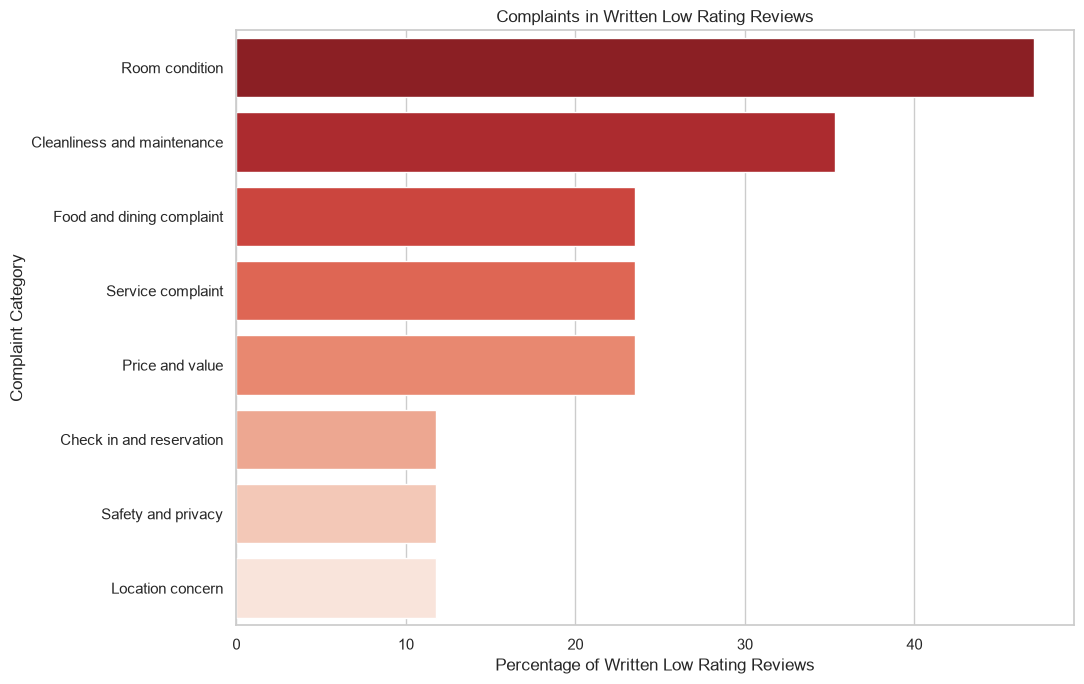

In [122]:
plt.figure(
    figsize=(11, 7)
)

sns.barplot(
    data=complaint_summary_df,
    x="percentage_of_low_written_reviews",
    y="complaint_category",
    hue="complaint_category",
    legend=False,
    palette="Reds_r"
)

plt.title(
    "Complaints in Written Low Rating Reviews"
)

plt.xlabel(
    "Percentage of Written Low Rating Reviews"
)

plt.ylabel(
    "Complaint Category"
)

plt.tight_layout()

plt.show()

### Analysis of Written Low Rating Reviews

The complaint analysis covered 17 written reviews with ratings of 1 or 2.
Sixteen reviews contained at least one identifiable complaint. One review
only mentioned the hotel's proximity to Sky Ranch and did not provide enough
information to explain its low rating.

Room condition was the most frequent complaint, appearing in 47.06% of the
written low rating reviews. Comments referred to old rooms, outdated
furniture, uncomfortable beds, missing bathroom features, plain interiors,
and the need for renovation.

Cleanliness and maintenance appeared in 35.29% of the comments. Reported
issues included dirty or filthy rooms, mold, stained furniture, and
unpleasant odor.

Food and dining, service delivery, and price or value concerns each appeared
in 23.53% of the comments. Specific concerns included limited breakfast
selection, low quality food, slow meal service, poor staff response, and
prices that guests considered too high for the experience received.

Check in and reservation problems appeared in 11.76% of the comments.
Reported issues included rooms not being ready, poor follow up, and
reservation customers being handled like walk in guests.

Safety and privacy concerns also appeared in 11.76% of the comments. Although
the count was small, these comments should receive management attention
because they included a direct safety concern and a report of room entry
without permission.

### Business Implication

Room renovation and preventive maintenance should be the leading operational
priority based on the written low rating feedback. Housekeeping inspections
should specifically monitor dirt, mold, stains, and odor.

Management should also review check in procedures, escalation practices,
restaurant service times, food quality, and room access controls.

The results are exploratory and describe only 17 written low rating reviews.
They should be treated as operational warning signals rather than estimates
of complaint prevalence among all hotel guests.

In [124]:
reviewer_experience_df = google_reviews_df[
    [
        "rating",
        "reviewer_review_count"
    ]
].dropna().copy()

print(
    "Reviews included:",
    len(reviewer_experience_df)
)

print(
    "Records excluded because review count is missing:",
    google_reviews_df[
        "reviewer_review_count"
    ].isna().sum()
)

print(
    "Minimum reviewer review count:",
    reviewer_experience_df[
        "reviewer_review_count"
    ].min()
)

print(
    "Median reviewer review count:",
    reviewer_experience_df[
        "reviewer_review_count"
    ].median()
)

print(
    "Average reviewer review count:",
    round(
        reviewer_experience_df[
            "reviewer_review_count"
        ].mean(),
        2
    )
)

print(
    "Maximum reviewer review count:",
    reviewer_experience_df[
        "reviewer_review_count"
    ].max()
)

Reviews included: 3716
Records excluded because review count is missing: 511
Minimum reviewer review count: 1.0
Median reviewer review count: 18.0
Average reviewer review count: 57.16
Maximum reviewer review count: 999.0


In [125]:
review_count_q1 = reviewer_experience_df[
    "reviewer_review_count"
].quantile(
    0.25
)

review_count_q3 = reviewer_experience_df[
    "reviewer_review_count"
].quantile(
    0.75
)

review_count_iqr = (
    review_count_q3
    - review_count_q1
)

review_count_lower_boundary = (
    review_count_q1
    - 1.5 * review_count_iqr
)

review_count_upper_boundary = (
    review_count_q3
    + 1.5 * review_count_iqr
)

review_count_outliers = reviewer_experience_df[
    reviewer_experience_df[
        "reviewer_review_count"
    ] > review_count_upper_boundary
]

review_count_shapiro = stats.shapiro(
    reviewer_experience_df[
        "reviewer_review_count"
    ]
)

print(
    "First quartile:",
    review_count_q1
)

print(
    "Third quartile:",
    review_count_q3
)

print(
    "Interquartile range:",
    review_count_iqr
)

print(
    "Lower boundary:",
    review_count_lower_boundary
)

print(
    "Upper boundary:",
    review_count_upper_boundary
)

print(
    "Outliers:",
    len(review_count_outliers)
)

print(
    "Shapiro Wilk statistic:",
    round(
        review_count_shapiro.statistic,
        4
    )
)

print(
    "Shapiro Wilk p value:",
    format(
        review_count_shapiro.pvalue,
        ".10f"
    )
)

if review_count_shapiro.pvalue < 0.05:
    print(
        "Conclusion: Reviewer review counts are not normally distributed"
    )
else:
    print(
        "Conclusion: Normality was not rejected"
    )

First quartile: 5.0
Third quartile: 62.0
Interquartile range: 57.0
Lower boundary: -80.5
Upper boundary: 147.5
Outliers: 382
Shapiro Wilk statistic: 0.5514
Shapiro Wilk p value: 0.0000000000
Conclusion: Reviewer review counts are not normally distributed


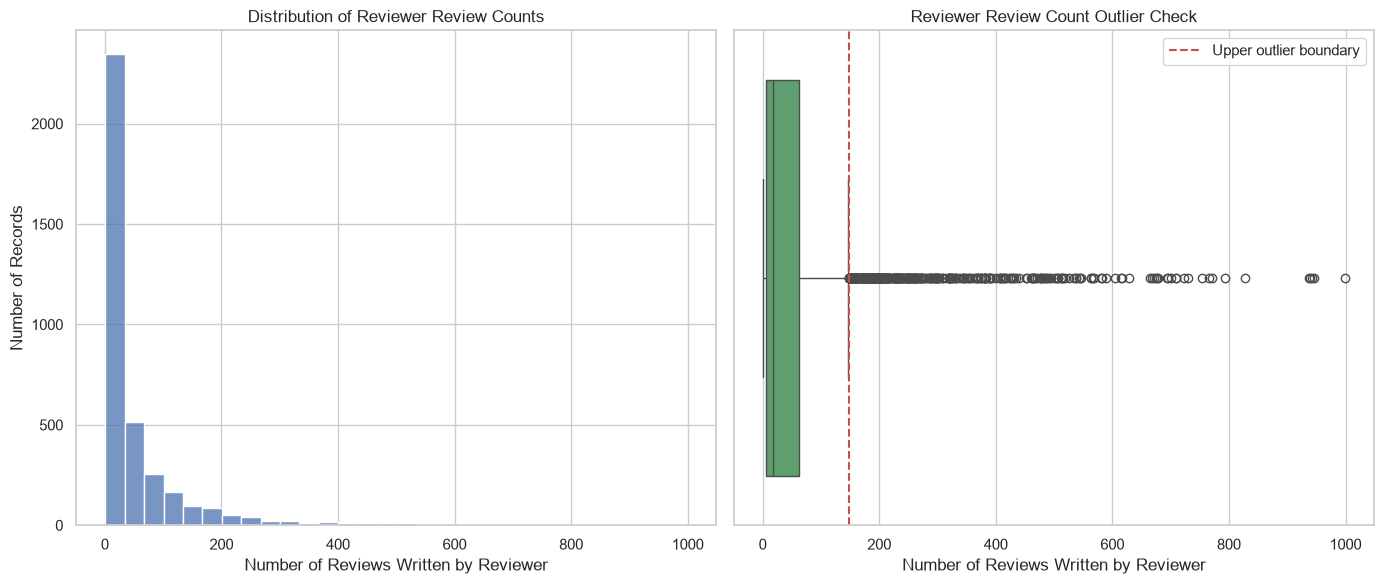

In [126]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

sns.histplot(
    data=reviewer_experience_df,
    x="reviewer_review_count",
    bins=30,
    ax=axes[0],
    color="#4C72B0"
)

axes[0].set_title(
    "Distribution of Reviewer Review Counts"
)

axes[0].set_xlabel(
    "Number of Reviews Written by Reviewer"
)

axes[0].set_ylabel(
    "Number of Records"
)

sns.boxplot(
    data=reviewer_experience_df,
    x="reviewer_review_count",
    ax=axes[1],
    color="#55A868"
)

axes[1].axvline(
    review_count_upper_boundary,
    color="#C44E52",
    linestyle="--",
    label="Upper outlier boundary"
)

axes[1].set_title(
    "Reviewer Review Count Outlier Check"
)

axes[1].set_xlabel(
    "Number of Reviews Written by Reviewer"
)

axes[1].legend()

plt.tight_layout()

plt.show()

Null hypothesis: Reviewer review count is not associated with hotel rating.

Alternative hypothesis: Reviewer review count is associated with hotel rating.

In [127]:
reviewer_spearman_result = stats.spearmanr(
    reviewer_experience_df[
        "reviewer_review_count"
    ],
    reviewer_experience_df[
        "rating"
    ]
)

reviewer_spearman_correlation = (
    reviewer_spearman_result.statistic
)

reviewer_spearman_p_value = (
    reviewer_spearman_result.pvalue
)

reviewer_sample_size = len(
    reviewer_experience_df
)

reviewer_degrees_of_freedom = (
    reviewer_sample_size - 2
)

reviewer_test_statistic = (
    reviewer_spearman_correlation
    * np.sqrt(
        reviewer_degrees_of_freedom
        / (
            1
            - reviewer_spearman_correlation ** 2
        )
    )
)

alpha_level = 0.05

reviewer_lower_critical_value = stats.t.ppf(
    alpha_level / 2,
    reviewer_degrees_of_freedom
)

reviewer_upper_critical_value = stats.t.ppf(
    1 - alpha_level / 2,
    reviewer_degrees_of_freedom
)

print(
    "Sample size:",
    reviewer_sample_size
)

print(
    "Degrees of freedom:",
    reviewer_degrees_of_freedom
)

print(
    "Spearman correlation:",
    round(
        reviewer_spearman_correlation,
        4
    )
)

print(
    "P value:",
    format(
        reviewer_spearman_p_value,
        ".10f"
    )
)

print(
    "Test statistic:",
    round(
        reviewer_test_statistic,
        4
    )
)

print(
    "Lower critical value:",
    round(
        reviewer_lower_critical_value,
        4
    )
)

print(
    "Upper critical value:",
    round(
        reviewer_upper_critical_value,
        4
    )
)

if reviewer_spearman_p_value < alpha_level:
    print(
        "Decision: Reject the null hypothesis"
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis"
    )

Sample size: 3716
Degrees of freedom: 3714
Spearman correlation: -0.0565
P value: 0.0005697145
Test statistic: -3.4486
Lower critical value: -1.9606
Upper critical value: 1.9606
Decision: Reject the null hypothesis


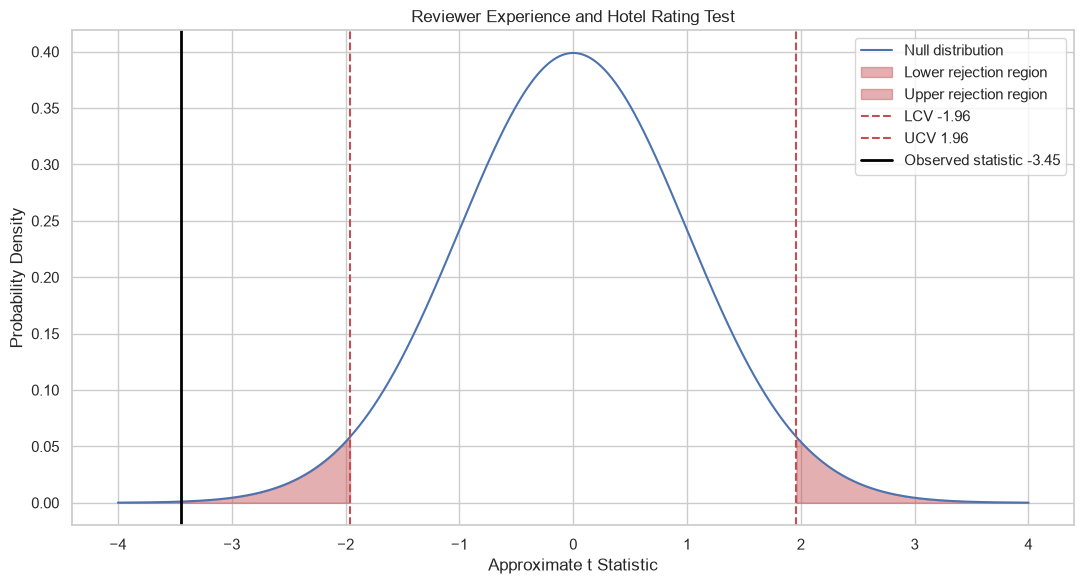

In [128]:
reviewer_t_values = np.linspace(
    -4,
    4,
    1500
)

reviewer_t_density = stats.t.pdf(
    reviewer_t_values,
    reviewer_degrees_of_freedom
)

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    reviewer_t_values,
    reviewer_t_density,
    color="#4C72B0",
    label="Null distribution"
)

plt.fill_between(
    reviewer_t_values,
    reviewer_t_density,
    where=(
        reviewer_t_values
        <= reviewer_lower_critical_value
    ),
    color="#C44E52",
    alpha=0.45,
    label="Lower rejection region"
)

plt.fill_between(
    reviewer_t_values,
    reviewer_t_density,
    where=(
        reviewer_t_values
        >= reviewer_upper_critical_value
    ),
    color="#C44E52",
    alpha=0.45,
    label="Upper rejection region"
)

plt.axvline(
    reviewer_lower_critical_value,
    color="#C44E52",
    linestyle="--",
    label=(
        "LCV "
        f"{reviewer_lower_critical_value:.2f}"
    )
)

plt.axvline(
    reviewer_upper_critical_value,
    color="#C44E52",
    linestyle="--",
    label=(
        "UCV "
        f"{reviewer_upper_critical_value:.2f}"
    )
)

plt.axvline(
    reviewer_test_statistic,
    color="black",
    linewidth=2,
    label=(
        "Observed statistic "
        f"{reviewer_test_statistic:.2f}"
    )
)

plt.title(
    "Reviewer Experience and Hotel Rating Test"
)

plt.xlabel(
    "Approximate t Statistic"
)

plt.ylabel(
    "Probability Density"
)

plt.legend()

plt.tight_layout()

plt.show()

### Reviewer Experience and Hotel Rating

A Spearman rank correlation test was used because reviewer review counts were
strongly nonnormal and contained 382 valid statistical outliers. Hotel
ratings were also ordinal and nonnormal.

The analysis included 3,716 reviews. A total of 511 records were excluded
because reviewer review count was unavailable.

The Spearman correlation was negative 0.0565. The approximate test statistic
was negative 3.4486, which fell below the lower critical value of negative
1.9606. The p value was 0.0005697, which was below the 0.05 significance
level. Therefore, the null hypothesis was rejected.

There was a statistically significant negative association between reviewer
experience and hotel rating. However, the correlation coefficient of
negative 0.0565 represents a negligible effect.

The large sample size made it possible for a very small relationship to
become statistically significant. Reviewer experience therefore has little
practical relationship with the rating given to the hotel.

### Business Implication

The number of reviews previously written by a guest should not be treated as
an important predictor of satisfaction. Experienced and less experienced
reviewers provide broadly similar hotel ratings.

Management decisions should focus on the operational issues identified in
the written comments rather than reviewer activity level.

In [129]:
google_reviews_export_df = (
    google_reviews_df.drop(
        columns=[
            "rating_group",
            "rating_outlier",
            "written_review_available"
        ],
        errors="ignore"
    )
    .copy()
)

google_reviews_export_df.to_csv(
    google_reviews_clean_file,
    index=False
)

google_reviews_verification_df = pd.read_csv(
    google_reviews_clean_file
)

print(
    "File updated:",
    google_reviews_clean_file
)

print(
    "Loaded shape:",
    google_reviews_verification_df.shape
)

print(
    "Columns saved:",
    google_reviews_verification_df.shape[1]
)

print(
    "Personal details remaining:",
    google_reviews_verification_df[
        "review_text_clean"
    ].str.contains(
        r"\bRm\s*\d+\b",
        case=False,
        regex=True,
        na=False
    ).sum()
)

File updated: /Users/jannoelvero/Documents/Taal-Vista-Hotel/data/clean/taal_vista_google_reviews_clean.csv
Loaded shape: (4227, 18)
Columns saved: 18
Personal details remaining: 0


In [130]:
eda_only_google_review_columns = [
    "rating_group",
    "rating_outlier",
    "written_review_available",
    "has_estimated_date"
]

google_reviews_export_df = (
    google_reviews_df.drop(
        columns=eda_only_google_review_columns,
        errors="ignore"
    )
    .copy()
)

google_reviews_export_df.to_csv(
    google_reviews_clean_file,
    index=False
)

google_reviews_verification_df = pd.read_csv(
    google_reviews_clean_file
)

print(
    "Loaded shape:",
    google_reviews_verification_df.shape
)

print(
    "Columns saved:",
    google_reviews_verification_df.shape[1]
)

print(
    "Saved columns:"
)

print(
    google_reviews_verification_df
    .columns
    .tolist()
)

Loaded shape: (4227, 17)
Columns saved: 17
Saved columns:
['review_id', 'author', 'reviewer_info', 'rating', 'date', 'review_text', 'owner_reply', 'source', 'is_local_guide', 'reviewer_review_count', 'is_edited', 'estimated_review_date', 'review_text_clean', 'has_owner_reply', 'date_collected', 'source_url', 'date_estimation_note']


In [131]:
dated_google_reviews_df = (
    google_reviews_df[
        google_reviews_df[
            "estimated_review_date"
        ].notna()
    ]
    .copy()
)

dated_google_reviews_df[
    "estimated_review_date"
] = pd.to_datetime(
    dated_google_reviews_df[
        "estimated_review_date"
    ]
)

dated_google_reviews_df[
    "estimated_review_year"
] = dated_google_reviews_df[
    "estimated_review_date"
].dt.year

print(
    "Dated reviews:",
    len(dated_google_reviews_df)
)

print(
    "Reviews without estimated dates:",
    google_reviews_df[
        "estimated_review_date"
    ].isna().sum()
)

print(
    "Date coverage percent:",
    round(
        len(dated_google_reviews_df)
        / len(google_reviews_df)
        * 100,
        2
    )
)

print(
    "Earliest estimated date:",
    dated_google_reviews_df[
        "estimated_review_date"
    ].min()
)

print(
    "Latest estimated date:",
    dated_google_reviews_df[
        "estimated_review_date"
    ].max()
)

Dated reviews: 2851
Reviews without estimated dates: 1376
Date coverage percent: 67.45
Earliest estimated date: 2019-09-03 00:00:00
Latest estimated date: 2026-09-02 00:00:00


In [132]:
google_review_year_summary_df = (
    dated_google_reviews_df.groupby(
        "estimated_review_year"
    )
    .agg(
        reviews=(
            "review_id",
            "count"
        ),
        average_rating=(
            "rating",
            "mean"
        ),
        median_rating=(
            "rating",
            "median"
        ),
        high_ratings=(
            "rating",
            lambda values: (
                values >= 4
            ).sum()
        )
    )
    .reset_index()
)

google_review_year_summary_df[
    "high_rating_percent"
] = (
    google_review_year_summary_df[
        "high_ratings"
    ]
    / google_review_year_summary_df[
        "reviews"
    ]
    * 100
)

display(
    google_review_year_summary_df.round(2)
)

,estimated_review_year,reviews,average_rating,median_rating,high_ratings,high_rating_percent
0,2019,652,4.45,5.00,572,87.73
1,2020,380,4.53,5.00,349,91.84
2,2021,230,4.54,5.00,210,91.30
3,2022,322,4.49,5.00,281,87.27
4,2023,479,4.43,5.00,413,86.22
5,2024,316,4.51,5.00,288,91.14
6,2025,295,4.33,5.00,244,82.71
7,2026,177,4.28,5.00,147,83.05


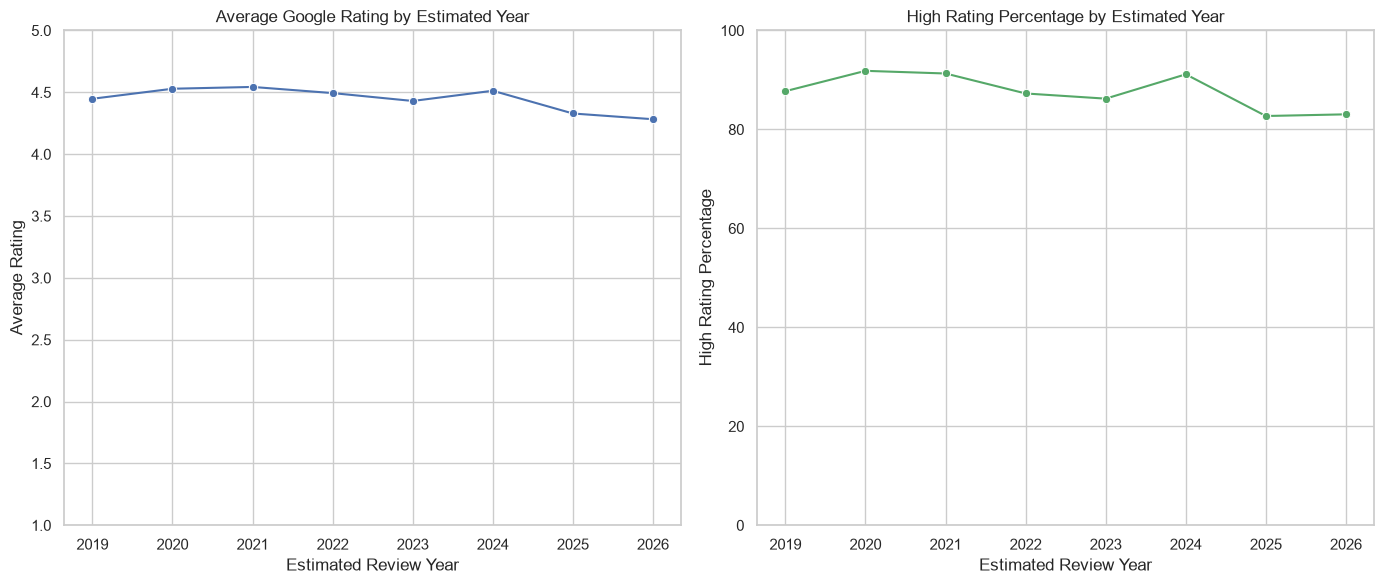

In [133]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

sns.lineplot(
    data=google_review_year_summary_df,
    x="estimated_review_year",
    y="average_rating",
    marker="o",
    ax=axes[0],
    color="#4C72B0"
)

axes[0].set_title(
    "Average Google Rating by Estimated Year"
)

axes[0].set_xlabel(
    "Estimated Review Year"
)

axes[0].set_ylabel(
    "Average Rating"
)

axes[0].set_ylim(
    1,
    5
)

sns.lineplot(
    data=google_review_year_summary_df,
    x="estimated_review_year",
    y="high_rating_percent",
    marker="o",
    ax=axes[1],
    color="#55A868"
)

axes[1].set_title(
    "High Rating Percentage by Estimated Year"
)

axes[1].set_xlabel(
    "Estimated Review Year"
)

axes[1].set_ylabel(
    "High Rating Percentage"
)

axes[1].set_ylim(
    0,
    100
)

plt.tight_layout()

plt.show()

Null hypothesis: Estimated review year is not associated with rating.

Alternative hypothesis: Estimated review year is associated with rating.

In [134]:
review_year_spearman_result = stats.spearmanr(
    dated_google_reviews_df[
        "estimated_review_year"
    ],
    dated_google_reviews_df[
        "rating"
    ]
)

review_year_correlation = (
    review_year_spearman_result.statistic
)

review_year_p_value = (
    review_year_spearman_result.pvalue
)

review_year_sample_size = len(
    dated_google_reviews_df
)

review_year_degrees_of_freedom = (
    review_year_sample_size - 2
)

review_year_test_statistic = (
    review_year_correlation
    * np.sqrt(
        review_year_degrees_of_freedom
        / (
            1
            - review_year_correlation ** 2
        )
    )
)

alpha_level = 0.05

review_year_lower_critical_value = stats.t.ppf(
    alpha_level / 2,
    review_year_degrees_of_freedom
)

review_year_upper_critical_value = stats.t.ppf(
    1 - alpha_level / 2,
    review_year_degrees_of_freedom
)

print(
    "Sample size:",
    review_year_sample_size
)

print(
    "Spearman correlation:",
    round(
        review_year_correlation,
        4
    )
)

print(
    "P value:",
    format(
        review_year_p_value,
        ".10f"
    )
)

print(
    "Test statistic:",
    round(
        review_year_test_statistic,
        4
    )
)

print(
    "Lower critical value:",
    round(
        review_year_lower_critical_value,
        4
    )
)

print(
    "Upper critical value:",
    round(
        review_year_upper_critical_value,
        4
    )
)

if review_year_p_value < alpha_level:
    print(
        "Decision: Reject the null hypothesis"
    )
else:
    print(
        "Decision: Fail to reject the null hypothesis"
    )

Sample size: 2851
Spearman correlation: 0.0018
P value: 0.9219640897
Test statistic: 0.098
Lower critical value: -1.9608
Upper critical value: 1.9608
Decision: Fail to reject the null hypothesis


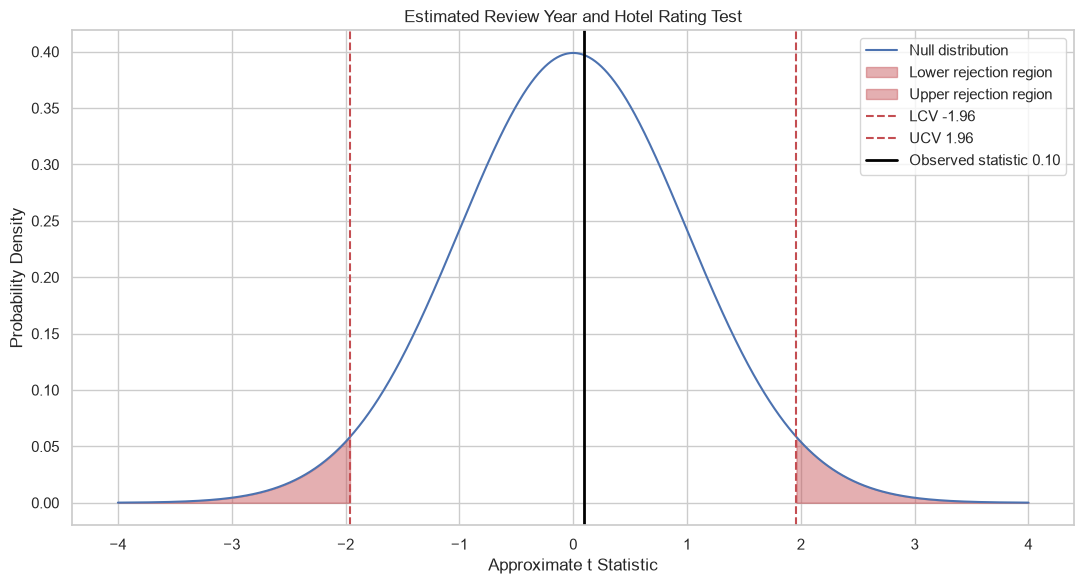

In [135]:
review_year_t_values = np.linspace(
    -4,
    4,
    1500
)

review_year_t_density = stats.t.pdf(
    review_year_t_values,
    review_year_degrees_of_freedom
)

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    review_year_t_values,
    review_year_t_density,
    color="#4C72B0",
    label="Null distribution"
)

plt.fill_between(
    review_year_t_values,
    review_year_t_density,
    where=(
        review_year_t_values
        <= review_year_lower_critical_value
    ),
    color="#C44E52",
    alpha=0.45,
    label="Lower rejection region"
)

plt.fill_between(
    review_year_t_values,
    review_year_t_density,
    where=(
        review_year_t_values
        >= review_year_upper_critical_value
    ),
    color="#C44E52",
    alpha=0.45,
    label="Upper rejection region"
)

plt.axvline(
    review_year_lower_critical_value,
    color="#C44E52",
    linestyle="--",
    label=(
        "LCV "
        f"{review_year_lower_critical_value:.2f}"
    )
)

plt.axvline(
    review_year_upper_critical_value,
    color="#C44E52",
    linestyle="--",
    label=(
        "UCV "
        f"{review_year_upper_critical_value:.2f}"
    )
)

plt.axvline(
    review_year_test_statistic,
    color="black",
    linewidth=2,
    label=(
        "Observed statistic "
        f"{review_year_test_statistic:.2f}"
    )
)

plt.title(
    "Estimated Review Year and Hotel Rating Test"
)

plt.xlabel(
    "Approximate t Statistic"
)

plt.ylabel(
    "Probability Density"
)

plt.legend()

plt.tight_layout()

plt.show()

### Estimated Rating Trend Over Time

The yearly summaries showed some variation in Google ratings. Average ratings
ranged from 4.28 in 2026 to 4.54 in 2021. The high rating percentage ranged
from 82.71% in 2025 to 91.84% in 2020.

A Spearman rank correlation test was used to evaluate whether ratings had a
consistent monotonic relationship with estimated review year.

The analysis included 2,851 reviews with estimated dates. The Spearman
correlation was 0.0018. The observed test statistic was 0.098, which fell
between the lower critical value of negative 1.9608 and the upper critical
value of 1.9608.

The p value was 0.922, which was above the 0.05 significance level.
Therefore, the null hypothesis was not rejected.

There was no statistically significant or practically meaningful monotonic
relationship between estimated review year and hotel rating.

Although ratings were lower in 2025 and 2026 than in 2024, this recent
difference does not demonstrate a consistent trend across the complete
period.

### Business Implication

The available evidence does not support a conclusion that guest satisfaction
consistently improved or declined from 2019 through 2026.

Management may monitor the lower average ratings observed in 2025 and 2026,
but additional complete and accurately dated review data would be required
before treating this as a sustained decline.

The time analysis has important limitations. Dates were estimated from
relative date descriptions, 2026 represents an incomplete year, and estimated
dates were available for only 67.45% of reviews. Date availability also
matched owner reply availability exactly, indicating an extraction dependency.

In [137]:
clean_csv_files = sorted(
    clean_data_folder.glob(
        "*_clean.csv"
    )
)

final_eda_validation_records = []

for clean_csv_file in clean_csv_files:

    current_df = pd.read_csv(
        clean_csv_file
    )

    final_eda_validation_records.append({
        "file_name": clean_csv_file.name,
        "rows": current_df.shape[0],
        "columns": current_df.shape[1],
        "duplicate_rows": (
            current_df.duplicated().sum()
        )
    })

final_eda_validation_df = pd.DataFrame(
    final_eda_validation_records
)

display(
    final_eda_validation_df
)

print(
    "Clean datasets:",
    len(final_eda_validation_df)
)

print(
    "Total clean rows:",
    final_eda_validation_df[
        "rows"
    ].sum()
)

print(
    "Total duplicate rows:",
    final_eda_validation_df[
        "duplicate_rows"
    ].sum()
)

,file_name,rows,columns,duplicate_rows
0,taal_vista_christmas_packages_clean.csv,4,25,0
1,taal_vista_dining_clean.csv,5,12,0
2,taal_vista_event_venues_clean.csv,24,18,0
3,taal_vista_facilities_clean.csv,5,6,0
4,taal_vista_google_reviews_clean.csv,4227,17,0
5,taal_vista_hotel_contact_clean.csv,5,8,0
6,taal_vista_hotel_facts_clean.csv,12,8,0
7,taal_vista_meeting_rates_clean.csv,18,21,0
8,taal_vista_official_reviews_clean.csv,6,10,0
9,taal_vista_pasalubong_prices_clean.csv,34,17,0


Clean datasets: 15
Total clean rows: 4504
Total duplicate rows: 0


In [138]:
saved_google_reviews_df = pd.read_csv(
    clean_data_folder
    / "taal_vista_google_reviews_clean.csv"
)

eda_only_columns = [
    "rating_group",
    "rating_outlier",
    "written_review_available",
    "has_estimated_date"
]

print(
    "Google review shape:",
    saved_google_reviews_df.shape
)

print(
    "Missing ratings:",
    saved_google_reviews_df[
        "rating"
    ].isna().sum()
)

print(
    "Duplicate review IDs:",
    saved_google_reviews_df[
        "review_id"
    ].duplicated().sum()
)

print(
    "EDA columns saved accidentally:",
    [
        column_name
        for column_name in eda_only_columns
        if column_name
        in saved_google_reviews_df.columns
    ]
)

print(
    "Possible room details remaining:",
    saved_google_reviews_df[
        "review_text_clean"
    ].str.contains(
        r"\bRm\s*\d+\b",
        case=False,
        regex=True,
        na=False
    ).sum()
)

Google review shape: (4227, 17)
Missing ratings: 0
Duplicate review IDs: 0
EDA columns saved accidentally: []
Possible room details remaining: 0
